# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [1]:
# Rread and manipulate data
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# z-score scaling
from sklearn.preprocessing import StandardScaler

# Compute distances
from scipy.spatial.distance import cdist

# k-means clustering and silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering

# Suppress warnings for a clean HTML export
import warnings
warnings.filterwarnings("ignore")

# Remove limit for the number of displayed columns
pd.set_option("display.max_columns", None)

# Limit number of displayed rows
pd.set_option("display.max_rows", 50)

from collections import Counter

import logging
logging.getLogger("loky").setLevel(logging.ERROR)

In [2]:
#Load the dataset
data = pd.read_csv('stock_data.csv')

In [3]:
#Create a Copy
df = data.copy()

## Data Overview

In [4]:
#View first few rows
df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [5]:
#Get shape of data set
print('The dataframe has ', df.shape[0], 'rows and ', df.shape[1], 'columns.')

The dataframe has  340 rows and  15 columns.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

In [7]:
#Check for Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [8]:
#Checking there are no duplicated Ticker Symbols - possible error indicator
df['Ticker Symbol'].is_unique

True

In [9]:
#Check count of uniqe values in Object columns
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}: {df[col].nunique()} unique values")


Ticker Symbol: 340 unique values

Security: 340 unique values

GICS Sector: 11 unique values

GICS Sub Industry: 104 unique values


In [10]:
#Statistical Summary of Numerical Data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Price,340.0,8.086234e+01,9.805509e+01,4.500000e+00,3.855500e+01,5.970500e+01,9.288000e+01,1.274950e+03
Price Change,340.0,4.078194e+00,1.200634e+01,-4.712969e+01,-9.394838e-01,4.819505e+00,1.069549e+01,5.505168e+01
Volatility,340.0,1.525976e+00,5.917984e-01,7.331632e-01,1.134878e+00,1.385593e+00,1.695549e+00,4.580042e+00
ROE,340.0,3.959706e+01,9.654754e+01,1.000000e+00,9.750000e+00,1.500000e+01,2.700000e+01,9.170000e+02
Cash Ratio,340.0,7.002353e+01,9.042133e+01,0.000000e+00,1.800000e+01,4.700000e+01,9.900000e+01,9.580000e+02
Net Cash Flow,340.0,5.553762e+07,1.946365e+09,-1.120800e+10,-1.939065e+08,2.098000e+06,1.698108e+08,2.076400e+10
Net Income,340.0,1.494385e+09,3.940150e+09,-2.352800e+10,3.523012e+08,7.073360e+08,1.899000e+09,2.444200e+10
Earnings Per Share,340.0,2.776662e+00,6.587779e+00,-6.120000e+01,1.557500e+00,2.895000e+00,4.620000e+00,5.009000e+01
Estimated Shares Outstanding,340.0,5.770283e+08,8.458496e+08,2.767216e+07,1.588482e+08,3.096751e+08,5.731175e+08,6.159292e+09
P/E Ratio,340.0,3.261256e+01,4.434873e+01,2.935451e+00,1.504465e+01,2.081988e+01,3.176476e+01,5.280391e+02


In [11]:
#Percent of negative P/B ratio values
(df['P/B Ratio'] < 0).mean() * 100

np.float64(61.76470588235294)

##### Data Overview Observations
- At surface level, data appears mostly clean with no null values or duplicate entries.
- Ticker Symbol and Security are redundant, but won't impact clustering so we can retain them both.  However, we will examine only Security since it gives a clear company name.
- Negative P/B ratio for 61.8% of the data draws some attention, but a negative P/B is seen when a company's liabilities exceed its assets, so we will assume these are valid data
- ROE ranges from 1 to 917.  This implies that ROE has already been converted to % (as opposed to a ratio) since a minimum of 1 as a ratio would imply the lowest ROE is 100% and generally an ROE >15% can be considered strong.  For a 13 week period a range of 1% to 917% makes much more sense than a range of ratios of 1 (100%) to 917 (91,700%) ROE.

## Exploratory Data Analysis (EDA)

**Questions**: **(Provided by Course)**

1. What does the distribution of stock prices look like?
- The distribution is highly skewed right with 22 outliers.  It ranges from `$4.50` to `$1,247.95` with a mean of `$80.86` and a median of `$59.71`.

2. The stocks of which economic sector have seen the maximum price increase on average?
- The Healthcare sector had the most positive price change (mean: 9.59%, median: 10.32%) 
   
3. How are the different variables correlated with each other?

Correlations > abs(0.4) below.  For full correlation matrix, see multivariate EDA section.

Net Income;     Estimated Shares Outstanding    0.589310
               
Net Income     Earnings Per Share              0.557752

Current Price  Earnings Per Share              0.479604

Price Change   Volatility                     -0.408281

ROE            Earnings Per Share             -0.405291

   
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
- Information Technology tends to carry the highest cash ratio (mean: 149.82, median: 126.00) and Utilities tends to carry the lowest (mean: 13.62, median: 8.50)
   
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?
- The energy sector tents to have the highest P/E ratio (mean: 72.90, median: 93.09).  The lowest P/E ratios tend to belong to Telecommunications Services (lowest mean at 12.22) and Financials (lowest median at 14.28).
   

### Functions Used in EDA

In [12]:
def plot_distribution(df, column, xlabel='Value', color='steelblue'):
    """
    Plots a horizontal boxplot and histogram with KDE for a given column.
    Adds mean and median lines to the histogram.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to plot
        xlabel  : string, label for the x-axis (default: 'Value')
        color   : string, color for the histogram (default: 'steelblue')
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Horizontal Boxplot
    axes[0].boxplot(df[column].dropna(), vert=False)
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_xlabel(xlabel)

    # Histogram with KDE
    sns.histplot(df[column].dropna(), bins=30, color=color, kde=True, ax=axes[1])

    # Mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[1].legend()
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Frequency')

    plt.suptitle(f'{column} - Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [13]:
def plot_box_count(df, column, xlabel='Value', color='steelblue'):
    """
    Plots a horizontal boxplot and countplot for a given column.
    Adds mean and median lines to the boxplot.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to plot
        xlabel  : string, label for the x-axis (default: 'Value')
        color   : string, color for the histogram (default: 'steelblue')
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))

    # Horizontal Boxplot
    axes[0].boxplot(df[column].dropna(), vert=False)
    axes[0].set_title(f'Boxplot of {column}')
    axes[0].set_xlabel(xlabel)

    # Countplot
    sns.countplot(data=df, x=column, color=color, ax=axes[1])

    # Mean and median lines
    mean_val = df[column].mean()
    median_val = df[column].median()
    axes[1].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[1].axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[1].legend()
    axes[1].set_title(f'Distribution of {column}')
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel('Frequency')

    plt.suptitle(f'{column} - Distribution Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [14]:
def describe_distribution(df, column):
    """
    Prints IQR-based outlier fences, outlier count, skewness interpretation,
    and descriptive statistics for a given column.

    Parameters:
        df      : pandas DataFrame
        column  : string, name of the column to analyze
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    print('Lower Outlier Fence =', Q1 - 1.5 * IQR)
    print('Upper Outlier Fence =', Q3 + 1.5 * IQR)
    outliers = df[(df[column] < Q1 - 1.5*IQR) |
                  (df[column] > Q3 + 1.5*IQR)]
    print(f"Outlier count: {len(outliers)}")

    print('Skewness: ', df[column].skew())
    if df[column].skew() < -1:
        print('The distribution is highly skewed to the left.')
    elif df[column].skew() > 1:
        print('The distribution is highly skewed to the right.')
    elif df[column].skew() > 0.5:
        print('The distribution is moderately skewed to the right.')
    elif df[column].skew() < -0.5:
        print('The distribution is moderately skewed to the left.')
    else:
        print('The distribution is approximately symmetric.')

    display(df[column].describe())

In [15]:
def find_correlations(df, threshold):
    """
    Returns pairs of numeric variables whose absolute correlation
    exceeds the specified threshold.

    Parameters:
        df (DataFrame): Input dataframe
        threshold (float): Minimum absolute correlation to return

    Returns:
        Series of correlation pairs sorted by absolute correlation
    """
    
    corr = df.select_dtypes(include='number').corr()
    #Upper triangle mask to hide duplicates
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    strong_corr = (
        corr.where(mask)
            .stack()
            .loc[lambda x: abs(x) > threshold]
            .sort_values(key=abs, ascending=False)
    )

    return strong_corr

In [16]:
def boxplot_with_max_lines(data, x_col, y_col, figsize=(12, 6), rotation=45, show_min=True):
    """
    Boxplot of y_col by x_col, with mean markers on each box and
    dashed lines marking the highest/lowest group mean and median.
    """
    means = data.groupby(x_col)[y_col].mean()
    medians = data.groupby(x_col)[y_col].median()
    top_mean_group = means.idxmax()
    top_median_group = medians.idxmax()

    plt.figure(figsize=figsize)
    sns.boxplot(data=data, x=x_col, y=y_col, showmeans=True,
                meanprops={'marker':'D', 'markerfacecolor':'red',
                           'markeredgecolor':'black', 'markersize':8})
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=rotation)

    plt.axhline(means.max(), color='red', linestyle='--', alpha=0.5,
                label=f'Max mean: {top_mean_group} ({means.max():.2f})')
    plt.axhline(medians.max(), color='blue', linestyle='--', alpha=0.5,
                label=f'Max median: {top_median_group} ({medians.max():.2f})')

    if show_min:
        bottom_mean_group = means.idxmin()
        bottom_median_group = medians.idxmin()
        plt.axhline(means.min(), color='red', linestyle=':', alpha=0.5,
                    label=f'Min mean: {bottom_mean_group} ({means.min():.2f})')
        plt.axhline(medians.min(), color='blue', linestyle=':', alpha=0.5,
                    label=f'Min median: {bottom_median_group} ({medians.min():.2f})')

    plt.legend()
    plt.title(f'{y_col} by {x_col}')
    plt.show()

### Univariate EDA

#### Security (Company)

In [17]:
print("There are", df['Security'].nunique(), "unique companies represented in the dataset")

There are 340 unique companies represented in the dataset


#### GICS Sector

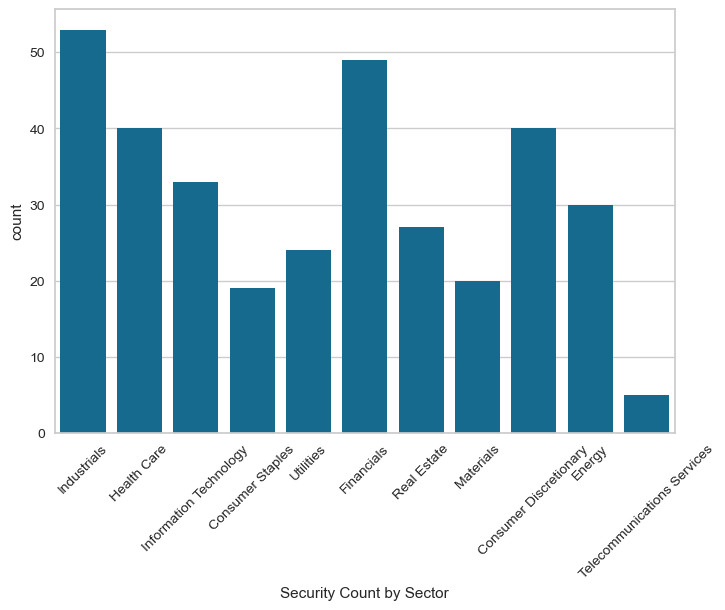

In [18]:
#Count of Securities by Sector
sns.countplot(
    data=df,
    x='GICS Sector',
)
plt.xlabel('Security Count by Sector')
plt.xticks(rotation=45)
plt.show()

In [19]:
#Get counts of securities per Sector
df['GICS Sector'].value_counts()

GICS Sector
Industrials                    53
Financials                     49
Health Care                    40
Consumer Discretionary         40
Information Technology         33
Energy                         30
Real Estate                    27
Utilities                      24
Materials                      20
Consumer Staples               19
Telecommunications Services     5
Name: count, dtype: int64

##### GICS Sector Observations:
- Industrials has the greatest number of securities represented in this dataset with 53 while Telecommunications Services has the fewest with 5.

#### GICS Sub Industry

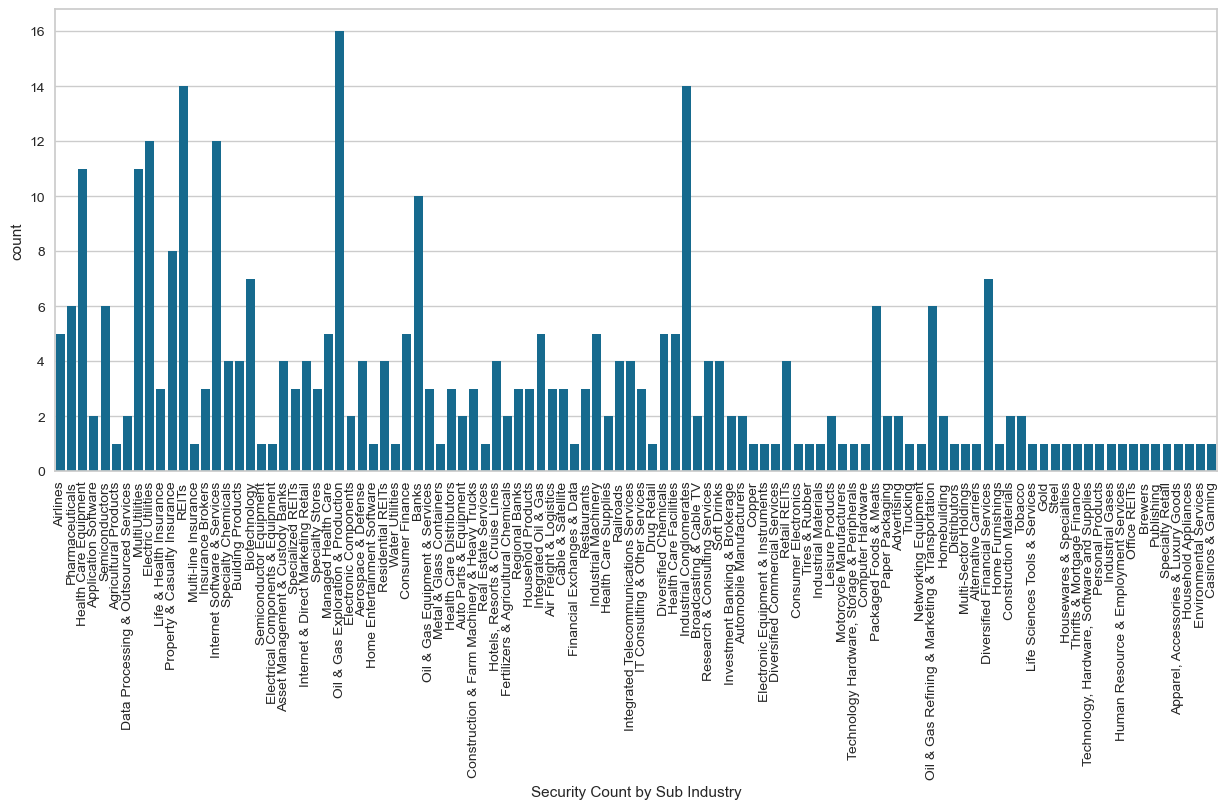

In [20]:
#Count of Securities by Sub Industry
plt.figure(figsize=(15, 6))
sns.countplot(
    data=df,
    x='GICS Sub Industry',
)
plt.xlabel('Security Count by Sub Industry')
plt.xticks(rotation=90)
plt.show()

In [21]:
#Get counts of securities per Sub Industry
df['GICS Sub Industry'].value_counts()

GICS Sub Industry
Oil & Gas Exploration & Production     16
REITs                                  14
Industrial Conglomerates               14
Electric Utilities                     12
Internet Software & Services           12
                                       ..
Specialty Retail                        1
Apparel, Accessories & Luxury Goods     1
Household Appliances                    1
Environmental Services                  1
Casinos & Gaming                        1
Name: count, Length: 104, dtype: int64

In [22]:
#Count of Sub Industries with only 1 Security in the data set
(df['GICS Sub Industry'].value_counts() == 1).sum()

np.int64(42)

##### GICS Sub Industry Observations:
- Oil & Gas Exploration & Production has the greatest number of securities represented in this dataset with 16
- 104 Sub Industries only appear once in this data set.

#### Current Price

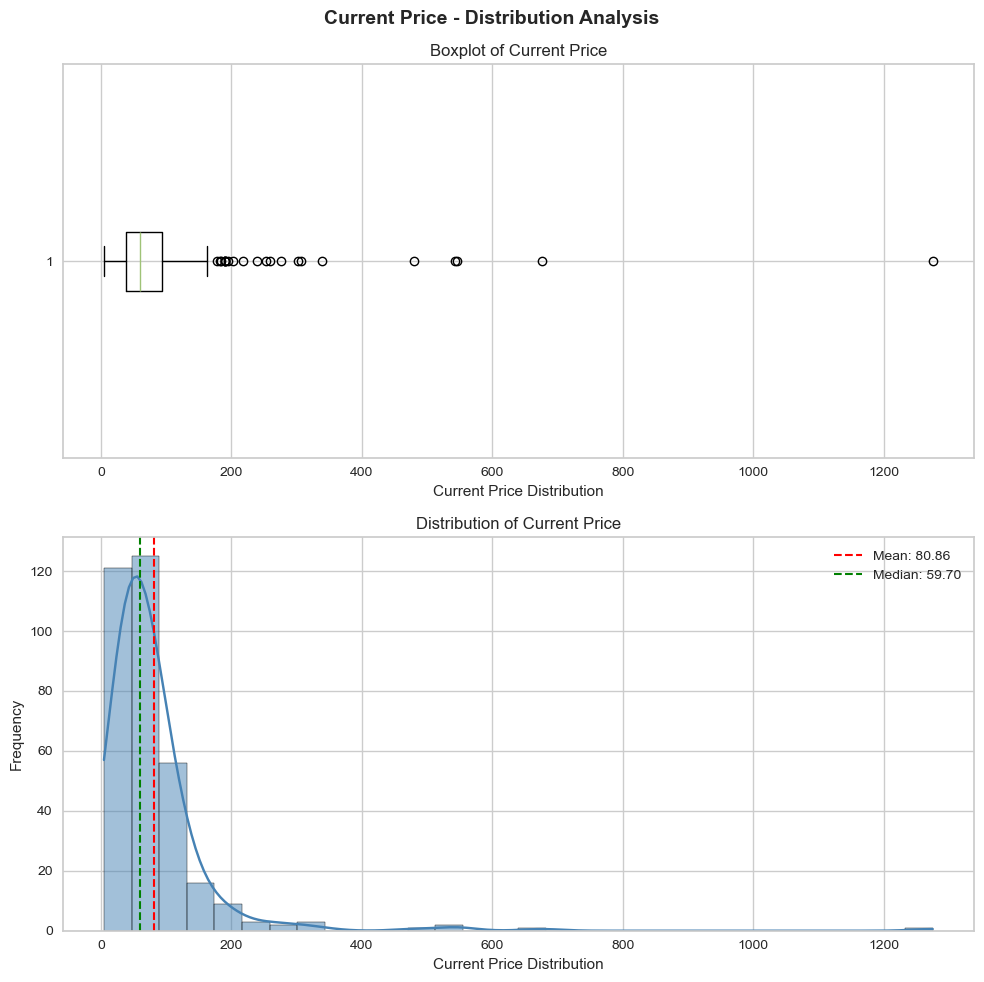

In [23]:
#Distribution of Current Security Price
plot_distribution(df, 'Current Price', xlabel='Current Price Distribution')

In [24]:
describe_distribution(df, 'Current Price')

Lower Outlier Fence = -42.93250249999999
Upper Outlier Fence = 174.3675035
Outlier count: 22
Skewness:  7.047314473571039
The distribution is highly skewed to the right.


count     340.000000
mean       80.862345
std        98.055086
min         4.500000
25%        38.555000
50%        59.705000
75%        92.880001
max      1274.949951
Name: Current Price, dtype: float64

##### Current Price Observations:
- Mean price for the securities in the data is `$80.86`
- The Prices skew right with 22 outliers.  Outliers are reasonable for stock prices with a maximum of `$1274.95` and represent valid data. **(Answer to Question 1)**

#### Price Change

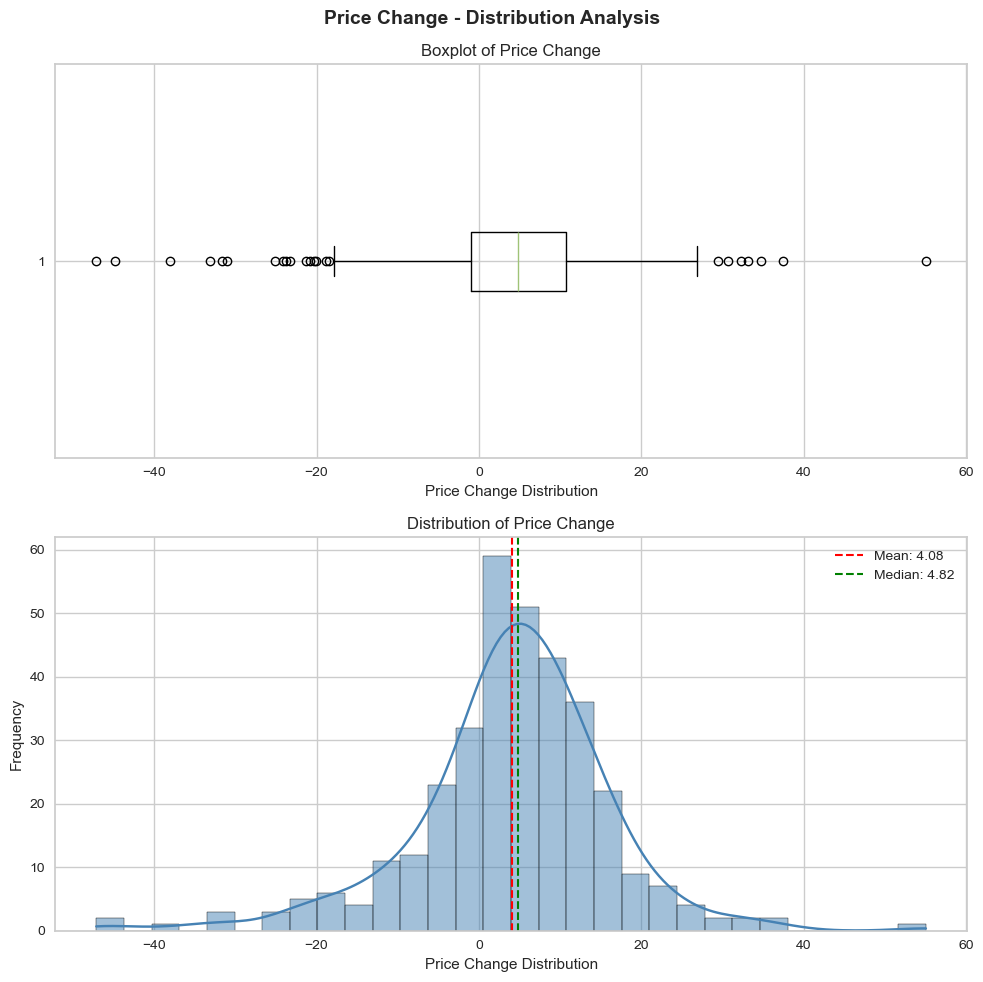

In [25]:
#Distribution of Price Change
plot_distribution(df, 'Price Change', xlabel='Price Change Distribution')

In [26]:
describe_distribution(df, 'Price Change')

Lower Outlier Fence = -18.391948249375
Upper Outlier Fence = 28.147957057625003
Outlier count: 23
Skewness:  -0.5591568036040258
The distribution is moderately skewed to the left.


count    340.000000
mean       4.078194
std       12.006338
min      -47.129693
25%       -0.939484
50%        4.819505
75%       10.695493
max       55.051683
Name: Price Change, dtype: float64

##### Price Change Observations:
- Mean Price change over the observed 13 week period was 4.08% with a max of 55.05% and minimum of -47.13%
- 23 outliers at both tails represent legitimate data and will not need to be treated.

#### Volatility

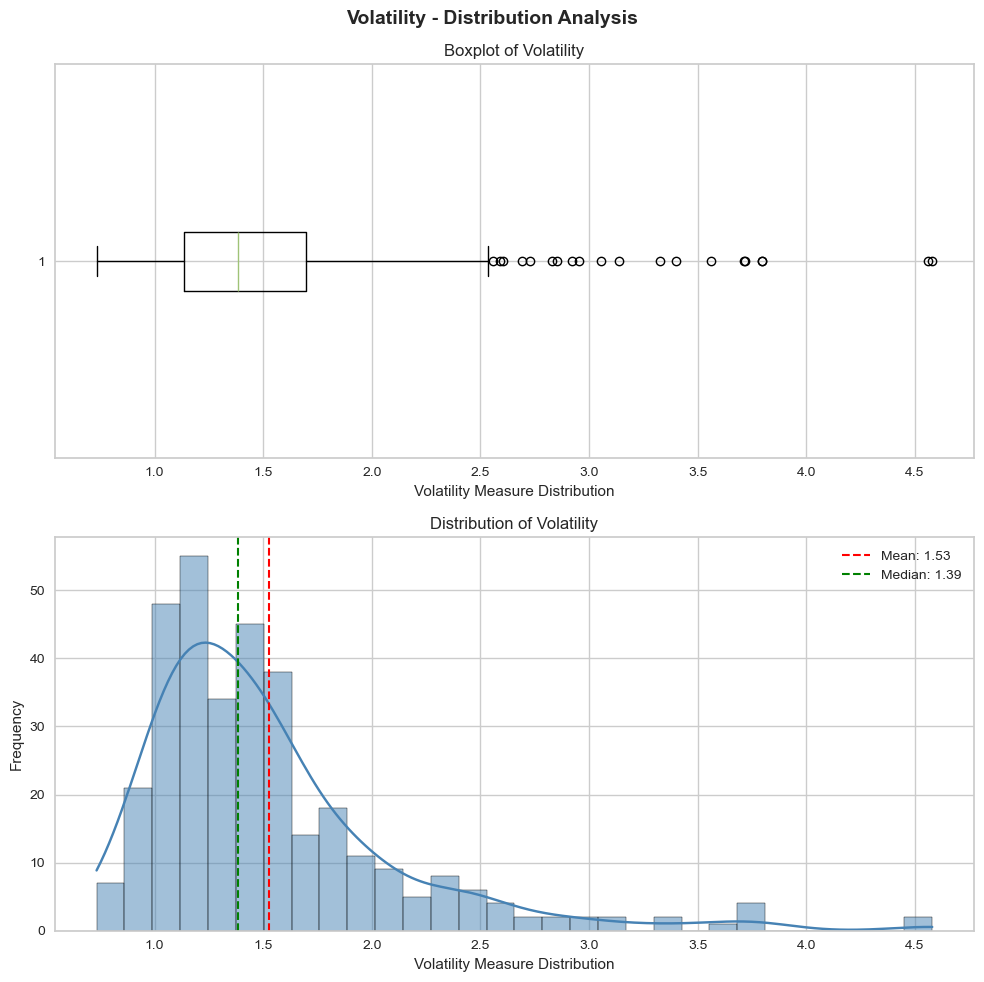

In [27]:
#Distribution of Security Volatility Measure
plot_distribution(df, 'Volatility', xlabel='Volatility Measure Distribution')

In [28]:
describe_distribution(df, 'Volatility')

Lower Outlier Fence = 0.2938723351250001
Upper Outlier Fence = 2.536554822125
Outlier count: 20
Skewness:  2.097423793360458
The distribution is highly skewed to the right.


count    340.000000
mean       1.525976
std        0.591798
min        0.733163
25%        1.134878
50%        1.385593
75%        1.695549
max        4.580042
Name: Volatility, dtype: float64

##### Volatility Observations:
- Average volatility (Standard Deviation of Price) was 1.53
- Data skews right with 20 outliers.  Outliers represent valid data and will not need to be treated.

#### ROE

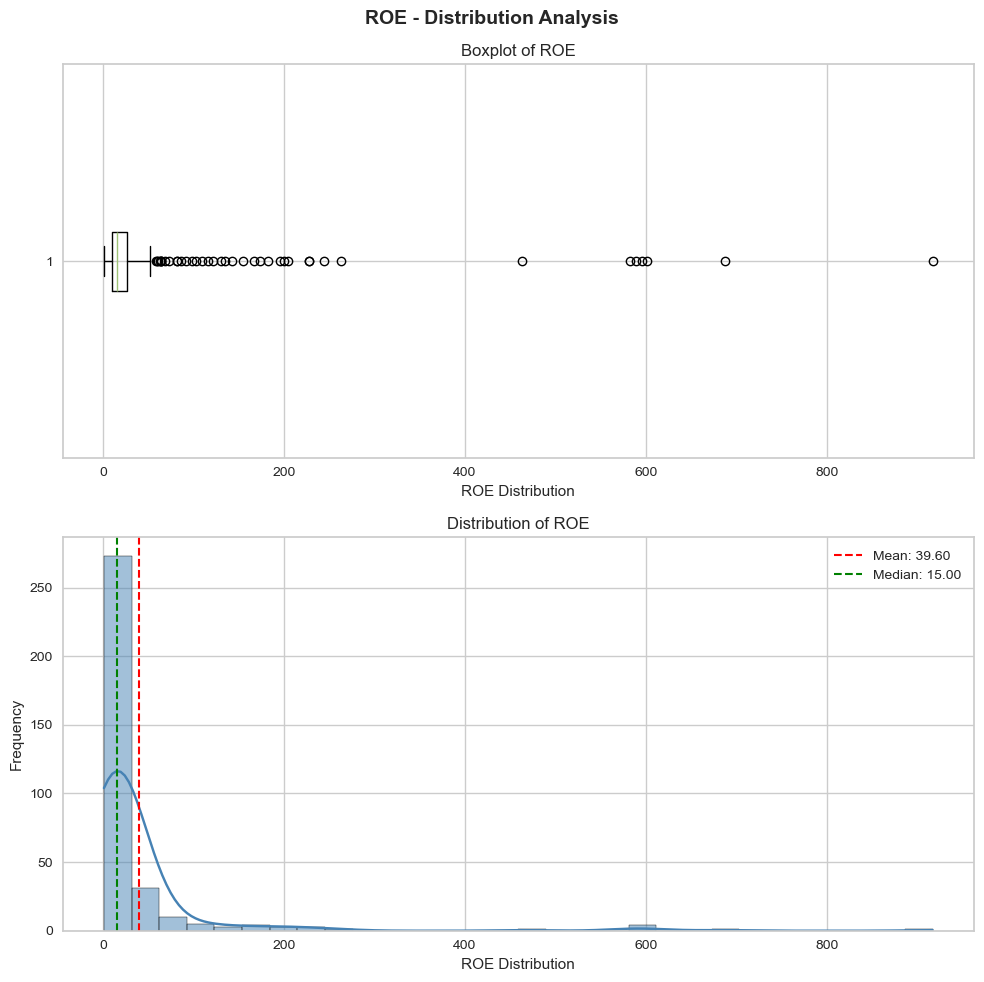

In [29]:
#Distribution of ROE
plot_distribution(df, 'ROE', xlabel='ROE Distribution')

In [30]:
describe_distribution(df, 'ROE')

Lower Outlier Fence = -16.125
Upper Outlier Fence = 52.875
Outlier count: 39
Skewness:  5.773421575650542
The distribution is highly skewed to the right.


count    340.000000
mean      39.597059
std       96.547538
min        1.000000
25%        9.750000
50%       15.000000
75%       27.000000
max      917.000000
Name: ROE, dtype: float64

##### ROE Observations:
- Mean ROE is 39.60
- Data is highly skewed right with 39 outliers.  Outliers represent valid data and will not need to be treated.
- As observed above, ROE appears to be represented in % form here as opposed to as a ratio.

#### Cash Ratio

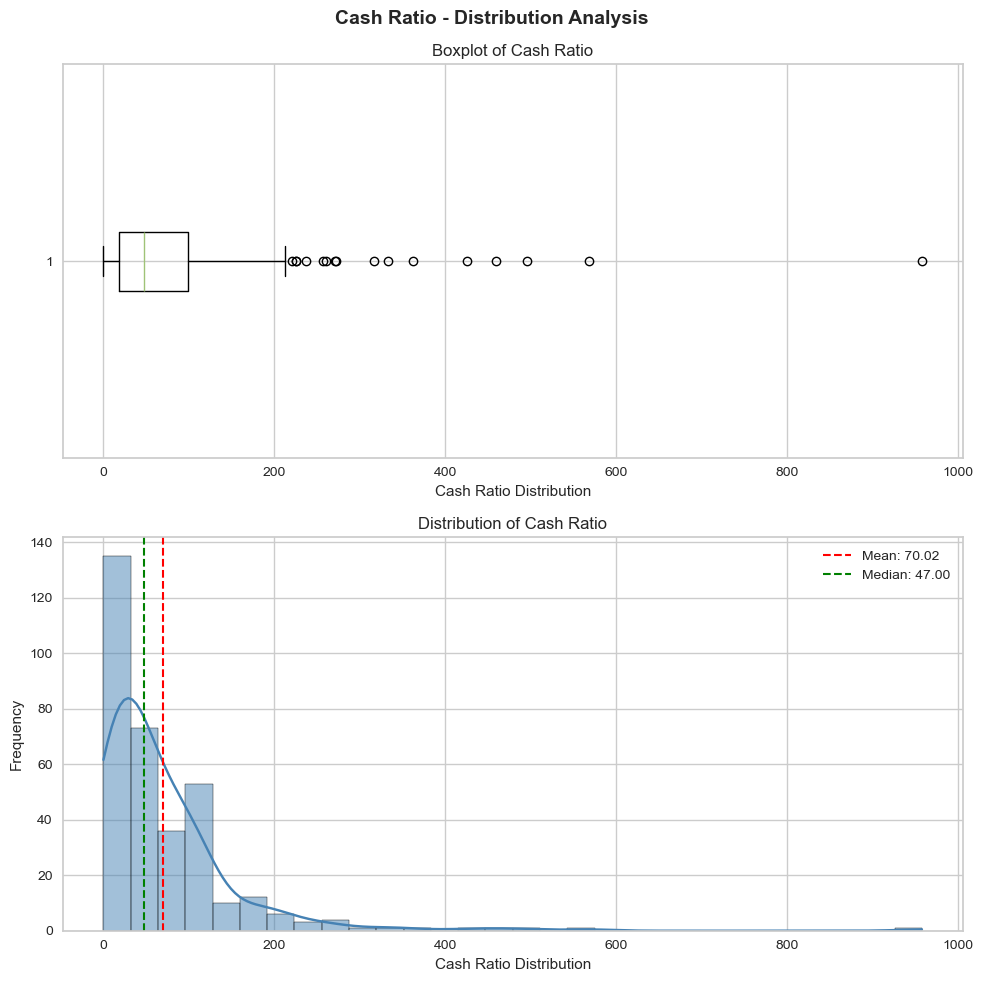

In [31]:
#Distribution of Cash Ratios
plot_distribution(df, 'Cash Ratio', xlabel='Cash Ratio Distribution')

In [32]:
describe_distribution(df, 'Cash Ratio')

Lower Outlier Fence = -103.5
Upper Outlier Fence = 220.5
Outlier count: 16
Skewness:  4.467453231951163
The distribution is highly skewed to the right.


count    340.000000
mean      70.023529
std       90.421331
min        0.000000
25%       18.000000
50%       47.000000
75%       99.000000
max      958.000000
Name: Cash Ratio, dtype: float64

##### Cash Ratio Observations:
- Cash ratios range from 0 to 958 with a mean of 70.02
- Outliers represent valid data and will not need to be treated

#### Net Cash Flow

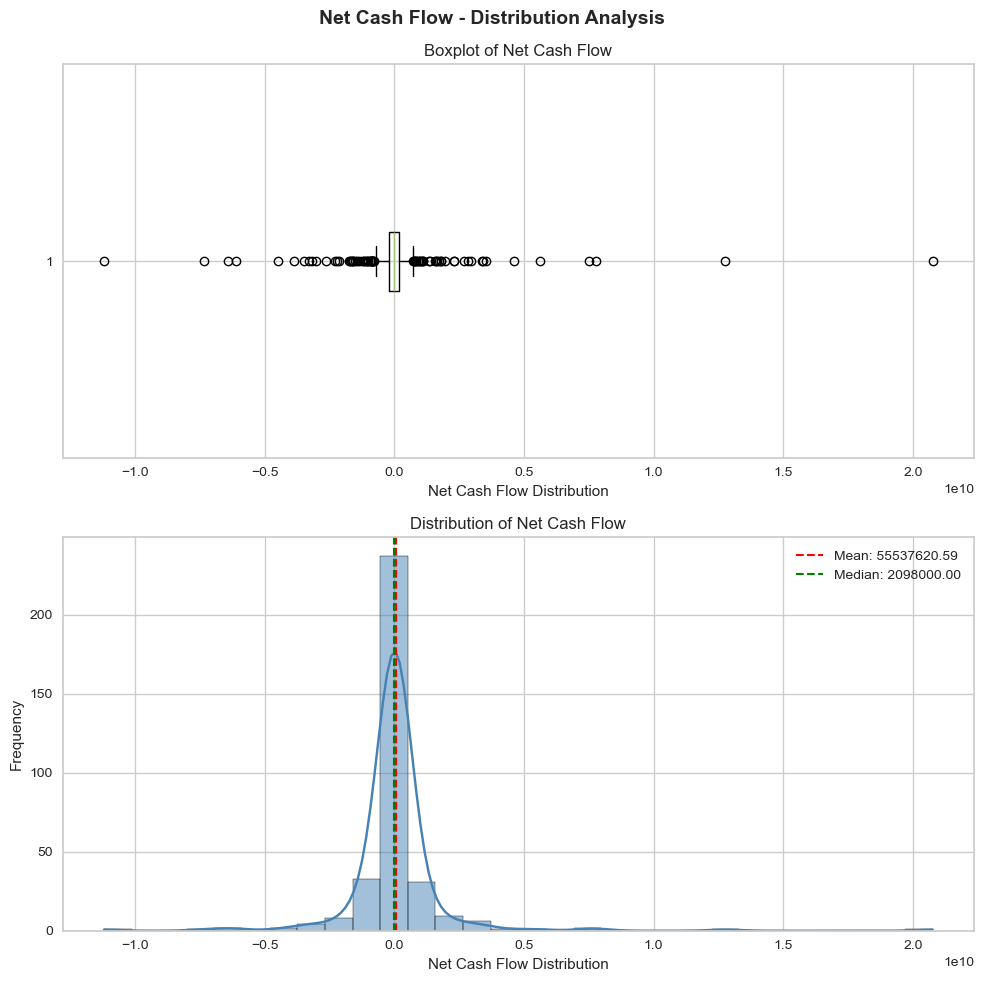

In [33]:
#Distribution of Net Cash Flows
plot_distribution(df, 'Net Cash Flow', xlabel='Net Cash Flow Distribution')

In [34]:
describe_distribution(df, 'Net Cash Flow')

Lower Outlier Fence = -739482375.0
Upper Outlier Fence = 715386625.0
Outlier count: 76
Skewness:  3.847724818293334
The distribution is highly skewed to the right.


count    3.400000e+02
mean     5.553762e+07
std      1.946365e+09
min     -1.120800e+10
25%     -1.939065e+08
50%      2.098000e+06
75%      1.698108e+08
max      2.076400e+10
Name: Net Cash Flow, dtype: float64

##### Net Cash Flow Observations:
- Net cash flow ranges from -1.12e+10 to 2.08e+10
- Outliers represent valid data and will not need to be treated.

#### Net Income

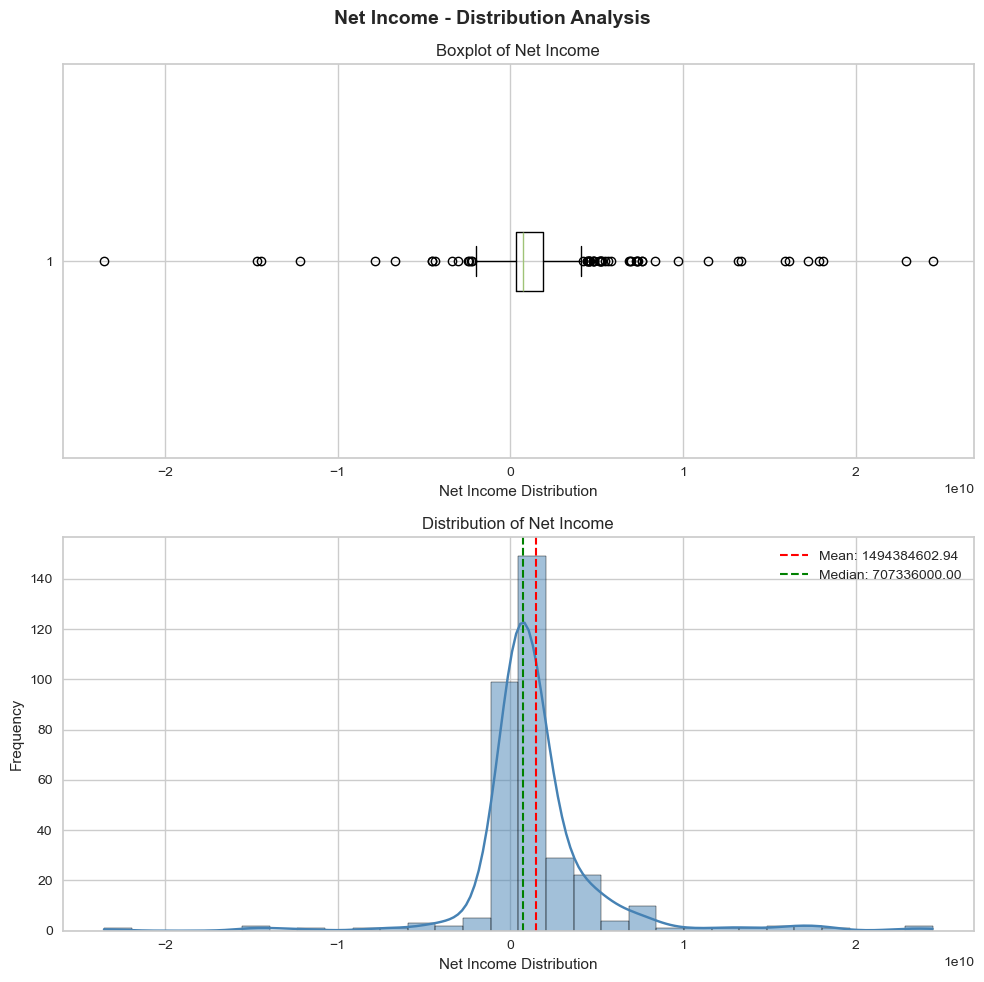

In [35]:
#Distribution of Net Income
plot_distribution(df, 'Net Income', xlabel='Net Income Distribution')

In [36]:
describe_distribution(df, 'Net Income')

Lower Outlier Fence = -1967746875.0
Upper Outlier Fence = 4219048125.0
Outlier count: 57
Skewness:  0.9454167510148961
The distribution is moderately skewed to the right.


count    3.400000e+02
mean     1.494385e+09
std      3.940150e+09
min     -2.352800e+10
25%      3.523012e+08
50%      7.073360e+08
75%      1.899000e+09
max      2.444200e+10
Name: Net Income, dtype: float64

##### Net Income Observations:
- Net income ranges from `-$2.35e+10` to `$2.44e+10` with a mean of `$1.49e+09`
- Outliers represent valid data and will not  need to be treated.

#### Earnings Per Share

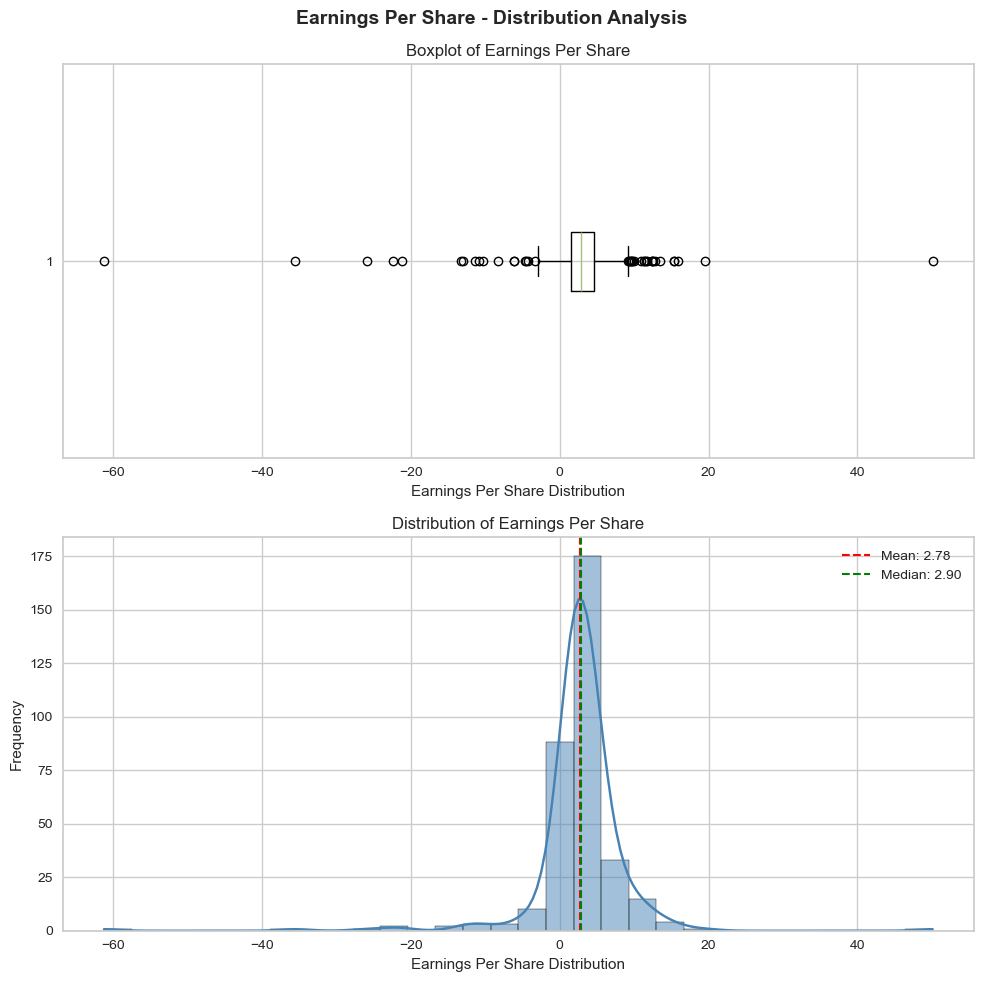

In [37]:
#Distribution of Earnings Per Share
plot_distribution(df, 'Earnings Per Share', xlabel='Earnings Per Share Distribution')

In [38]:
describe_distribution(df, 'Earnings Per Share')

Lower Outlier Fence = -3.03625
Upper Outlier Fence = 9.213750000000001
Outlier count: 39
Skewness:  -2.7215843164816045
The distribution is highly skewed to the left.


count    340.000000
mean       2.776662
std        6.587779
min      -61.200000
25%        1.557500
50%        2.895000
75%        4.620000
max       50.090000
Name: Earnings Per Share, dtype: float64

##### Earnings Per Share Observations:
- Earnings per share range from `-$61.20` to `$50.09` with a mean of `$2.78`
- Outliers represent valid data and will not need to be treated.

#### Estimated Shares Outstanding

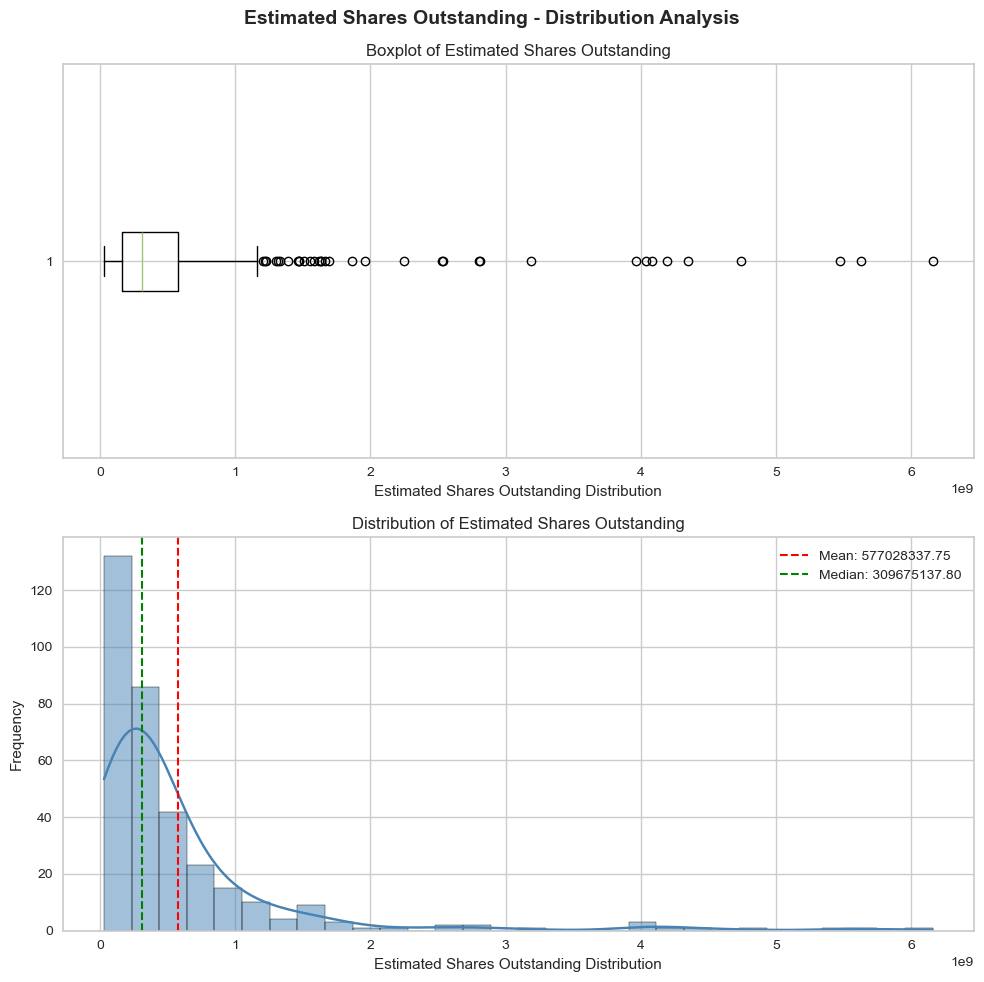

In [39]:
#Distribution of Estimated Shares Outstanding
plot_distribution(df, 'Estimated Shares Outstanding', xlabel='Estimated Shares Outstanding Distribution')

In [40]:
describe_distribution(df, 'Estimated Shares Outstanding')

Lower Outlier Fence = -462555645.73749983
Upper Outlier Fence = 1194521319.1625
Outlier count: 35
Skewness:  3.8453087830367148
The distribution is highly skewed to the right.


count    3.400000e+02
mean     5.770283e+08
std      8.458496e+08
min      2.767216e+07
25%      1.588482e+08
50%      3.096751e+08
75%      5.731175e+08
max      6.159292e+09
Name: Estimated Shares Outstanding, dtype: float64

##### Estimated Shares Outstanding Observations:
- Estimated shares outstanding range from 2.77e+07 to 6.16e+09 with a mean of 5.77e+08
- Outliers represent valid data and will not need to be treated.

#### P/E Ratio

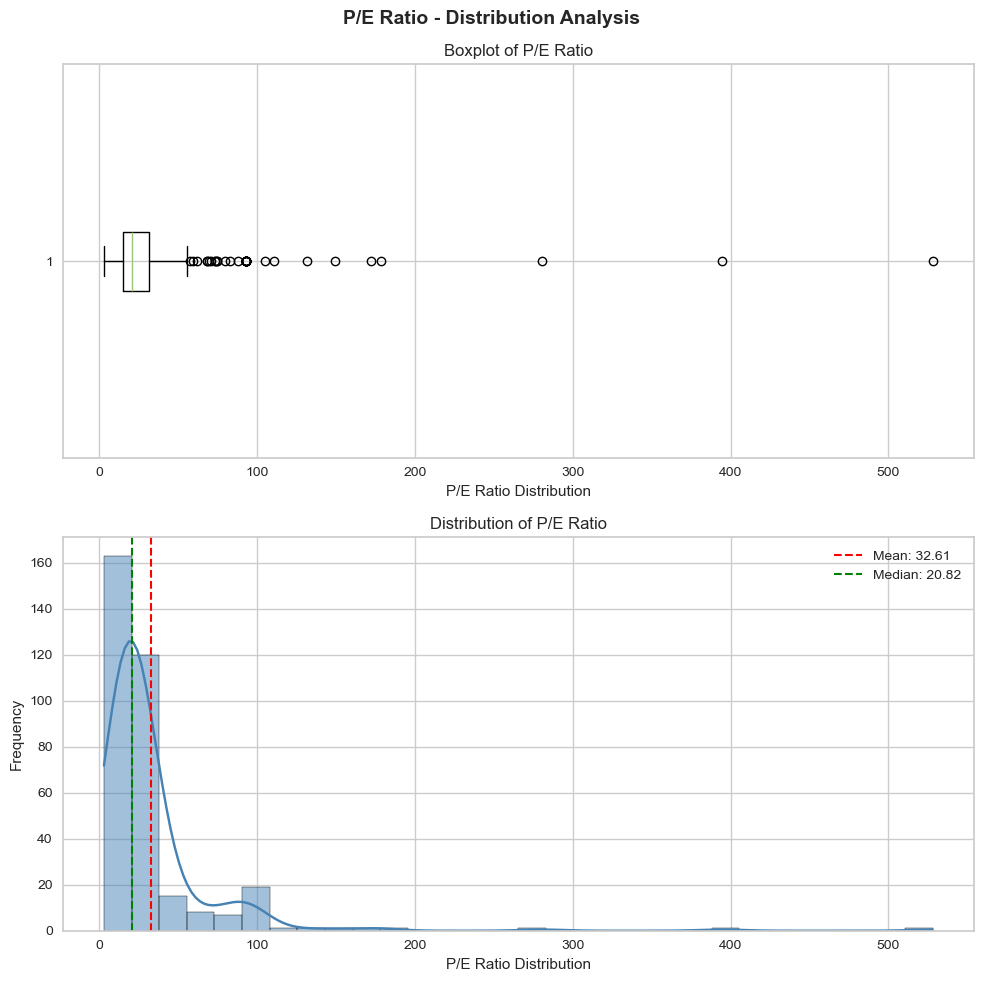

In [41]:
#Distribution of P/E Ratios
plot_distribution(df, 'P/E Ratio', xlabel='P/E Ratio Distribution')

In [42]:
describe_distribution(df, 'P/E Ratio')

Lower Outlier Fence = -10.035500967500004
Upper Outlier Fence = 56.8449091725
Outlier count: 41
Skewness:  6.709130606112658
The distribution is highly skewed to the right.


count    340.000000
mean      32.612563
std       44.348731
min        2.935451
25%       15.044653
50%       20.819876
75%       31.764755
max      528.039074
Name: P/E Ratio, dtype: float64

##### P/E Ratio Observations:
- P/E Ratio ranges from 2.94 to 528.04 with a mean of 32.61
- Outliers represent valid data and will not need to be treated.

#### P/B Ratio

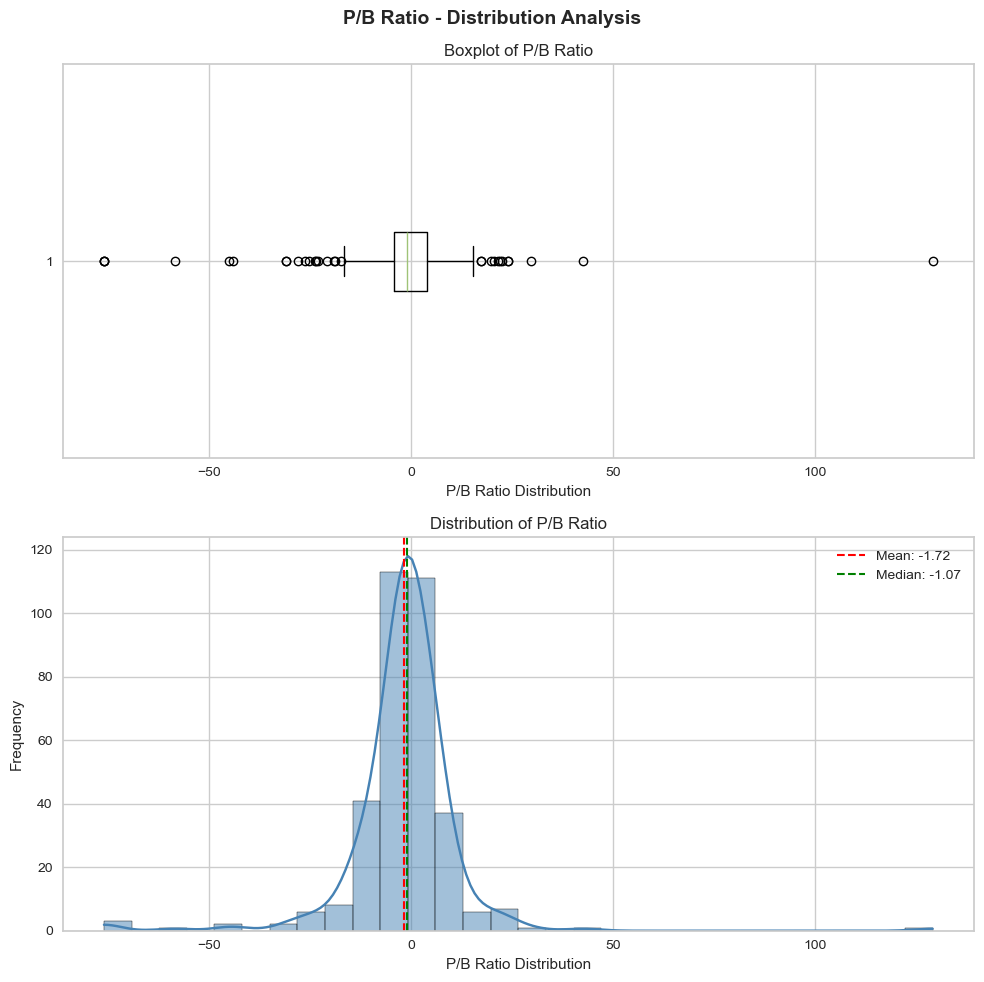

In [43]:
#Distribution of P/B Ratios
plot_distribution(df, 'P/B Ratio', xlabel='P/B Ratio Distribution')

In [44]:
describe_distribution(df, 'P/B Ratio')

Lower Outlier Fence = -16.75573992475
Upper Outlier Fence = 16.32074923325
Outlier count: 30
Skewness:  0.8164232388276682
The distribution is moderately skewed to the right.


count    340.000000
mean      -1.718249
std       13.966912
min      -76.119077
25%       -4.352056
50%       -1.067170
75%        3.917066
max      129.064585
Name: P/B Ratio, dtype: float64

##### P/B Ratio Observations:
- P/B Ratio ranges from -76.12 to 129.06 with a mean of -1.72
- Outliers represent valid data and will not need to be treated.

### Multivariate EDA

**Note on Approach:**
In the name of conciseness and readability, we will not go through every combination of columns.  Instead we will focus on answering the questions posed above, moderate to strong correlations of >0.4, and anything else that may be of obvious interest.

#### Heatmap

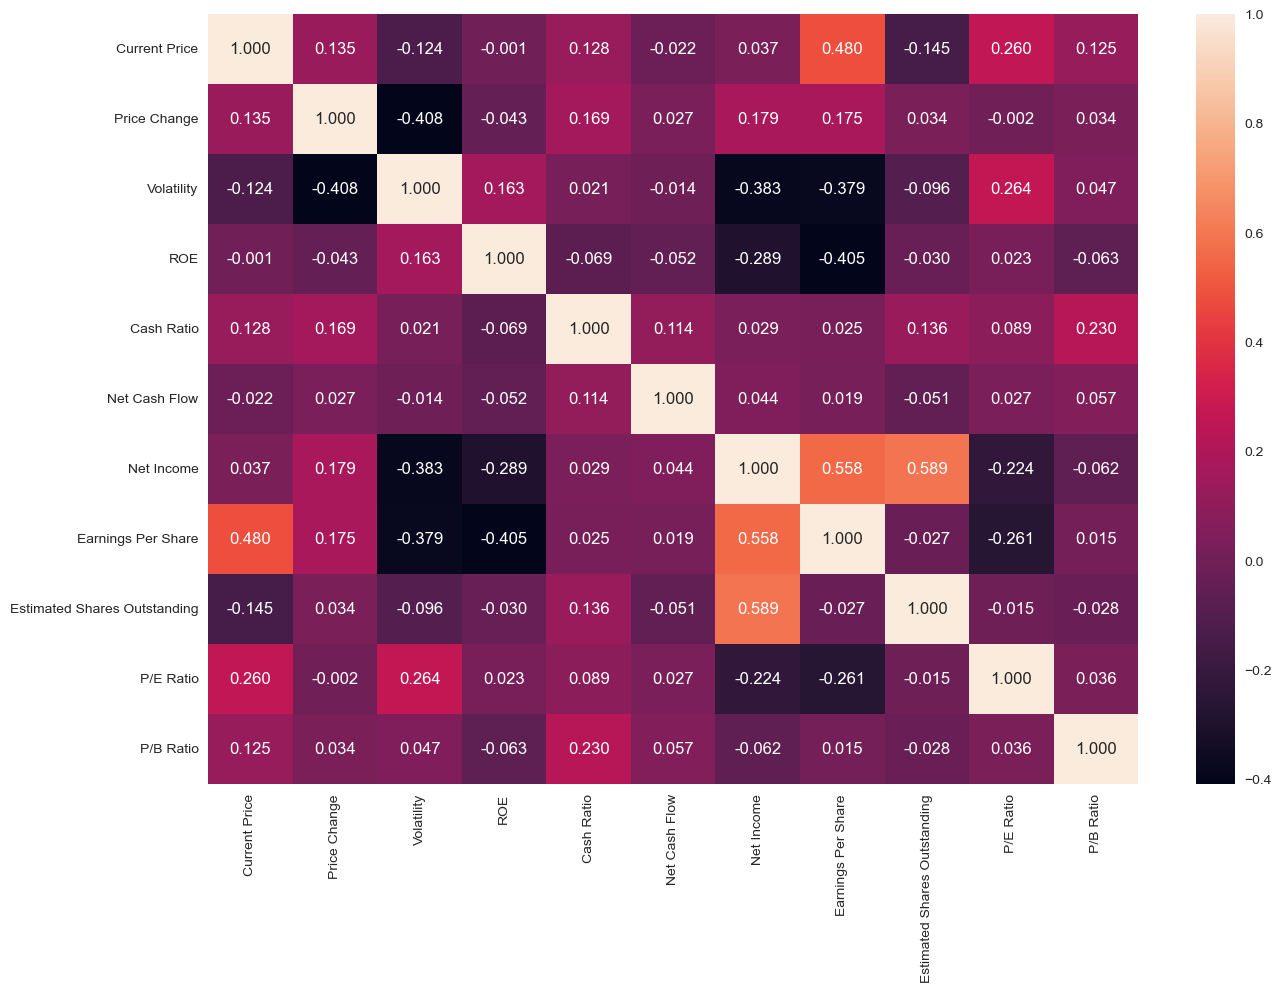

In [45]:
# Heatmap of numeric values
plt.figure(figsize=(15, 10))
sns.heatmap(
    data = df.select_dtypes(include='number').corr(), 
    annot=True,
    fmt='.3f'
)
plt.show()

In [46]:
#Find correlations > abs(0.4)
find_correlations(df, 0.4)

Net Income     Estimated Shares Outstanding    0.589310
               Earnings Per Share              0.557752
Current Price  Earnings Per Share              0.479604
Price Change   Volatility                     -0.408281
ROE            Earnings Per Share             -0.405291
dtype: float64

##### Heatmap Observations
- There are no surprises with correlations, especially considering that some of these attributes are directly involved in the calculation of others.
- The strongest correlation is between Net Income and Estimated Shares Outstanding at .59 **(Answer to Question 3)**

#### Security Multivariate

##### Highest Current Prices

In [47]:
# Highest priced stocks
df.nlargest(5, 'Current Price')[['Security', 'Current Price']]

,Security,Current Price
243,Priceline.com Inc,1274.949951
26,Amazon.com Inc,675.890015
171,Intuitive Surgical Inc.,546.159973
264,Regeneron,542.869995
70,Chipotle Mexican Grill,479.850006


##### Lowest Current Price

In [48]:
# Lowest priced stocks
df.nsmallest(5, 'Current Price')[['Security', 'Current Price']]

,Security,Current Price
62,Chesapeake Energy,4.500000
137,Frontier Communications,4.670000
127,Freeport-McMoran Cp & Gld,6.770000
284,Southwestern Energy,7.110000
33,Arconic Inc,7.398807


##### Top 5 Positive Price Change

In [49]:
# Top Price Changes
df.nlargest(5, 'Price Change')[['Security', 'Price Change']]

,Security,Price Change
136,First Solar Inc,55.051683
87,Du Pont (E.I.),37.489677
293,TripAdvisor,34.803917
220,Mylan N.V.,33.177346
26,Amazon.com Inc,32.268105


##### Bottom 5 Price Change

In [50]:
# Top Price Changes
df.nsmallest(5, 'Price Change')[['Security', 'Price Change']]

,Security,Price Change
180,Kinder Morgan,-47.129693
284,Southwestern Energy,-44.798137
62,Chesapeake Energy,-38.101788
70,Chipotle Mexican Grill,-33.131268
127,Freeport-McMoran Cp & Gld,-31.685167


##### Most Volatile

In [51]:
# 5 Most volatile
df.nlargest(5, 'Volatility')[['Security', 'Volatility']]

,Security,Volatility
284,Southwestern Energy,4.580042
62,Chesapeake Energy,4.559815
127,Freeport-McMoran Cp & Gld,3.796410
327,Wynn Resorts Ltd,3.794783
323,Williams Cos.,3.719560


##### Least Volatile

In [52]:
# 5 Most volatile
df.nsmallest(5, 'Volatility')[['Security', 'Volatility']]

,Security,Volatility
201,McDonald's Corp.,0.733163
245,PepsiCo Inc.,0.805357
248,Procter & Gamble,0.806056
307,United Parcel Service,0.826408
268,Republic Services Inc,0.839821


##### Security Multivariate Observations:
- Priceline.com Inc has the highest current stock price in the set at `$1274.95` while Chesapeake Energy is lowest priced at `$4.50`
- First Solar Inc had the greatest positive price change at 55.05% and Kinder Morgan had the most negative price change at -47.13%
- Southwestern Energy was the most volatile while McDonald's Corp. was least volatile.

#### GICS Sector Multivariate

##### GICS Sector v GICS Sub Industry

In [53]:
# Number of Sub Industries in each Sector
df.groupby('GICS Sector')['GICS Sub Industry'].nunique().sort_values(ascending=False)

GICS Sector
Consumer Discretionary         22
Industrials                    16
Financials                     13
Information Technology         12
Materials                      10
Health Care                     8
Consumer Staples                8
Real Estate                     6
Energy                          4
Utilities                       3
Telecommunications Services     2
Name: GICS Sub Industry, dtype: int64

##### GICS Sector v Current Price

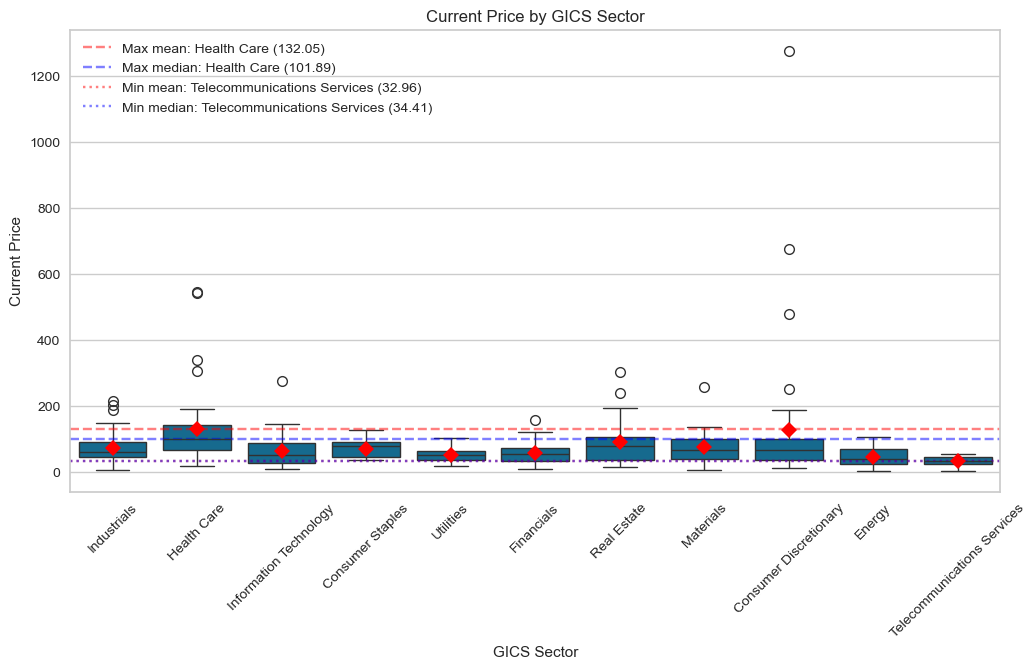

In [54]:
# GICS Sector v Current Price
boxplot_with_max_lines(df, 'GICS Sector', 'Current Price')

##### GICS Sector v Price Change

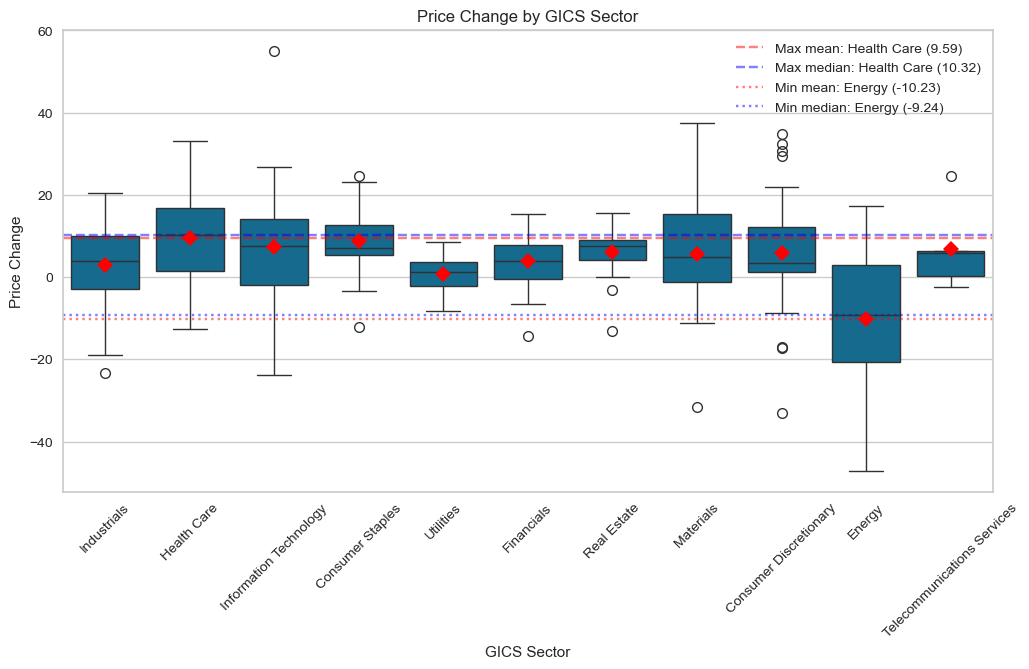

In [55]:
# GICS Sector v Price Change
boxplot_with_max_lines(df, 'GICS Sector', 'Price Change')

##### GICS Sector v Volatility

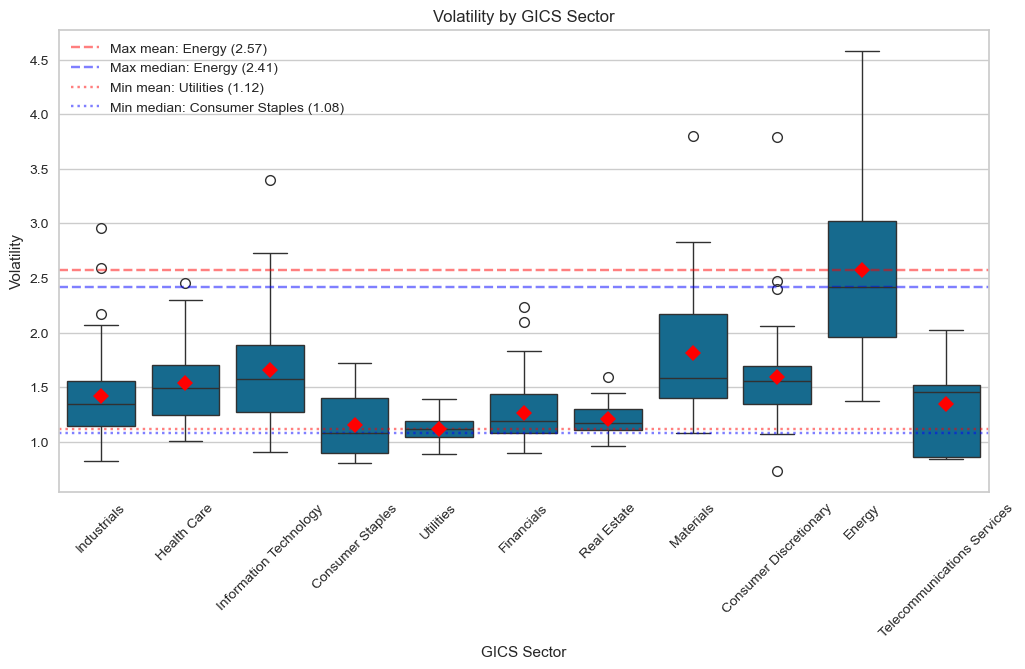

In [56]:
# GICS Sector v Volatility
boxplot_with_max_lines(df, 'GICS Sector', 'Volatility')

##### GICS Sector v Cash Ratio

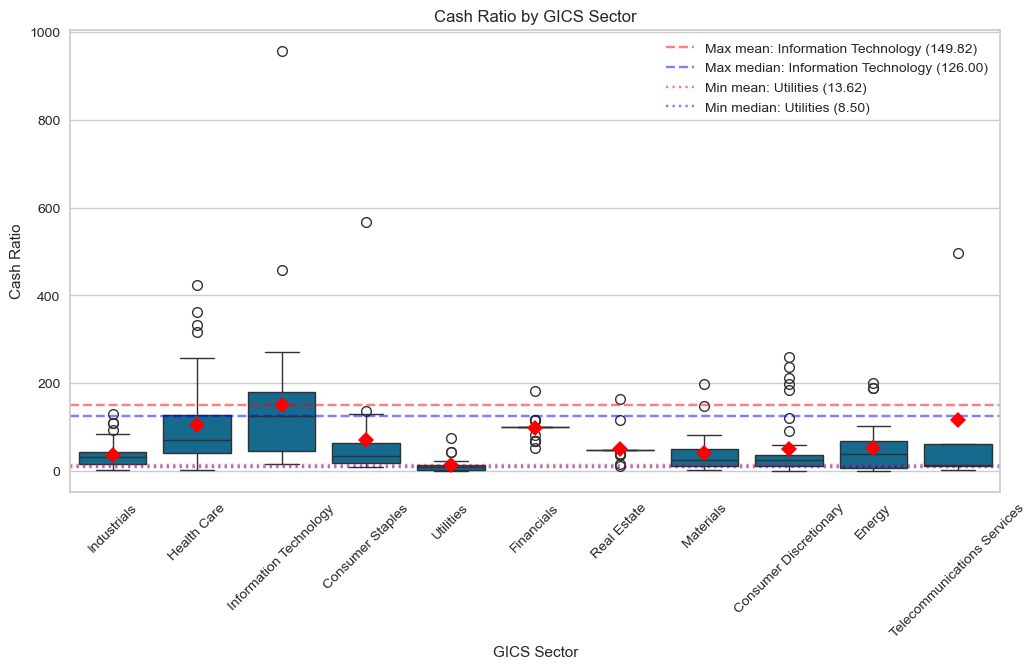

In [57]:
# GICS Sector v Cash Ratio
boxplot_with_max_lines(df, 'GICS Sector', 'Cash Ratio')

##### GICS Sector v Net Income

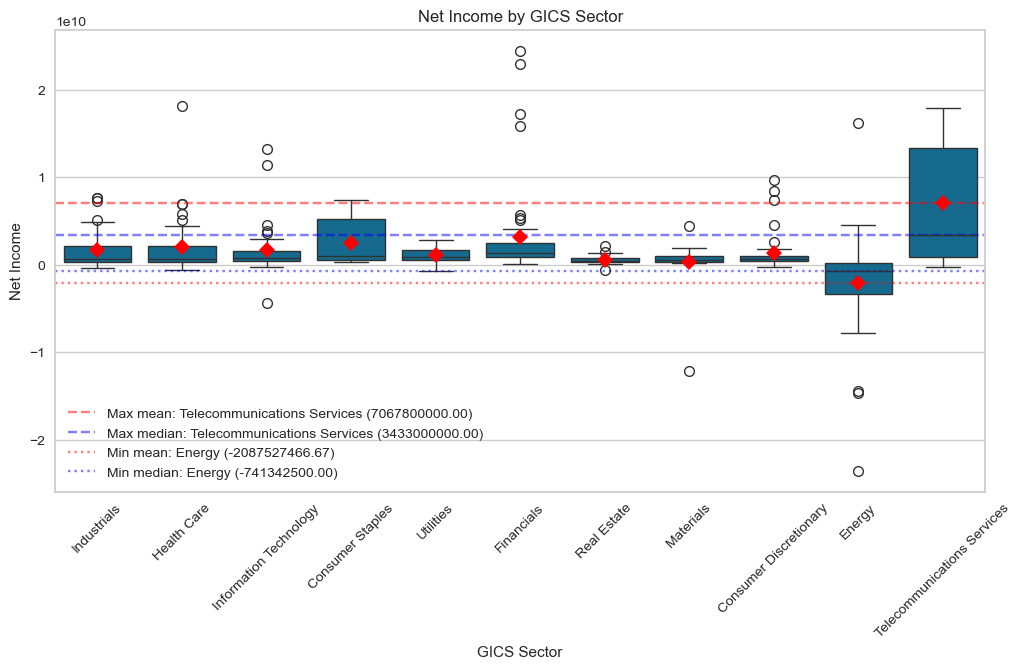

In [58]:
# GICS Sector v Net Income
boxplot_with_max_lines(df, 'GICS Sector', 'Net Income')

##### GICS Sector v Earnings Per Share

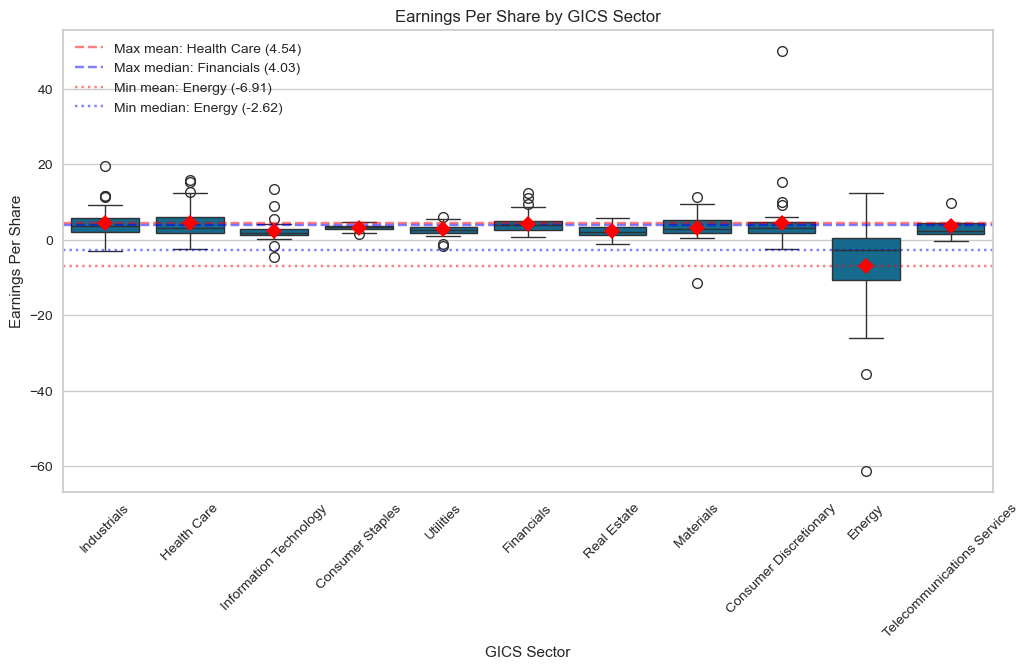

In [59]:
# GICS Sector v Earnings Per Share
boxplot_with_max_lines(df, 'GICS Sector', 'Earnings Per Share')

##### GICS Sector v P/E Ratio

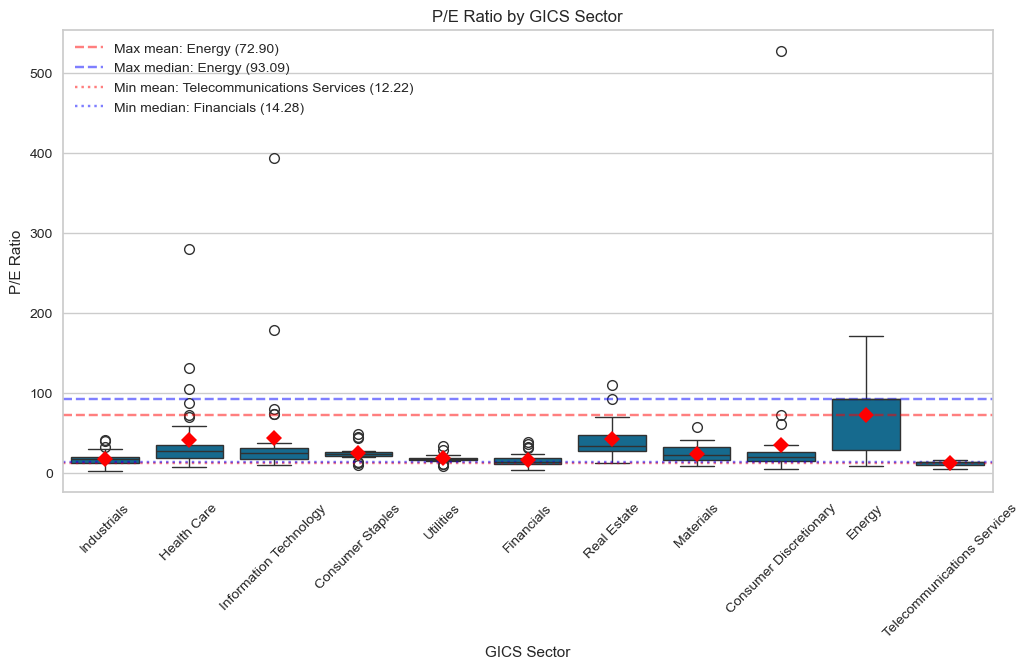

In [60]:
# GICS Sector v P/E Ratio
boxplot_with_max_lines(df, 'GICS Sector', 'P/E Ratio')

##### GICS Sector Multivariate Observations:
- The Consumer Discretionary sector is split into the most sub industries at 22.  Telecomunications services is split into the least sub industries at 2.
- The Healthcare sector had the most positive price change (mean: 9.59%, median: 10.32%) while Energy had the most negative (mean: -9.24%, median: -10.23%) **(Answer to Question 2)**
- Energy stands out as the most volatile sector during the measured period; while Utilities and Consumer Staples compete for least volatile.
- Information Technology tends to carry the highest cash ratio (mean: 149.82, median: 126.00) and Utilities tends to carry the lowest (mean: 13.62, median: 8.50) **(Answer to Question 4)**
- Telecommunications Services has the highest mean and median net income.
- Healthcare has the highest mean earnings per share (`$4.54`) and Financials the highest Median earnings per share (`$4.03`) while Energy has the lowest with negative mean and median earnings per share.
- The energy sector tents to have the highest P/E ratio (mean: 72.90, median: 93.09).  The lowest P/E ratios tend to belong to Telecommunications Services (lowest mean at 12.22) and Financials (lowest median at 14.28). **(Answer to Question 5)**

#### GICS Sub Industry Multivariate

In [61]:
print('There are a total of', df['GICS Sub Industry'].nunique(), 'Sub Industries in the set')
print('There are', (df['GICS Sub Industry'].value_counts() == 1).sum(), 'Sub Industries representing only 1 Security')
print('There are', (df['GICS Sub Industry'].value_counts() > 9).sum(), 'Sub Industries representing 10 or more Securities')

There are a total of 104 Sub Industries in the set
There are 42 Sub Industries representing only 1 Security
There are 8 Sub Industries representing 10 or more Securities


**Note**: It doesn't make much sense to look at sub industries representing only one or a very few securities since we have already looked at individual securities.  With that in mind we will focus on the 8 largest sub industries comprised of 10 or more securities each.

##### GICS Sub Industry v Current Price

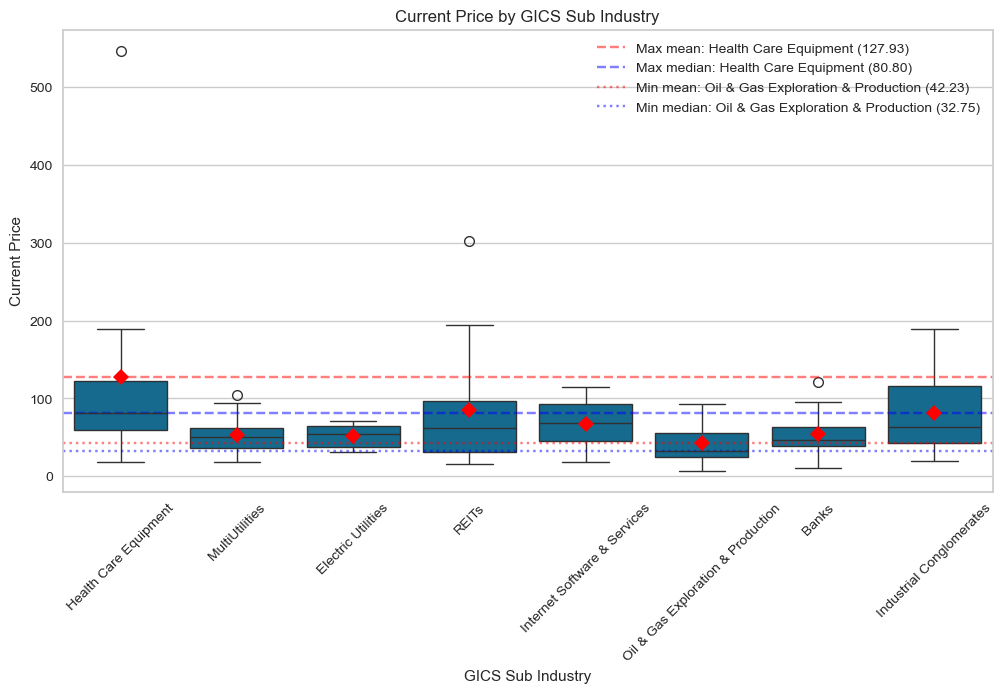

In [62]:
# Eight biggest sub industries (in the dataset) current price distributions
top_n = df['GICS Sub Industry'].value_counts().head(8).index
subset = df[df['GICS Sub Industry'].isin(top_n)]
boxplot_with_max_lines(subset, 'GICS Sub Industry', 'Current Price')

##### GICS Sub Industry v Price Change

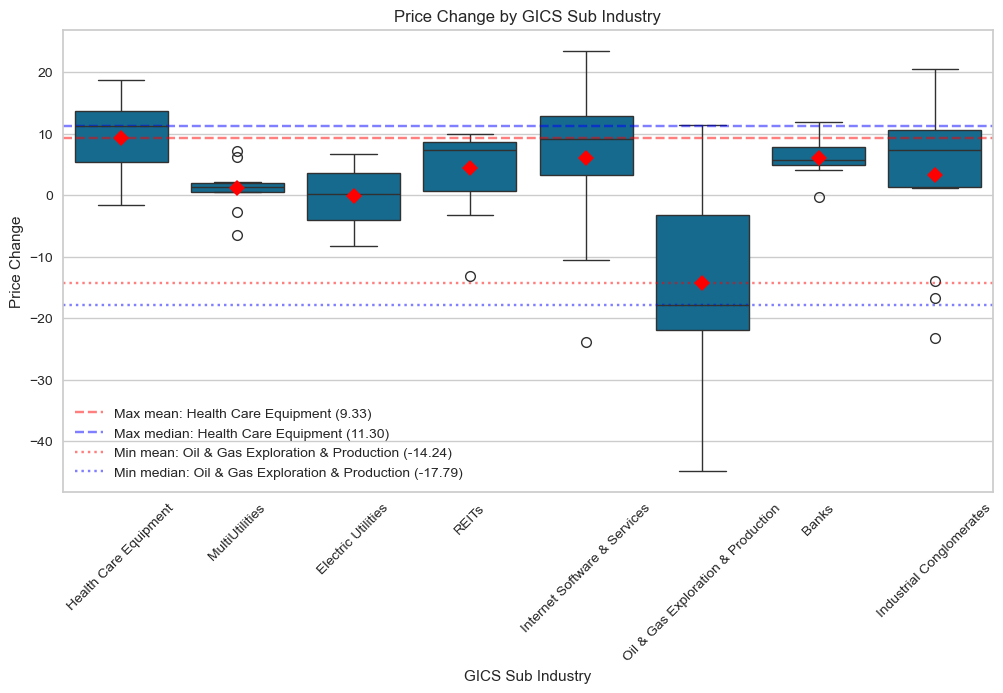

In [63]:
# Eight biggest sub industries (in the dataset) Price Change Distributions
top_n = df['GICS Sub Industry'].value_counts().head(8).index
subset = df[df['GICS Sub Industry'].isin(top_n)]
boxplot_with_max_lines(subset, 'GICS Sub Industry', 'Price Change')

##### GICS Sub Industry v Volatility

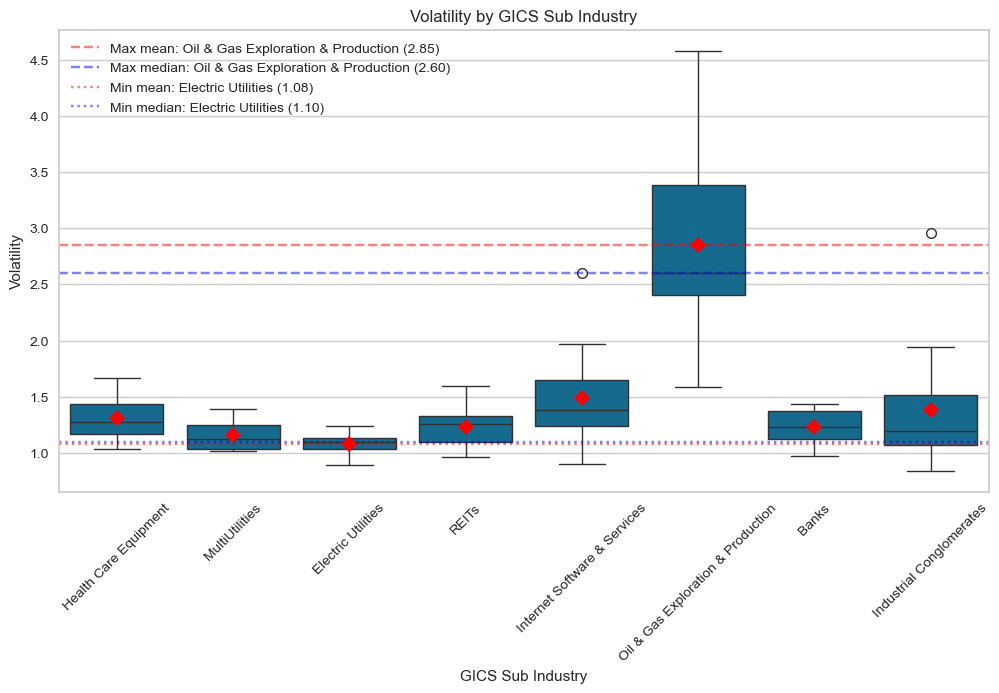

In [64]:
# Eight biggest sub industries (in the dataset) Volatility Distributions
top_n = df['GICS Sub Industry'].value_counts().head(8).index
subset = df[df['GICS Sub Industry'].isin(top_n)]
boxplot_with_max_lines(subset, 'GICS Sub Industry', 'Volatility')

##### GICS Sub Industry Multivariate Observations:
- Of the 8 largest Sub Industries in the set, Healthcare Equpment had the most positive price change, while Oil & Gas Exploration & Production had the most negative change.
- Of the 8 largest Sub Industries in the set, Oil & Gas Exploration & Production was most volatile and Electric Utilities was the least volatile

#### Current Price Multivariate

##### Current Price v Earnings Per Share

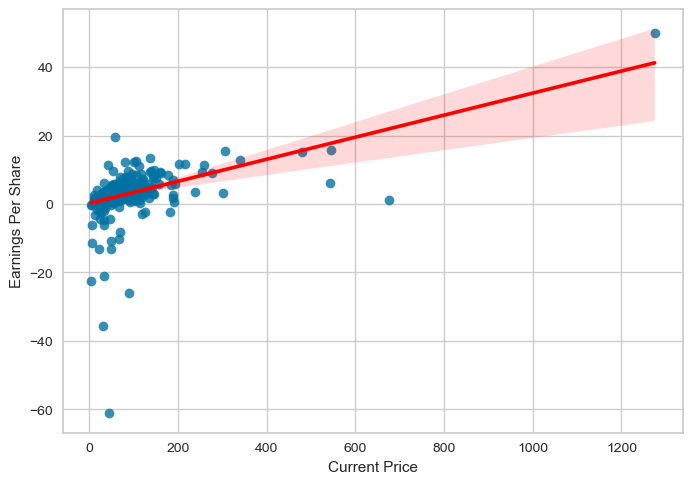

In [65]:
#Current Price v Earnings Per Share
sns.regplot(
    data=df,
    x="Current Price",
    y="Earnings Per Share",
    line_kws={'color': 'red'}
)
plt.show()

##### Current Price Multivariate Observations:
- As noted in the heatmap, current price and earnings per share have a .48 correlation.

#### Price Change Multivariate

##### Price Change v Volatility

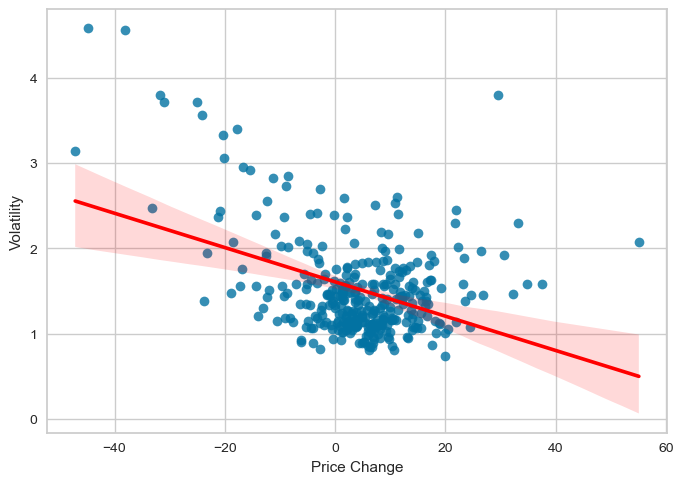

In [66]:
#Price Change v Volatility
sns.regplot(
    data=df,
    x="Price Change",
    y="Volatility",
    line_kws={'color': 'red'}
)
plt.show()

##### Price Change Multivariate Observations:
- As noted above in the heatmap, Price change and Volatility have a -.41 correlation

#### ROE Multivariate

##### ROE v Earnings Per Share

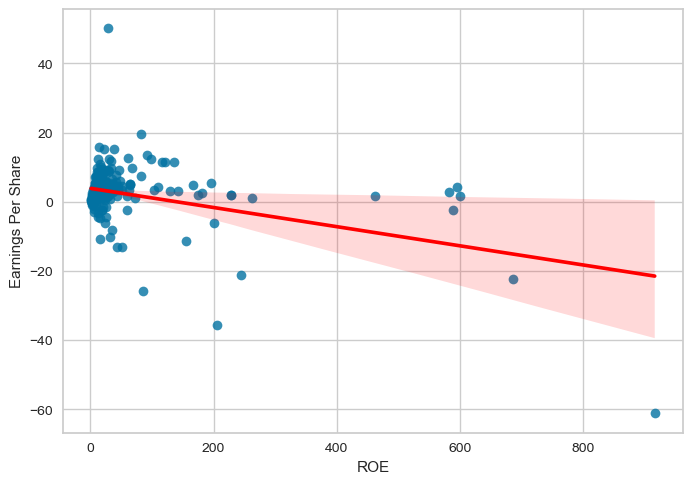

In [67]:
#ROE v Earnings per share
sns.regplot(
    data=df,
    x="ROE",
    y="Earnings Per Share",
    line_kws={'color': 'red'}
)
plt.show()

##### ROE Multivariate Observations:
- As noted in the heatmap ROE and Earnings per share have a -.41 correlation

#### Net Income Multivariate

##### Net Income v Estimated Shares Outstanding

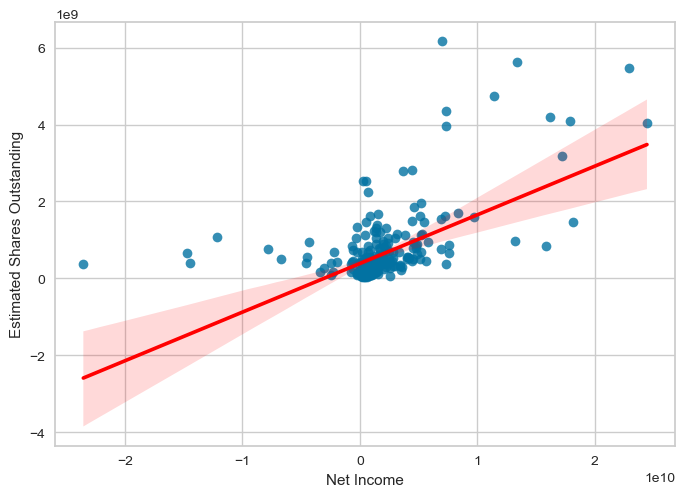

In [68]:
#Net Income v Estimated Shares outstanding
sns.regplot(
    data=df,
    x="Net Income",
    y="Estimated Shares Outstanding",
    line_kws={'color': 'red'}
)
plt.show()

##### Net Income v Earnings Per Share

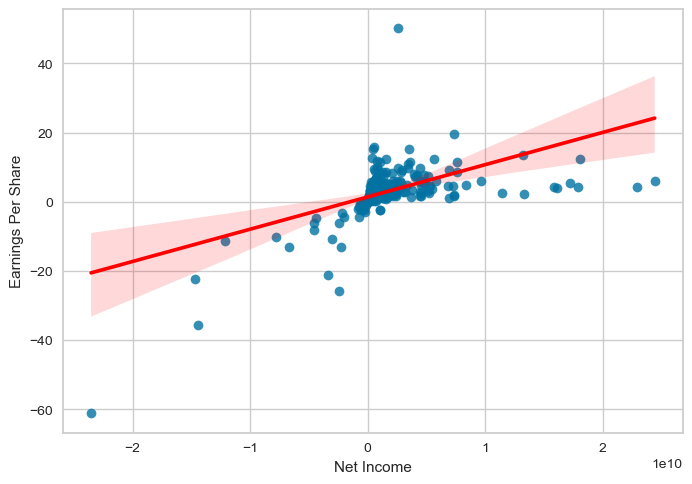

In [69]:
#Net Income v Earnings Per Share
sns.regplot(
    data=df,
    x="Net Income",
    y="Earnings Per Share",
    line_kws={'color': 'red'}
)
plt.show()

##### Net Income Multivariate Observations:
- As noted in the heatmap, Net Income and Estimated Shares Outstanding have a .59 correlation
- Net Income and Earnings Per Share have a .56 correlation

### EDA Final Observations

- Mean Price change over the observed 13 week period was 4.08%
  - First Solar Inc had the greatest positive price change at 55.05%
  - Kinder Morgan had the most negative price change at -47.13%
  - The Healthcare sector had the most positive price change (mean: 9.59%, median: 10.32%)
  - Energy had the most negative price change (mean: -9.24%, median: -10.23%)
  - Of the 8 largest Sub Industries in the set, Healthcare Equpment had the most positive price change, while Oil & Gas Exploration & Production had the most negative change.
- Volatility
  - Southwestern Energy was the most volatile security while McDonald's Corp. was least volatile.
  - Energy stands out as the most volatile sector during the measured period; while Utilities and Consumer Staples compete for least volatile.
  - Of the 8 largest Sub Industries in the set, Oil & Gas Exploration & Production was most volatile and Electric Utilities was the least volatile.
- The Industrials sector has the greatest number of securities represented in this dataset with 53 while the Telecommunications Services sector has the fewest with 5.

## Data Preprocessing

### Outliers

Outliers were initially checked in the EDA sections.  While outliers throughout this dataset represent valid data rather than errors, several features (P/E Ratio, ROE, P/B Ratio) have extreme ranges that could disproportionately influence distance-based clustering. We'll build both a capped and uncapped version of the dataset in preprocessing and compare clustering outcomes on each.

In [70]:
def cap_outliers_iqr(data, columns, factor=1.5):
    """
    Caps outliers in specified columns using the IQR method.
    Values below Q1 - factor*IQR are set to that lower fence;
    values above Q3 + factor*IQR are set to that upper fence.

    Parameters:
        data    : pandas DataFrame
        columns : list of column names to cap
        factor  : IQR multiplier for fence calculation (default 1.5, standard)

    Returns:
        DataFrame with capped columns (original df is not modified)
    """
    data = data.copy()
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - factor * IQR
        upper_fence = Q3 + factor * IQR

        n_capped = ((data[col] < lower_fence) | (data[col] > upper_fence)).sum()
        print(f"{col}: capped {n_capped} values (fence: [{lower_fence:.2f}, {upper_fence:.2f}])")

        data[col] = data[col].clip(lower=lower_fence, upper=upper_fence)

    return data

In [71]:
# df_uncapped - retains all values as observed
df_uncapped = df.copy()

In [72]:
# df_capped   - IQR-based capping applied to features with extreme ranges
# We select factor 3.0 (as opposed to 1.5 used during detection) to cap only the extreme outliers
cols_to_cap = ['P/E Ratio', 'ROE', 'P/B Ratio']
df_capped = cap_outliers_iqr(df, cols_to_cap, factor=3.0)

P/E Ratio: capped 29 values (fence: [-35.12, 81.93])
ROE: capped 30 values (fence: [-42.00, 78.75])
P/B Ratio: capped 11 values (fence: [-29.16, 28.72])


### Scaling

In [73]:
#Create list of numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

In [74]:
# Scaling the uncapped data set before clustering
scaler_uncapped = StandardScaler()
uncapped_subset = df_uncapped[num_col].copy()
uncapped_subset_scaled = scaler_uncapped.fit_transform(uncapped_subset)

In [75]:
# Creating a dataframe from the scaled uncapped data
uncapped_subset_scaled_df = pd.DataFrame(uncapped_subset_scaled, columns=uncapped_subset.columns)

#Check
uncapped_subset_scaled_df.head()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,-0.393341,0.493950,0.272749,0.989601,-0.210698,-0.339355,1.554415,1.309399,0.107863,-0.652487,-0.506653
1,-0.220837,0.355439,1.137045,0.937737,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.311769,-0.504205
2,-0.367195,0.602479,-0.427007,-0.192905,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.391502,0.094941
3,0.133567,0.825696,-0.284802,-0.317379,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,0.947148,0.424333
4,-0.260874,-0.492636,0.296470,-0.265515,2.237018,0.133564,-0.202703,-0.374982,1.978399,3.293307,0.199196


In [76]:
# Scaling the capped data set before clustering
scaler_capped = StandardScaler()
capped_subset = df_capped[num_col].copy()
capped_subset_scaled = scaler_capped.fit_transform(capped_subset)

In [77]:
# Creating a dataframe from the scaled capped data
capped_subset_scaled_df = pd.DataFrame(capped_subset_scaled, columns=capped_subset.columns)

#Check
capped_subset_scaled_df.head()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,-0.393341,0.493950,0.272749,2.604554,-0.210698,-0.339355,1.554415,1.309399,0.107863,-1.179254,-0.785322
1,-0.220837,0.355439,1.137045,2.604554,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.450718,-0.781664
2,-0.367195,0.602479,-0.427007,-0.098071,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.621205,0.113526
3,0.133567,0.825696,-0.284802,-0.659655,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,2.241148,0.605674
4,-0.260874,-0.492636,0.296470,-0.425662,2.237018,0.133564,-0.202703,-0.374982,1.978399,2.596987,0.269294


## K-means Clustering

### Elbow Plots

#### Uncapped Elbow Plot

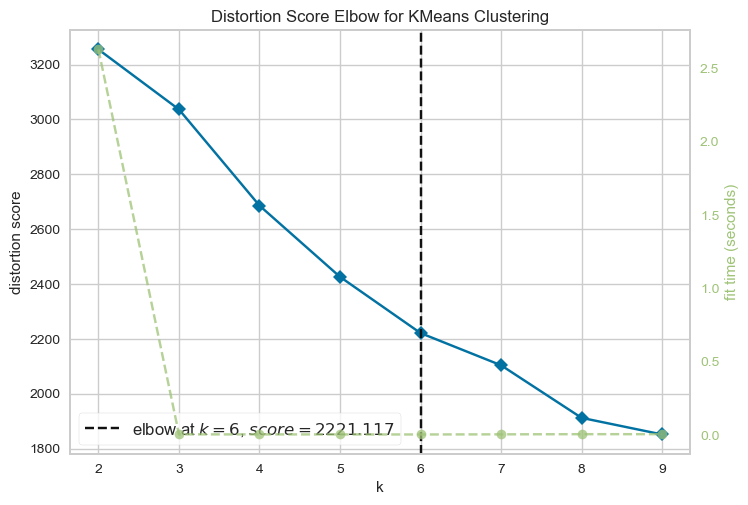

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [78]:
# Elbow Plot - Uncapped Data
kmeans_uncapped = KMeans(random_state=1)
elbow_visualizer_uncapped = KElbowVisualizer(kmeans_uncapped, k=(2, 10))
elbow_visualizer_uncapped.fit(uncapped_subset_scaled_df)
elbow_visualizer_uncapped.show()

#### Capped Elbow Plot

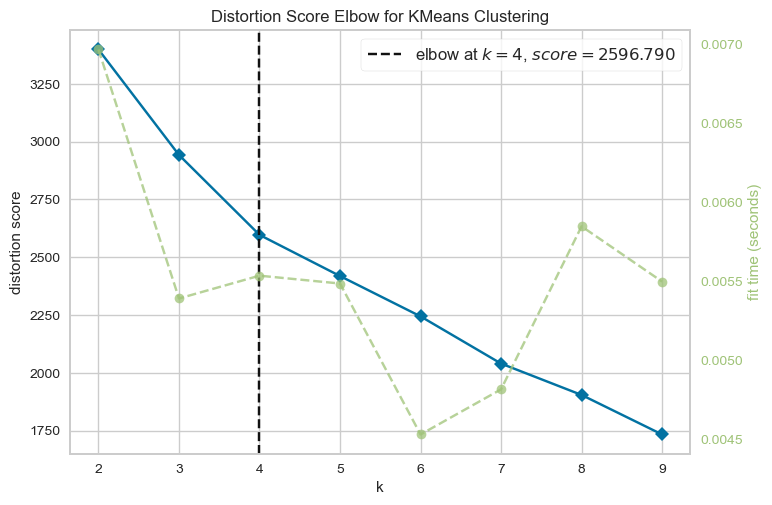

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [79]:
# Elbow Plot - Capped Data
kmeans_capped = KMeans(random_state=1)
elbow_visualizer_capped = KElbowVisualizer(kmeans_capped, k=(2, 10))
elbow_visualizer_capped.fit(capped_subset_scaled_df)
elbow_visualizer_capped.show()

#### Elbow Plot Observations:
- Uncapped Elbow k value: 6
- Capped Elbow k value: 4

### Silhouette Scores

#### Uncapped Silhouette Scores

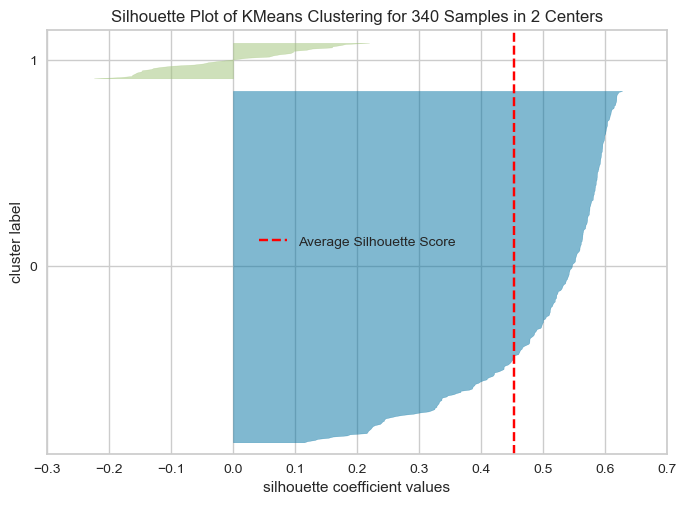

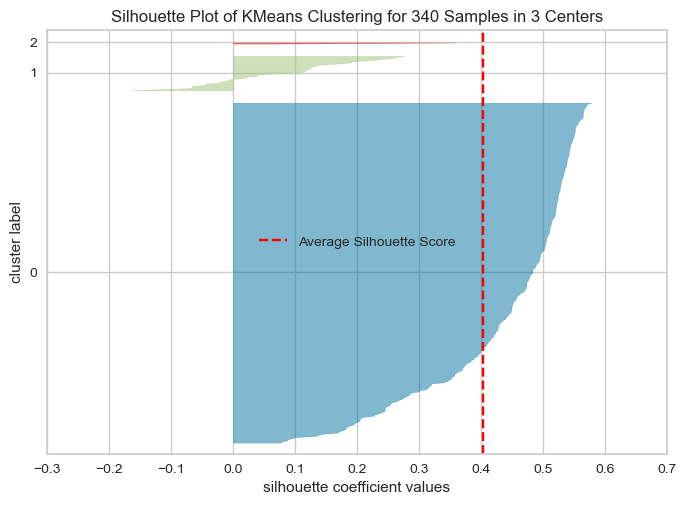

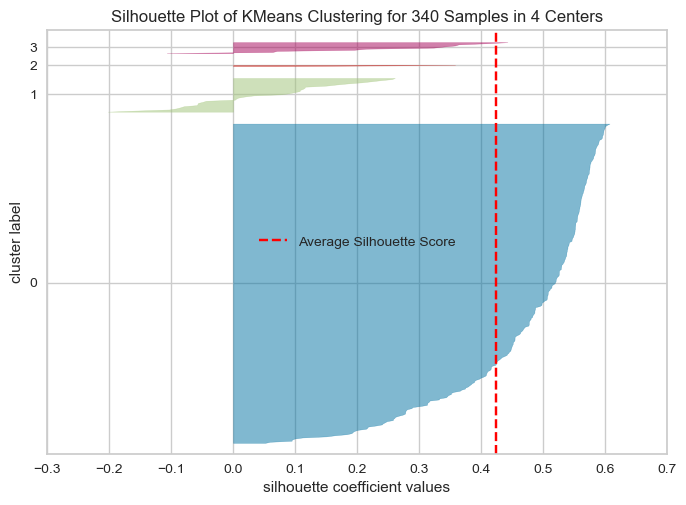

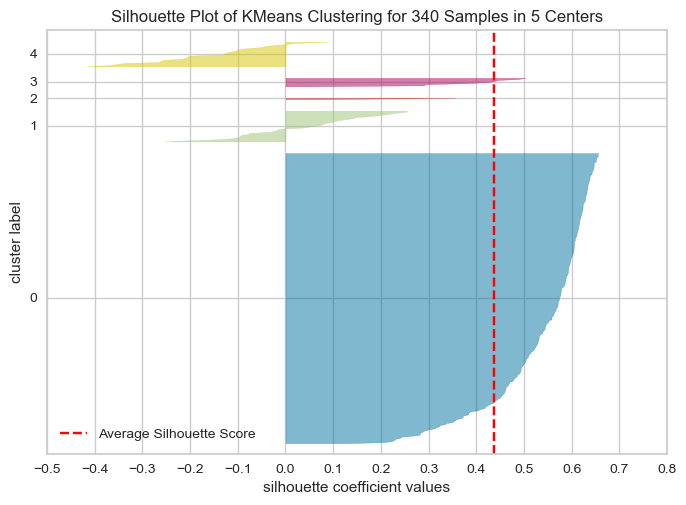

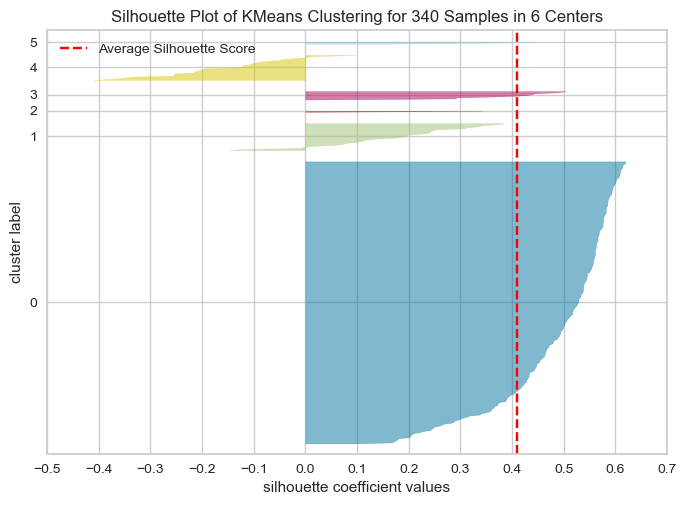

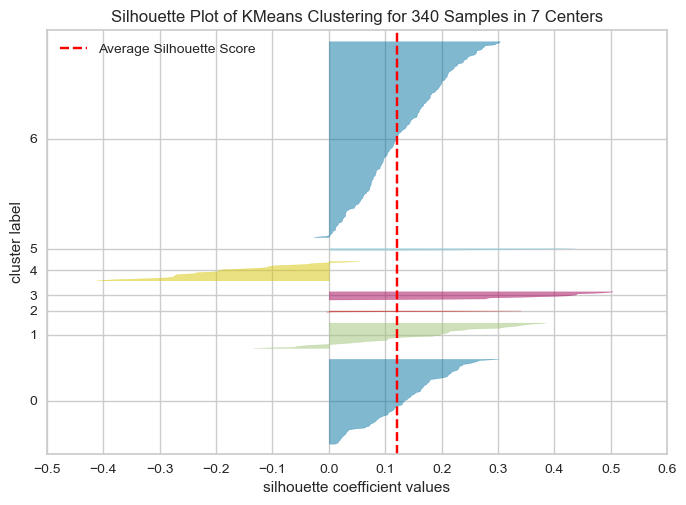

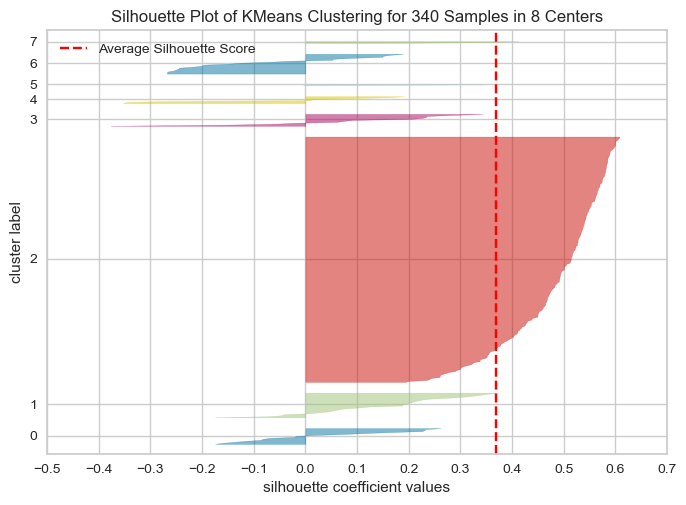

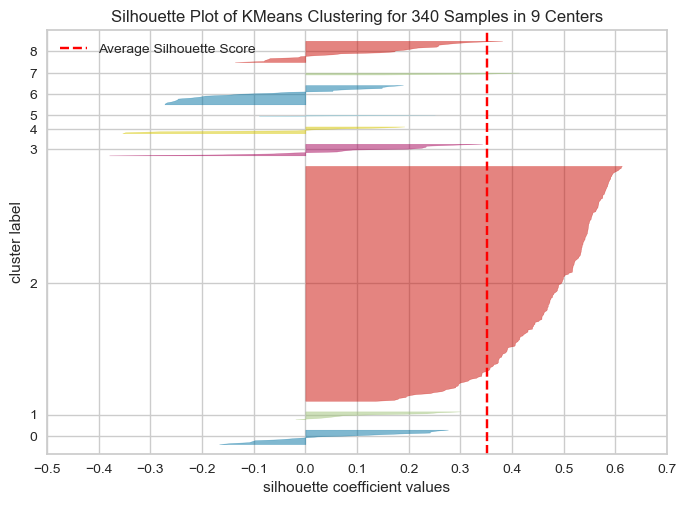

In [80]:
# Silhouette Visualizer - Uncapped Data
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=1)
    sil_visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
    sil_visualizer.fit(uncapped_subset_scaled_df)
    sil_visualizer.show()

In [81]:
# Numeric Silhouette Scores - Uncapped Data
print("Uncapped Data — Silhouette Scores by k:\n")
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(uncapped_subset_scaled_df)
    score = silhouette_score(uncapped_subset_scaled_df, labels)
    print(f"k = {k}: silhouette score = {score:.4f}")

Uncapped Data — Silhouette Scores by k:

k = 2: silhouette score = 0.4534
k = 3: silhouette score = 0.4037
k = 4: silhouette score = 0.4246
k = 5: silhouette score = 0.4382
k = 6: silhouette score = 0.4087
k = 7: silhouette score = 0.1207
k = 8: silhouette score = 0.3694
k = 9: silhouette score = 0.3519


In [82]:
# Check if k=2 is extremely unbalanced (isolating outliers)
kmeans_k2 = KMeans(n_clusters=2, random_state=1)
labels_k2 = kmeans_k2.fit_predict(uncapped_subset_scaled_df)
pd.Series(labels_k2).value_counts()

0    308
1     32
Name: count, dtype: int64

In [83]:
# Check cluster size balance for k=4 and k=5
for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(uncapped_subset_scaled_df)
    print(f"k={k}:\n{pd.Series(labels).value_counts()}\n")

k=4:
0    295
1     32
3     11
2      2
Name: count, dtype: int64

k=5:
0    275
1     30
4     24
3      9
2      2
Name: count, dtype: int64



#### Capped Silhouette Scores

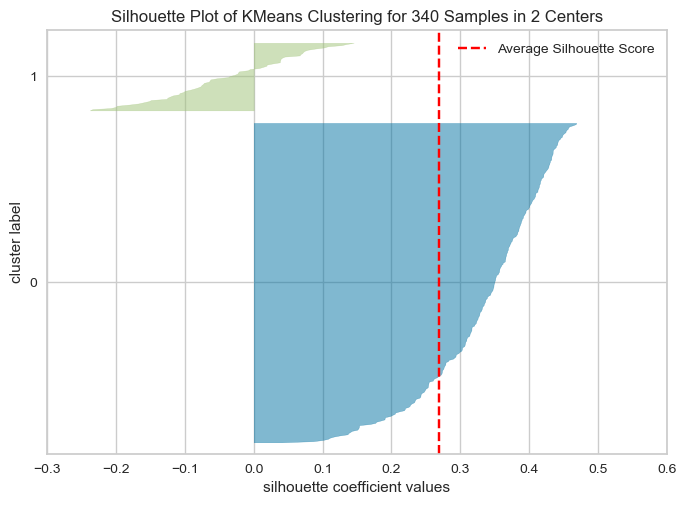

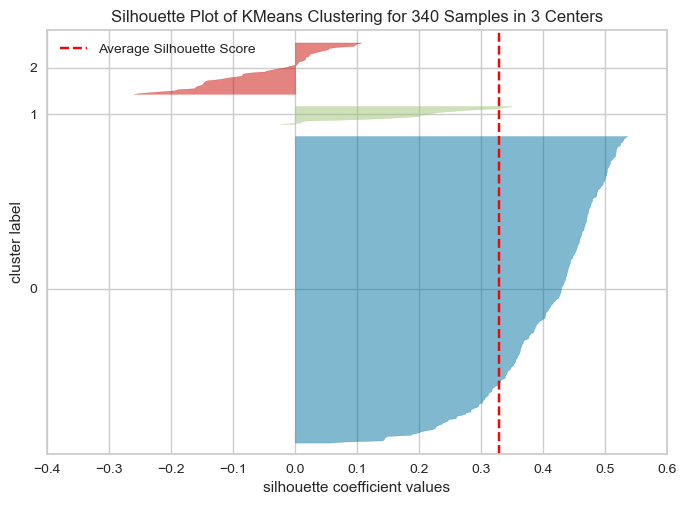

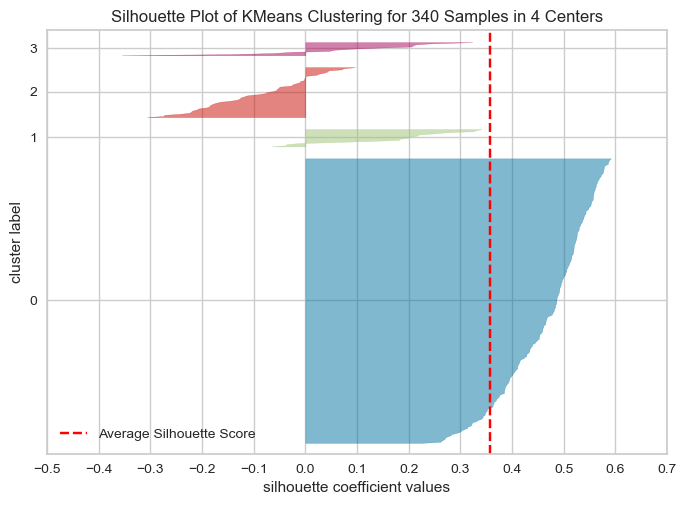

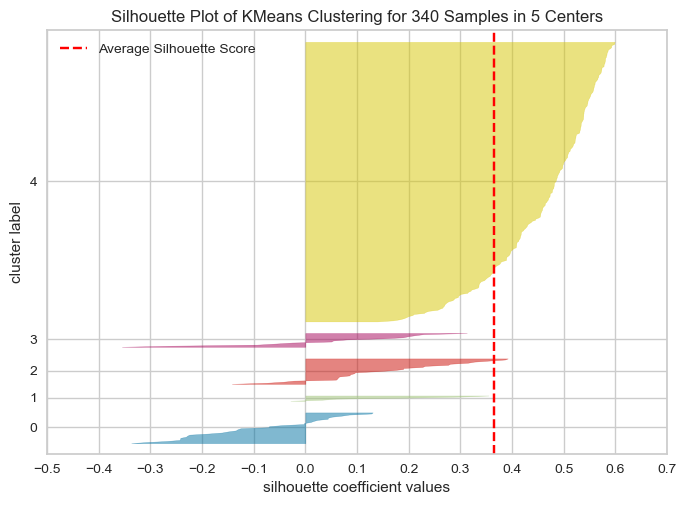

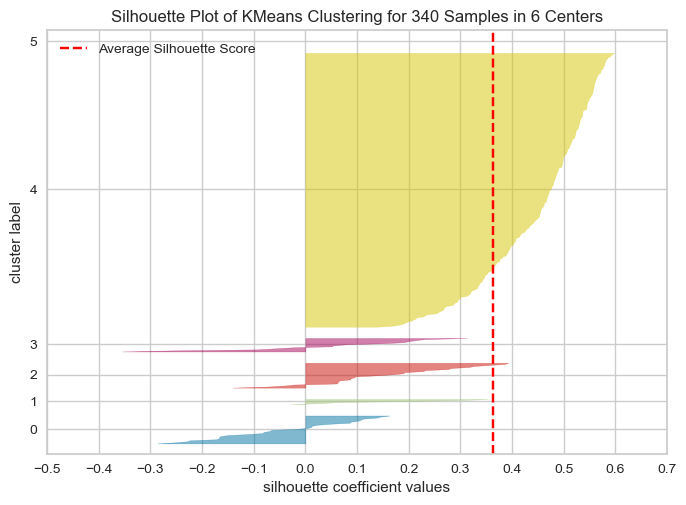

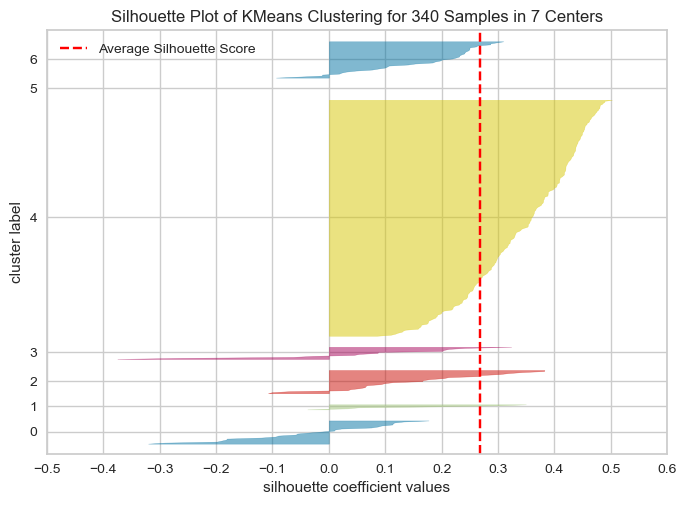

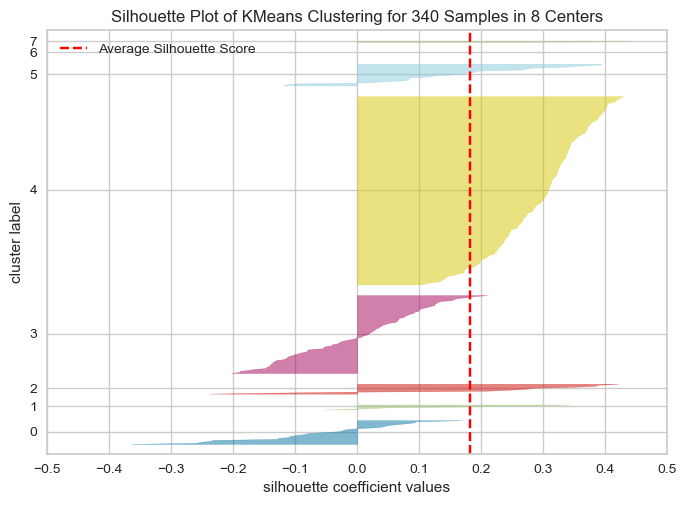

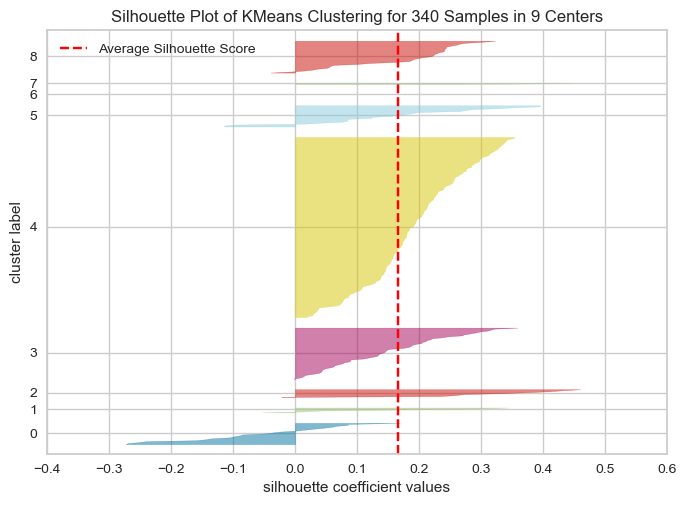

In [84]:
# Silhouette Visualizer - Capped Data
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=1)
    sil_visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
    sil_visualizer.fit(capped_subset_scaled_df)
    sil_visualizer.show()

In [85]:
# Numeric Silhouette Scores - Capped Data
print("Capped Data — Silhouette Scores by k:\n")
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(capped_subset_scaled_df)
    score = silhouette_score(capped_subset_scaled_df, labels)
    print(f"k = {k}: silhouette score = {score:.4f}")

Capped Data — Silhouette Scores by k:

k = 2: silhouette score = 0.2685
k = 3: silhouette score = 0.3294
k = 4: silhouette score = 0.3583
k = 5: silhouette score = 0.3656
k = 6: silhouette score = 0.3633
k = 7: silhouette score = 0.2682
k = 8: silhouette score = 0.1825
k = 9: silhouette score = 0.1655


In [86]:
# Check cluster size balance for k=4, k=5, k=6
for k in range (4,7):
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(capped_subset_scaled_df)
    print(f"k={k}:\n{pd.Series(labels).value_counts()}\n")

k=4:
0    263
2     47
1     17
3     13
Name: count, dtype: int64

k=5:
4    265
0     30
2     25
3     14
1      6
Name: count, dtype: int64

k=6:
4    266
0     28
2     25
3     14
1      6
5      1
Name: count, dtype: int64



### Final K-means Models

#### Uncapped K-means Model

##### Uncapped k value selection:
The elbow plot suggests k=6, but the curve is shallow and fairly linear rather than showing a sharp bend, making the elbow method alone a weak signal for this dataset.

Silhouette scores peak at k=2 (0.4534), which was initially suspected to reflect the algorithm isolating extreme outliers rather than finding meaningful structure, given the outlier-heavy features identified in EDA (P/E Ratio, ROE, P/B Ratio). However, checking the actual cluster sizes at k=2 (308 / 32) shows this isn't an extreme isolation split — a 32-stock cluster is too large to dismiss as pure outlier quarantine. This weakens, though doesn't fully eliminate, the case against k=2; it may still be capturing a coarse "typical vs. atypical" split rather than actionable segmentation for portfolio diversification purposes.

Excluding k=2 and k=7 (the latter's collapsed score of 0.1207 suggests an unstable or degenerate split), the next-highest silhouette scores belong to k=5 (0.4382) and k=4 (0.4246). Cluster size distributions at both are similarly imbalanced — k=4 splits into 295/32/11/2, and k=5 into 275/30/24/9/2. Notably, both k=4 and k=5 produce a persistent 2-Security cluster, suggesting a small set of extreme outliers separates out consistently regardless of the chosen k.

Given comparable silhouette scores and comparable imbalance between k=4 and k=5, **we select k=5**, as it offers one additional segment of meaningful size (24 stocks) without materially higher imbalance, providing marginally more granular groupings for portfolio diversification while remaining consistent with the elbow plot's general suggestion of higher k over lower k.

In [87]:
# Create final uncapped k-means model
kmeans_uncapped_final = KMeans(n_clusters=5, random_state=1)
kmeans_uncapped_final.fit(uncapped_subset_scaled_df)

KMeans(n_clusters=5, random_state=1)

In [88]:
#Copy original data to build new df with cluster label column
df_uncapped_k_clusters = df.copy()

#Add kmeans cluster labels to original data
df_uncapped_k_clusters['KM_segments'] = kmeans_uncapped_final.labels_

# Check
df_uncapped_k_clusters.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,KM_segments
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219,0
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068,0
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171,0
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651,0
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810,1


#### Uncapped k-means Cluster Profiling

In [89]:
# Show cluster sizes
print("Cluster sizes:")
print(df_uncapped_k_clusters['KM_segments'].value_counts().sort_index())
print()

Cluster sizes:
KM_segments
0    275
1     30
2      2
3      9
4     24
Name: count, dtype: int64



In [90]:
#Display cluster profile means
uncapped_cluster_profile_mean = df_uncapped_k_clusters.groupby('KM_segments')[num_col].mean()
print("Cluster profile (means):")
uncapped_cluster_profile_mean

Cluster profile (means):


,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
KM_segments,,,,,,,,,,,
0,72.738269,5.179897,1.380738,34.825455,53.138182,-1.014729e+07,1.488642e+09,3.636164,4.379616e+08,23.680917,-3.395254
1,65.106668,-11.888125,2.722141,44.000000,61.400000,-3.685830e+07,-2.137169e+09,-5.560333,5.297142e+08,113.488924,0.905486
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1.292500e+09,-1.910650e+10,-41.815000,5.195740e+08,60.748608,1.565141
3,46.672222,5.166566,1.079367,25.000000,58.333333,-3.040667e+09,1.484844e+10,3.435556,4.564960e+09,15.596051,-6.354193
4,211.164720,12.456786,1.699388,30.708333,280.250000,2.197085e+09,2.808601e+09,6.818333,7.389574e+08,37.895420,15.682619


In [91]:
# Display cluster profile medians
uncapped_cluster_profile_median = df_uncapped_k_clusters.groupby('KM_segments')[num_col].median()
uncapped_cluster_profile_median

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
KM_segments,,,,,,,,,,,
0,60.849998,4.931317,1.337924,15.0,41.0,1.603000e+06,7.830000e+08,3.040,2.917294e+08,19.216783,-1.715880
1,32.280000,-12.435553,2.649248,13.0,47.0,-1.472000e+07,-6.423425e+08,-1.760,4.043620e+08,93.089287,1.344887
2,24.485001,-13.351992,3.482611,802.0,51.0,-1.292500e+09,-1.910650e+10,-41.815,5.195740e+08,60.748608,1.565141
3,46.220001,5.532912,1.130337,11.0,74.0,-1.649000e+09,1.615000e+10,3.850,4.194805e+09,13.004785,-1.886881
4,111.400002,12.771037,1.608102,19.5,216.5,1.596915e+08,5.677665e+08,3.945,2.357307e+08,30.008298,6.735946


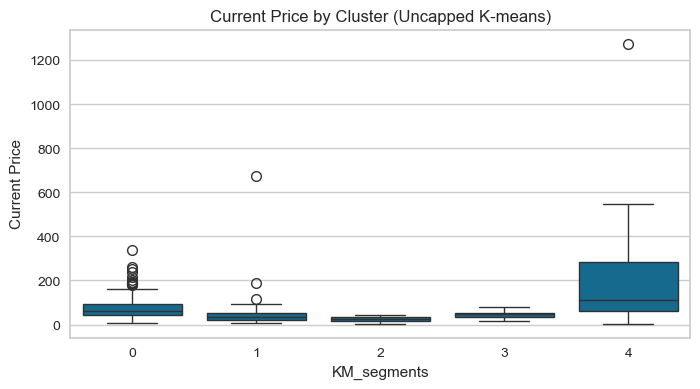

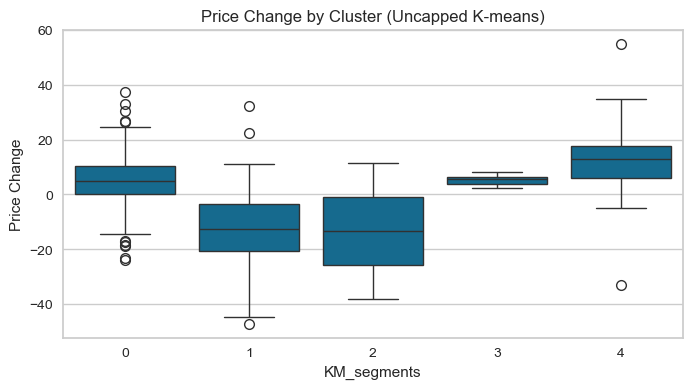

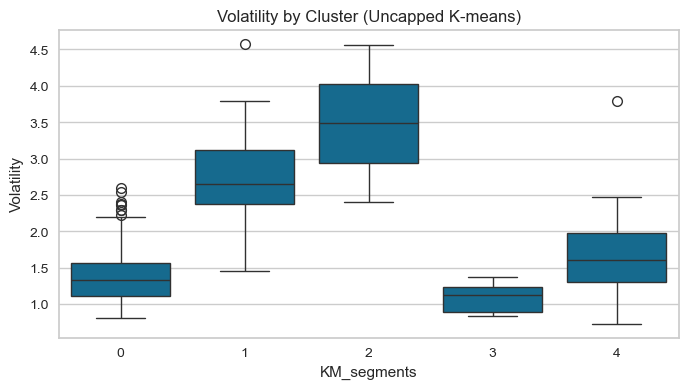

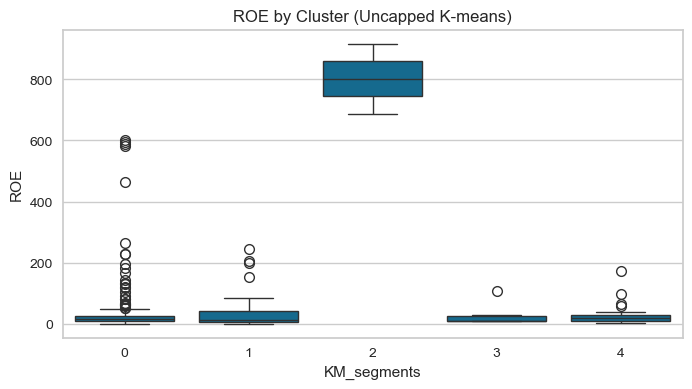

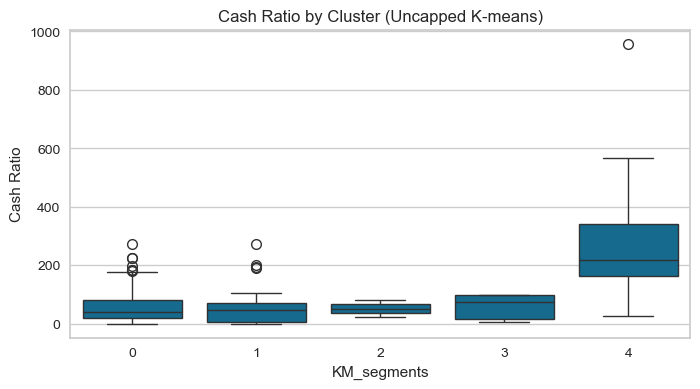

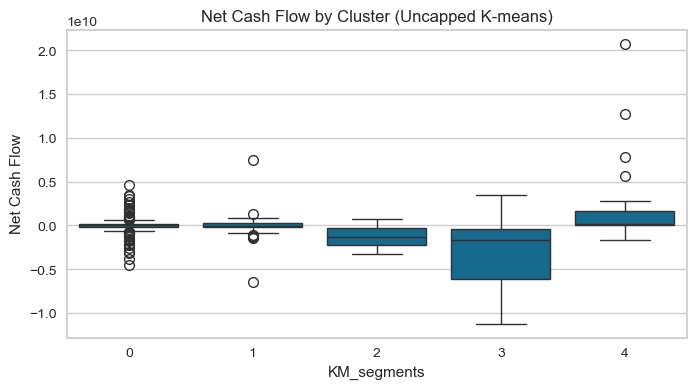

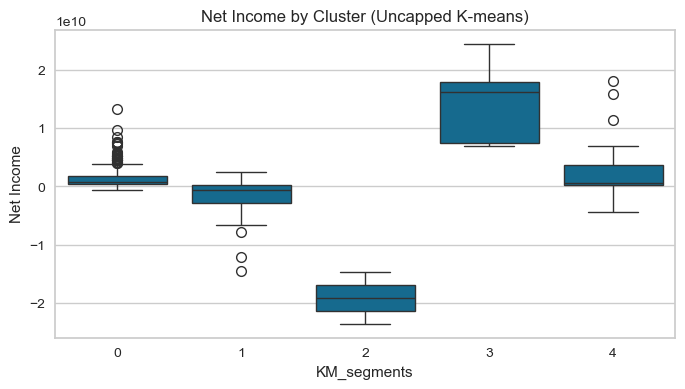

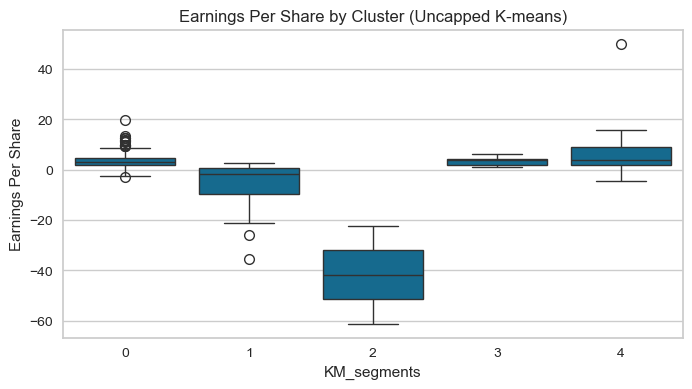

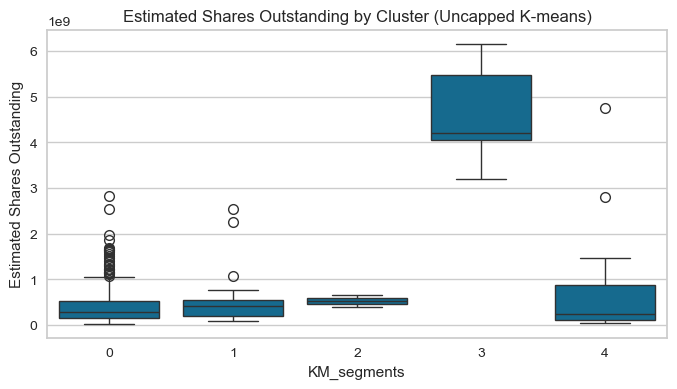

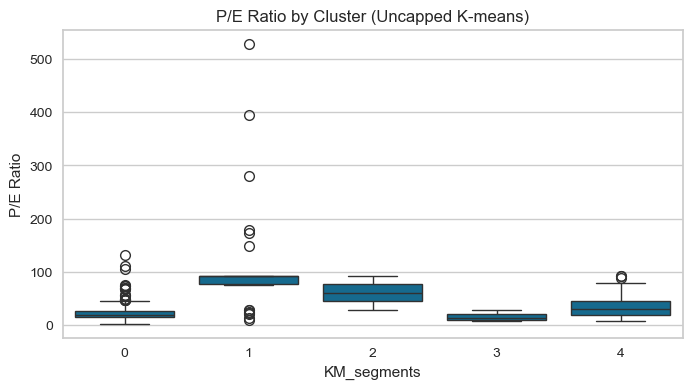

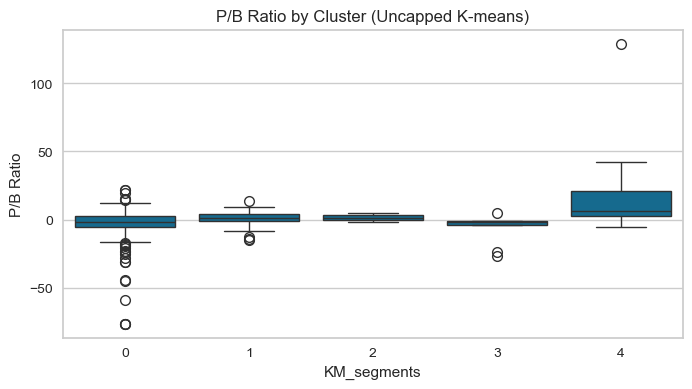

In [92]:
# Visual comparison of cluster features
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_uncapped_k_clusters, x='KM_segments', y=col)
    plt.title(f'{col} by Cluster (Uncapped K-means)')
    plt.show()

In [93]:
# Check  how clusters align with sectors
uncapped_sector_composition = pd.crosstab(df_uncapped_k_clusters['KM_segments'], df_uncapped_k_clusters['GICS Sector'])
uncapped_sector_composition

GICS Sector,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Telecommunications Services,Utilities
KM_segments,,,,,,,,,,,
0,33,17,5,45,29,52,24,18,26,2,24
1,1,0,21,0,1,1,4,2,0,0,0
2,0,0,2,0,0,0,0,0,0,0,0
3,1,1,1,3,1,0,0,0,0,2,0
4,5,1,1,1,9,0,5,0,1,1,0


In [94]:
# List companies in each cluster
for cluster in sorted(df_uncapped_k_clusters['KM_segments'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df_uncapped_k_clusters[df_uncapped_k_clusters['KM_segments'] == cluster]['Security'].tolist())


--- Cluster 0 ---
['American Airlines Group', 'AbbVie', 'Abbott Laboratories', 'Adobe Systems Inc', 'Archer-Daniels-Midland Co', 'Ameren Corp', 'American Electric Power', 'AFLAC Inc', 'American International Group, Inc.', 'Apartment Investment & Mgmt', 'Assurant Inc', 'Arthur J. Gallagher & Co.', 'Akamai Technologies Inc', 'Albemarle Corp', 'Alaska Air Group Inc', 'Allstate Corp', 'Allegion', 'Applied Materials Inc', 'AMETEK Inc', 'Affiliated Managers Group Inc', 'Ameriprise Financial', 'American Tower Corp A', 'AutoNation Inc', 'Anthem Inc.', 'Aon plc', 'Amphenol Corp', 'Arconic Inc', 'Activision Blizzard', 'AvalonBay Communities, Inc.', 'Broadcom', 'American Water Works Company Inc', 'American Express Co', 'Boeing Company', 'Baxter International Inc.', 'BB&T Corporation', 'Bard (C.R.) Inc.', 'The Bank of New York Mellon Corp.', 'Ball Corp', 'Bristol-Myers Squibb', 'Boston Scientific', 'BorgWarner', 'Boston Properties', 'Caterpillar Inc.', 'Chubb Limited', 'CBRE Group', 'Crown Castle

##### Uncapped k-means Cluster Profiling Observations:
- Cluster assignments derive from uncapped/scaled features; profiling uses original uncapped values for interpretability
- Clusters are largely uneven with the largest cluster having 275 securities and the smallest having 2
- Clusters do not align cleanly with sectors, but some patterns do emerge:
    - Cluster 0 is 18.9% Industrials sector
    - Cluster 1 is 70% Energy sector
    - Cluster 2 is 100% Energy sector (only 2 securities in the cluster)
    - Cluster 3 is 33.3% Financial sector
    - Cluster 4 is 37.5% Healthcare sector
- Cluster 0: Appears to represent moderately priced, relatively stable companies showing acceptable profitability and modest market momentum, but currently using more cash than they generate—suggesting either active investment for growth or a developing cash-flow weakness.
    - Largest cluster with 275 securities across every sector.
    - Mid cost tier
    - Moderate price gain
    - Low to moderate volatility
    - Negative cash flow
    - Average net income
    - Slightly above average earnings per share
- Cluster 1: Appears to represent companies that are losing money, consuming cash, and experiencing falling and highly volatile share prices.
    - Second largest cluster of 30 securities with 70% in the Energy sector.
    - Negative price change - second worst cluster
    - High volatility - second worst cluster
    - Negative cash flow
    - Negative net income
    - Negative earnings per share
    - Highest P/E ratio
- Cluster 2: Appear to represent the worst outliers of cluster 1.  Highly distressed companies with falling prices.
    - Smallest cluster with only 2 securities; both companies in the energy sector
    - Lowest priced cluster
    - Most negative price change cluster
    - Highest volatility cluster
    - By far highest ROE (can happen when both net income and shareholder equity are negative)
    - Negative net cash flow
    - By far most negative net income
    - By far most negative earnings per share
- Cluster 3: Appears to represent large, established,  profitable companies whose stocks are priced cautiously because their balance sheets have negative shareholder equity.
    - Second smallest cluster with 9 securities spread across 6 sectors.
    - All 9 securities are industry leading household names.
    - Low to moderate price.
    - Moderate to above average price change.
    - Lowest volatility.
    - Lowest ROE
    - Highest net income
    - Moderate earnings per share
    - Highest outstanding shares
    - Lowest P/E ratio
    - Most negative P/B ratio
- Cluster 4: Appears to represent financially strong, highly profitable companies with abundant liquidity and strong cash generation, whose shares have risen because investors expect  performance to continue, but whose high valuation relative to book value may already reflect substantial optimism.  These were the 'best bets' from the 13 week period.  These are the securities that outperformed, but came with a slightly higher risk than cluster 3.  
    - Middle of the pack in size with 24 securities across 8 sectors
    - Highest mean and median price, but with a broad range.
    - Most positive price change.
    - Moderate volatility.
    - Highest cash ratio.
    - Most positive net cash flow
    - High net income
    - Highest earnings per share
    - Highest P/B ratio

#### Capped K-means Model

##### Capped k value selection:
The elbow plot suggests k=4, with a somewhat more defined bend than the uncapped data's elbow, though still not sharply pronounced.

Silhouette scores peak in a tight cluster at k=4, k=5, and k=6 (0.3583, 0.3656, 0.3633 respectively), all closely spaced and all containing negative blades, so no single k is decisively superior on score alone.

k=6 is ruled out first: in addition to scoring marginally below k=5, it introduces a singleton cluster (n=1), which is not a meaningfully usable segment. 

Between the remaining candidates, k=5 (0.3656) narrowly outscores k=4 (0.3583) and provides one additional segment of meaningful size. Both k=4 and k=5 show comparably balanced cluster sizes overall, with a single dominant cluster (~263-265 stocks) alongside progressively smaller segments.  Neither introduces a cluster small enough to be dismissed as noise.

Given k=5's higher silhouette score and its more granular segmentation compared to k=4, **we select k=5** for the capped dataset.

In [95]:
# Create final Capped k-means model
kmeans_capped_final = KMeans(n_clusters=5, random_state=1)
kmeans_capped_final.fit(capped_subset_scaled_df)

KMeans(n_clusters=5, random_state=1)

In [96]:
#Copy original data to build new df with cluster label column
df_capped_k_clusters = df.copy()

#Add kmeans cluster labels to original data
df_capped_k_clusters['KM_segments'] = kmeans_capped_final.labels_

# Check
df_capped_k_clusters.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,KM_segments
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219,4
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068,4
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171,4
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651,0
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810,0


#### Capped k-means Cluster Profiling

In [97]:
print("Cluster sizes:")
print(df_capped_k_clusters['KM_segments'].value_counts().sort_index())
print()

Cluster sizes:
KM_segments
0     30
1      6
2     25
3     14
4    265
Name: count, dtype: int64



In [98]:
# Feature means by cluster
capped_cluster_profile_mean = df_capped_k_clusters.groupby('KM_segments')[num_col].mean()
print("Capped cluster profile (means):")
capped_cluster_profile_mean

Capped cluster profile (means):


,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
KM_segments,,,,,,,,,,,
0,220.142110,13.311346,1.713892,31.633333,263.033333,2.324216e+08,1.004309e+09,5.846000,5.480887e+08,66.266075,12.793833
1,34.946666,-15.261216,3.084133,382.333333,61.333333,-2.717467e+08,-1.176566e+10,-29.598333,4.620340e+08,70.596172,2.483143
2,36.796401,-14.115139,2.740034,24.880000,51.480000,1.426644e+08,-1.331360e+09,-3.027600,5.847487e+08,91.135963,1.673419
3,54.497142,5.243104,1.158173,32.142857,73.428571,6.615714e+08,1.404886e+10,4.638571,3.708717e+09,15.677408,-3.602990
4,71.684468,5.125615,1.374321,34.520755,49.939623,2.686838e+06,1.453417e+09,3.611415,4.167321e+08,23.316338,-3.676650


In [99]:
# Feature medians by cluster
capped_cluster_profile_median = df_capped_k_clusters.groupby('KM_segments')[num_col].median()
capped_cluster_profile_median

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
KM_segments,,,,,,,,,,,
0,118.950001,13.951268,1.648371,21.0,216.5,153950000.0,5.924000e+08,3.055,2.228991e+08,31.201575,6.305761
1,32.280000,-14.940726,2.672613,224.5,46.0,182260000.0,-1.330500e+10,-24.175,3.955134e+08,93.089287,2.360522
2,26.420000,-12.312367,2.692546,10.0,45.0,-61744000.0,-5.710000e+08,-0.790,4.067536e+08,93.089287,1.273530
3,48.985000,5.737515,1.188738,11.5,76.5,-625000000.0,1.461650e+10,4.015,4.060982e+09,13.004785,-1.316920
4,60.599998,4.910983,1.337793,15.0,40.0,-395000.0,7.689960e+08,3.040,2.870130e+08,19.164336,-1.883912


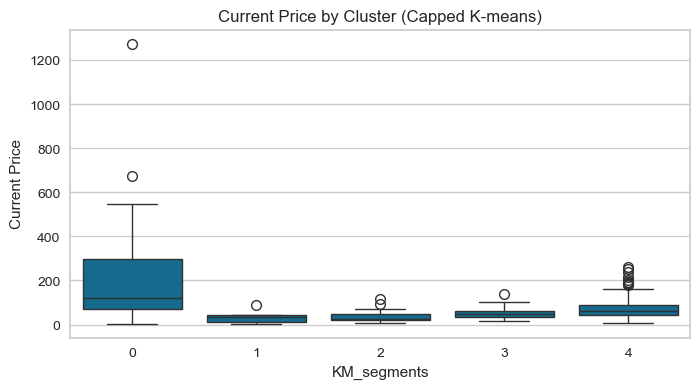

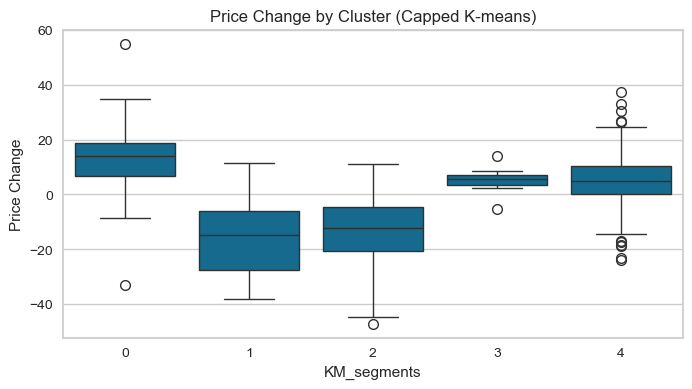

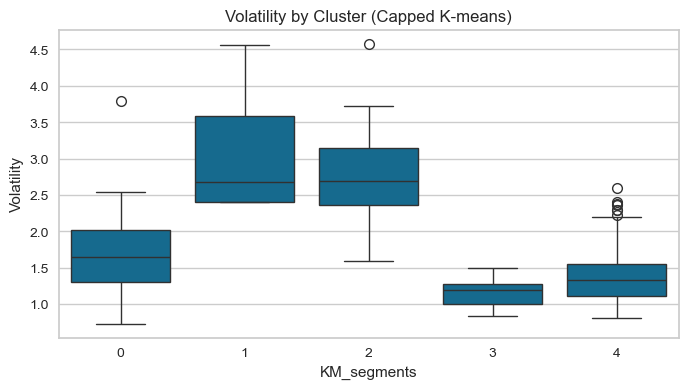

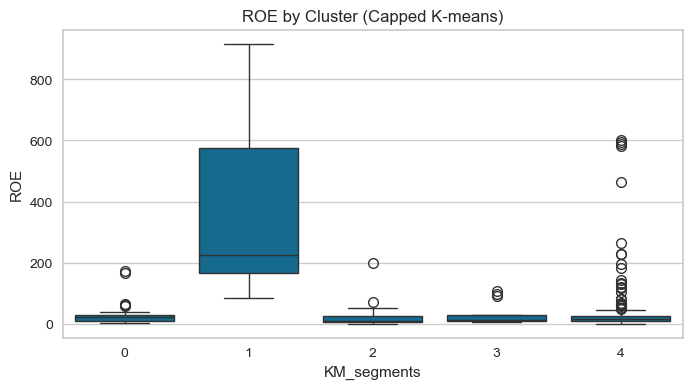

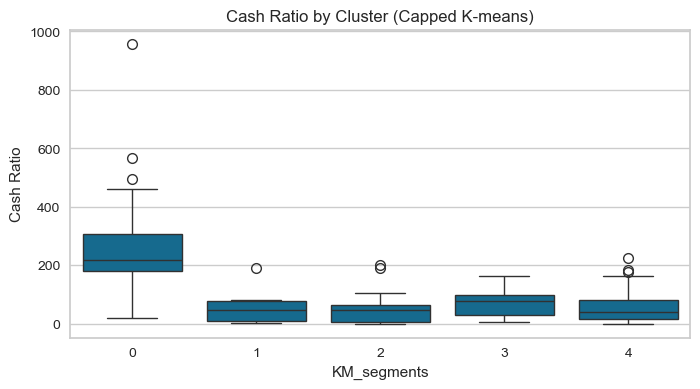

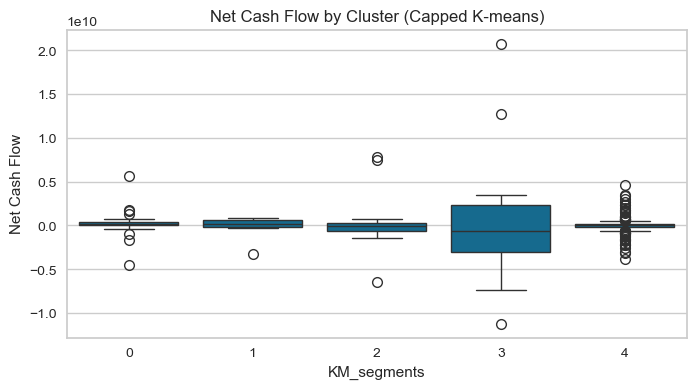

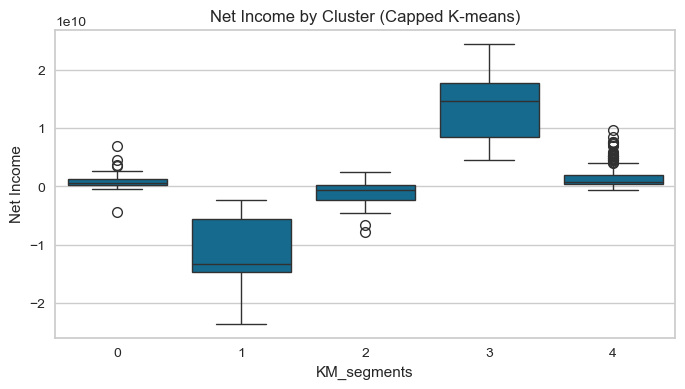

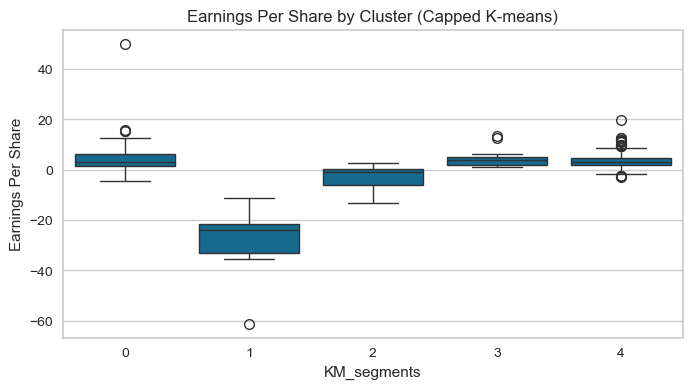

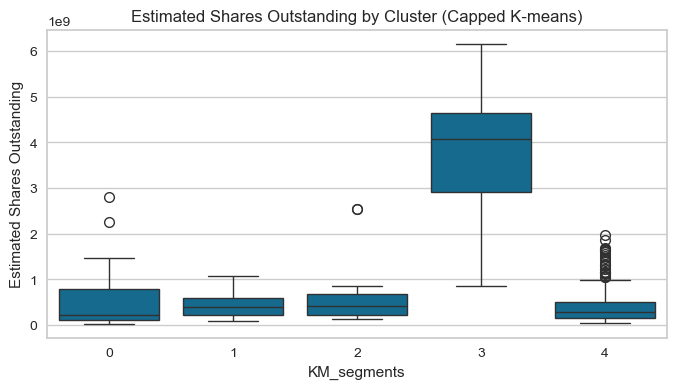

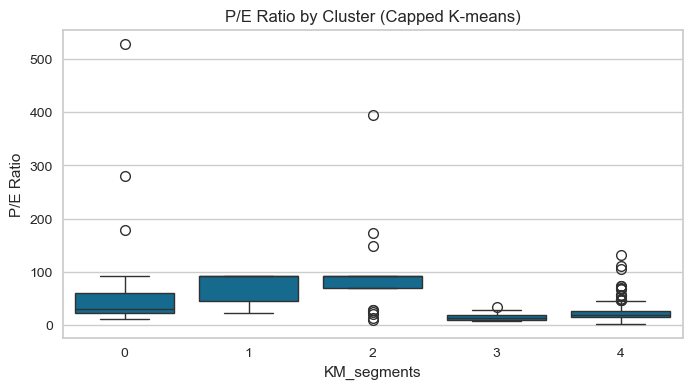

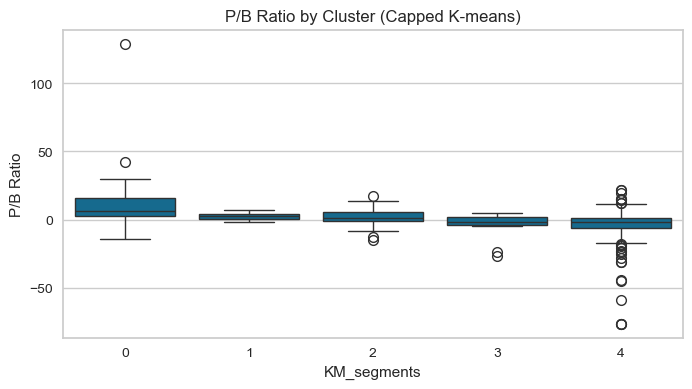

In [100]:
# Boxplots of features across capped clusters
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_capped_k_clusters, x='KM_segments', y=col)
    plt.title(f'{col} by Cluster (Capped K-means)')
    plt.show()

In [101]:
# Check  how clusters align with sectors
capped_sector_composition = pd.crosstab(df_capped_k_clusters['KM_segments'], df_capped_k_clusters['GICS Sector'])
capped_sector_composition

GICS Sector,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Telecommunications Services,Utilities
KM_segments,,,,,,,,,,,
0,6,1,0,1,10,0,9,1,1,1,0
1,0,0,5,0,0,0,0,1,0,0,0
2,0,0,19,0,0,1,3,1,1,0,0
3,1,1,1,4,3,0,2,0,0,2,0
4,33,17,5,44,27,52,19,17,25,2,24


In [102]:
# List companies in each cluster
for cluster in sorted(df_capped_k_clusters['KM_segments'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df_capped_k_clusters[df_capped_k_clusters['KM_segments'] == cluster]['Security'].tolist())


--- Cluster 0 ---
['Adobe Systems Inc', 'Analog Devices, Inc.', 'Alliance Data Systems', 'Alexion Pharmaceuticals', 'Amgen Inc', 'Amazon.com Inc', 'Broadcom', 'BIOGEN IDEC Inc.', 'Celgene Corp.', 'Chipotle Mexican Grill', 'eBay Inc.', 'Equinix', 'Edwards Lifesciences', 'Facebook', 'First Solar Inc', 'Frontier Communications', 'Intuitive Surgical Inc.', "McDonald's Corp.", "Moody's Corp", 'Monster Beverage', 'Mettler Toledo', 'Newmont Mining Corp. (Hldg. Co.)', 'Priceline.com Inc', 'Regeneron', 'Skyworks Solutions', 'TripAdvisor', 'Vertex Pharmaceuticals Inc', 'Waters Corporation', 'Wynn Resorts Ltd', 'Yahoo Inc.']

--- Cluster 1 ---
['Apache Corporation', 'Chesapeake Energy', 'Devon Energy Corp.', 'Freeport-McMoran Cp & Gld', 'Newfield Exploration Co', 'Cimarex Energy']

--- Cluster 2 ---
['Anadarko Petroleum Corp', 'Baker Hughes Inc', 'Cabot Oil & Gas', 'Concho Resources', 'EOG Resources', 'EQT Corporation', 'Halliburton Co.', 'Hess Corporation', 'Hewlett Packard Enterprise', 'Host H

##### Capped k-means Cluster Profiling Observations:
- Cluster assignments derive from capped/scaled features; profiling uses original uncapped values for interpretability
- Clusters are largely uneven with the largest cluster having 265 securities and the smallest having 6
- Clusters do not align cleanly with sectors, but some patterns do emerge:
    - Cluster 0 is 33.3% Healthcare sector
    - Cluster 1 is 83.3% Energy sector (5/6 securities)
    - Cluster 2 is 76% Energy sector
    - Cluster 3 is 28.6% Financial sector
    - Cluster 4 is 19.6% Industrials sector
- Cluster 0: Appears to represent a premium-priced, high-quality growth cluster made up of financially strong, profitable, cash-rich companies whose shares have risen sharply because investors expect continued performance.
    - Second largest cluster with 30 securities across 8 sectors.
    - Highest priced
    - Most positive price change
    - Moderate volatility
    - Slightly high ROE
    - Highest cash ratio
    - Mostly positive net cash flow
    - Mostly positive net income
    - High earnings per share
    - Moderate to high P/E ratio
    - Highest P/B ratio
- Cluster 1: Appears to represent distressed, highly speculative, low-priced securities experiencing severe losses and sharp, volatile price declines.
    - Smallest cluster with 6 securities; 5/6 in Energy Sector
    - Low Priced
    - Most Negative price change cluster
    - High volatility
    - Highest ROE cluster
    - Average cash ratio
    - Very negative net income
    - Most negative earnings per share cluster
    - High P/E ratio
    - Positive P/B ratio
- Cluster 2: Appears to represent weak, speculative, low-priced securities that are losing money and experiencing sharp, volatile declines, but whose losses are relatively modest on a per-share basis.  Struggling or early-stage companies that are not as deeply distressed as cluster 1. Differentiated from Cluster 1 mostly by much lower ROE and only slightly negative earnings per share.
    - Cluster of 25 securities across 5 sectors with 19 in the Energy sector.
    - Low priced
    - Very negative price change
    - Volatile
    - Negative net income
    - Slightly negative earnings per share
    - Highest P/E ratio cluster
    - Positive P/B ratio
- Cluster 3: Appears to represent large, mature, highly profitable, and stable companies whose stocks appear inexpensive relative to current earnings, but whose negative book value suggests substantial leverage, buybacks, etc.
    - Consists of 14 securities across 7 sectors
    - Moderate to low priced
    - Moderate price gain
    - Lowest volatility cluster
    - Moderate ROE
    - Highest net income cluster
    - High earnings per share
    - Most shares outstanding
    - Lowest P/E ratio
    - Negative P/B ratio
- Cluster 4: Appears to represent the broad “core market” of mostly average-performing companies.  Moderately priced, moderately profitable, and showing steady market gains.
    - Largest cluster consisting of 265 securities across all sectors
    - Moderate pricing
    - Moderate price gain
    - Moderate volatility
    - Moderate ROE
    - Middle of the road Net Income
    - Middle of the road Earnings per share
    - Middle of the road P/E ratio
    - Negative P/B ratio

### K-means Clustering Observations
- Capping outliers does not appear to have made much of a difference, especially considering both models use k=5.  While some companies shifted clusters, the overall cluster meanings appear to map onto eachother well and share many of the same companies.
    - Uncapped Cluster 0 -> Capped Cluster 4 (Core Market, steady gains)
    - Uncapped Cluster 1 -> Capped Cluster 2 ( Distressed, Volatile)
    - Uncapped Cluster 2 -> Capped Cluster 1 (Highly Distressed, Volatile)
    - Uncapped Cluster 3 -> Capped Cluster 3 (Large, established, reliable)
    - Uncapped Cluster 4 -> Capped Cluster 0 (Strong, highly profitable, best gains, premium priced)

## Hierarchical Clustering

### Cophenetic Correlation

#### Uncapped Cophenetic Correlation

In [103]:
# Distance metrics and linkage methods to test
distance_metrics = ['euclidean', 'cityblock', 'cosine', 'mahalanobis']
linkage_methods = ['single', 'complete', 'average', 'weighted']  # ward excluded here - euclidean only

#Empty list to store results
results_uncapped = []

#Iterate through each combination of distance metric and linkage method
for metric in distance_metrics:
    for method in linkage_methods:
        Z = linkage(uncapped_subset_scaled_df, method=method, metric=metric)
        coph_corr, coph_dists = cophenet(Z, pdist(uncapped_subset_scaled_df, metric=metric))
        results_uncapped.append({'Metric': metric, 'Linkage': method, 'Cophenetic Correlation': coph_corr})

In [104]:
# Ward, Centroid, and Median are Euclidean-only, thus run separately
euclidean_only_methods = ['ward', 'centroid', 'median']

for method in euclidean_only_methods:
    Z = linkage(uncapped_subset_scaled_df, method=method, metric='euclidean')
    coph_corr, coph_dists = cophenet(Z, pdist(uncapped_subset_scaled_df, metric='euclidean'))
    results_uncapped.append({'Metric': 'euclidean', 'Linkage': method, 'Cophenetic Correlation': coph_corr})

In [105]:
# Compile and sort metrics and linkage methods
coph_results_uncapped = pd.DataFrame(results_uncapped).sort_values('Cophenetic Correlation', ascending=False)
coph_results_uncapped

,Metric,Linkage,Cophenetic Correlation
2,euclidean,average,0.942254
14,mahalanobis,average,0.939341
17,euclidean,centroid,0.931401
12,mahalanobis,single,0.928056
6,cityblock,average,0.926052
0,euclidean,single,0.923227
18,euclidean,median,0.919869
4,cityblock,single,0.900821
15,mahalanobis,weighted,0.888851
3,euclidean,weighted,0.869378


##### Uncapped Cophenetic Correlation Observations:
- For the uncapped data, Euclidean distance with average linkage achieves the highest cophenetic correlation of .942

#### Capped Cophenetic Correlation

In [106]:
#Empty list to store results
results_capped = []

#Iterate through each combination of distance metric and linkage method
for metric in distance_metrics:
    for method in linkage_methods:
        Z = linkage(capped_subset_scaled_df, method=method, metric=metric)
        coph_corr, coph_dists = cophenet(Z, pdist(capped_subset_scaled_df, metric=metric))
        results_capped.append({'Metric': metric, 'Linkage': method, 'Cophenetic Correlation': coph_corr})

In [107]:
# Ward, Centroid, and Median are Euclidean-only, thus run separately
euclidean_only_methods = ['ward', 'centroid', 'median']

for method in euclidean_only_methods:
    Z = linkage(capped_subset_scaled_df, method=method, metric='euclidean')
    coph_corr, coph_dists = cophenet(Z, pdist(capped_subset_scaled_df, metric='euclidean'))
    results_capped.append({'Metric': 'euclidean', 'Linkage': method, 'Cophenetic Correlation': coph_corr})

In [108]:
# Compile and sort metrics and linkage methods
coph_results_capped = pd.DataFrame(results_capped).sort_values('Cophenetic Correlation', ascending=False)
coph_results_capped

,Metric,Linkage,Cophenetic Correlation
2,euclidean,average,0.931743
14,mahalanobis,average,0.930126
17,euclidean,centroid,0.922580
12,mahalanobis,single,0.912592
0,euclidean,single,0.906865
6,cityblock,average,0.882514
4,cityblock,single,0.855942
3,euclidean,weighted,0.852085
18,euclidean,median,0.827743
7,cityblock,weighted,0.806993


##### Capped Cophenetic Correlation Observations:
- For the capped data, euclidean distance with average linkage achieves the highest cophenetic correlation of .932 (slightly lower than the uncapped value of .942)

### Dendrograms

#### Uncapped Dendrograms

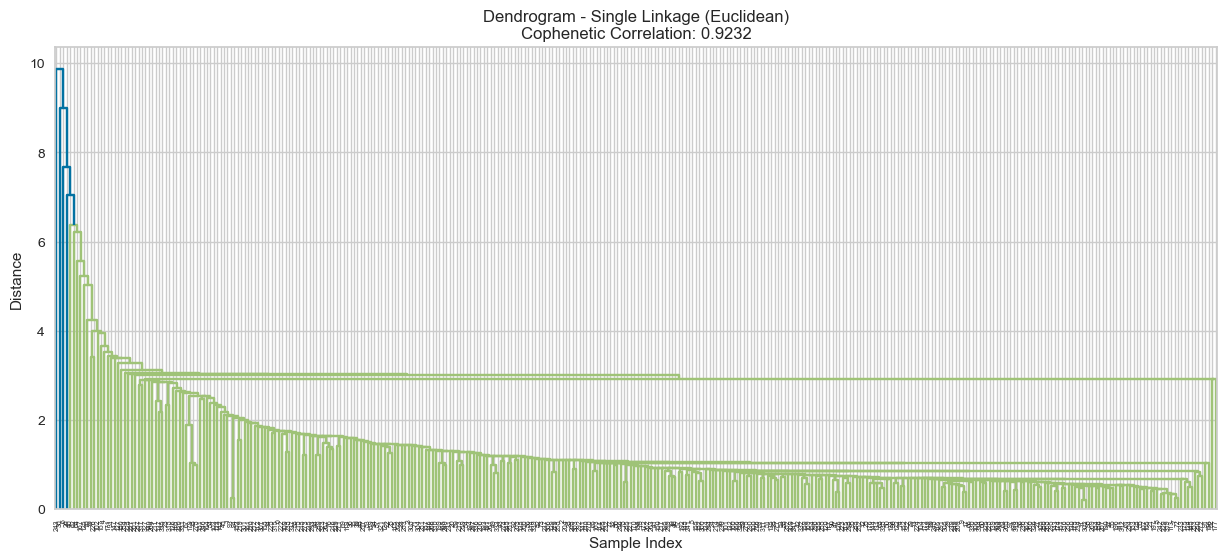

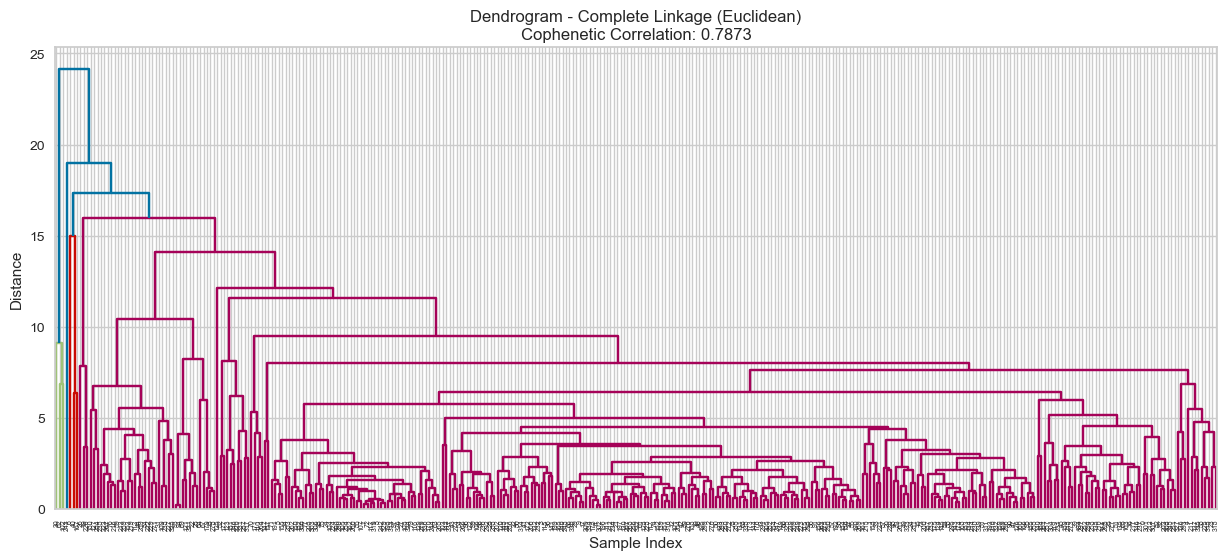

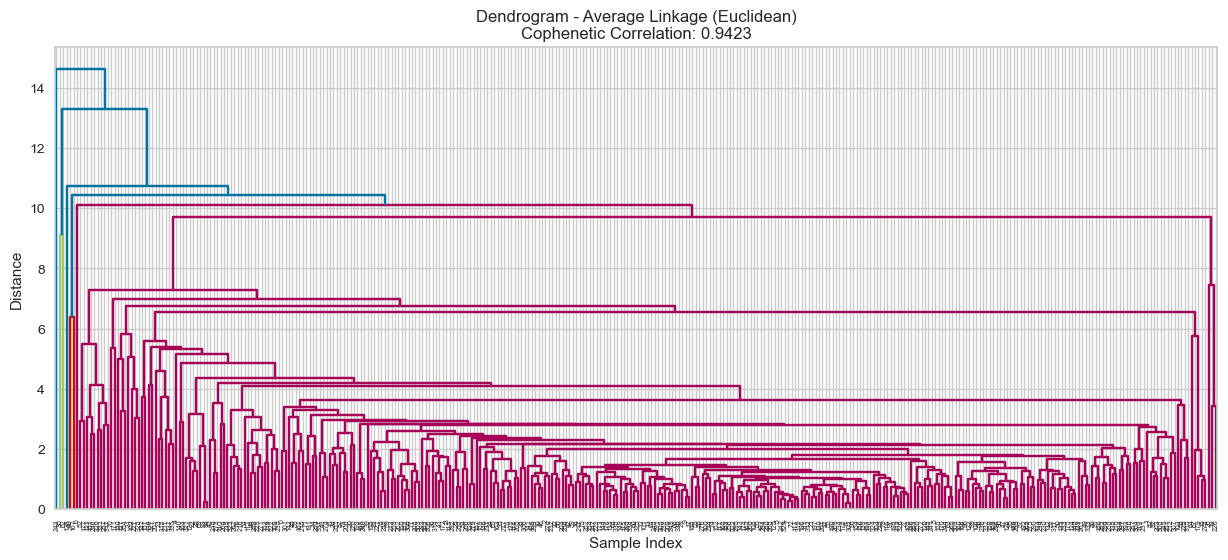

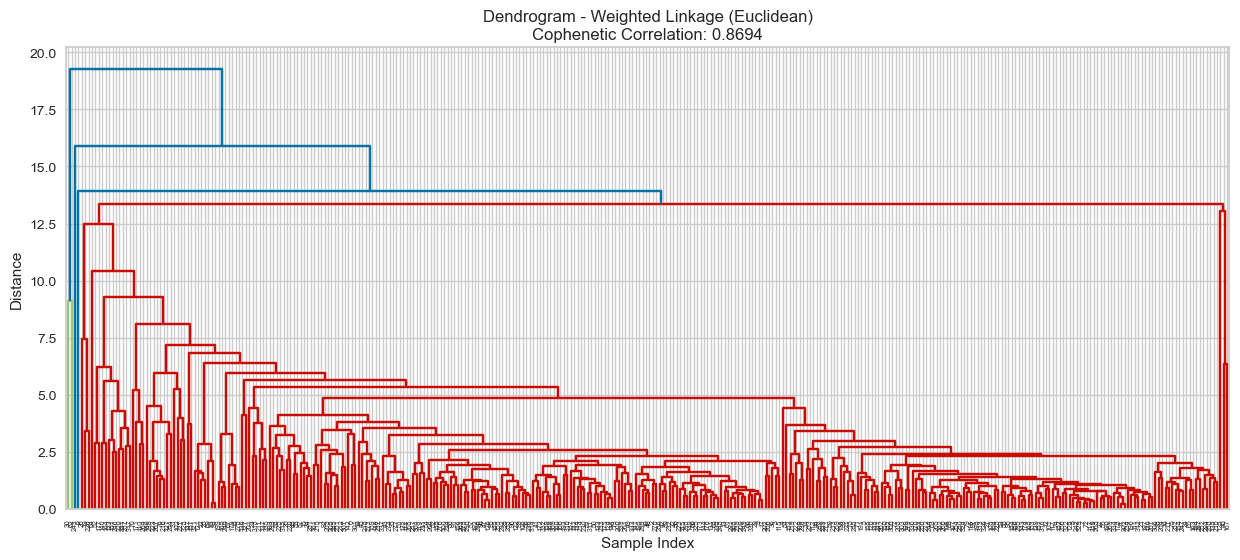

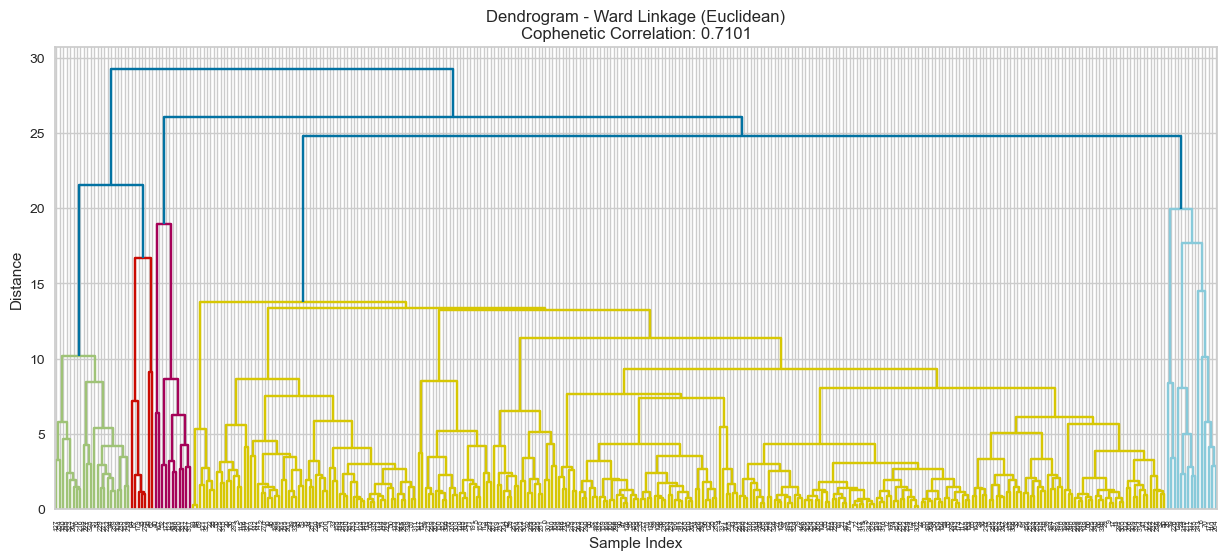

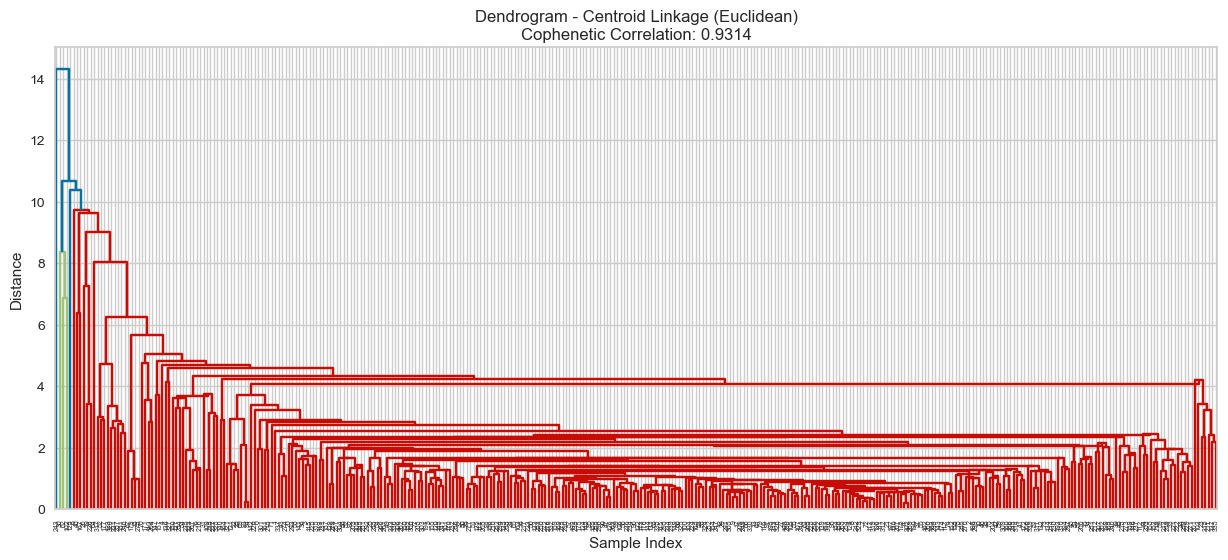

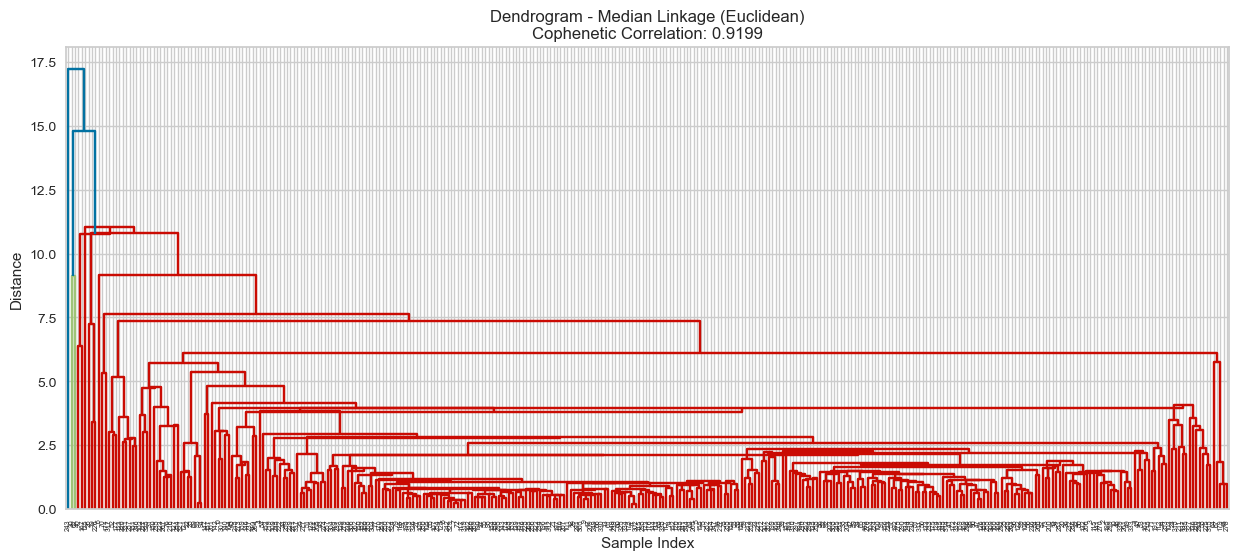

In [109]:
# Dendrograms for each linkage method (Euclidean distance) - Uncapped Data
euclidean_linkage_methods = ['single', 'complete', 'average', 'weighted', 'ward', 'centroid', 'median']

for method in euclidean_linkage_methods:
    Z = linkage(uncapped_subset_scaled_df, method=method, metric='euclidean')
    coph_corr, coph_dists = cophenet(Z, pdist(uncapped_subset_scaled_df, metric='euclidean'))

    plt.figure(figsize=(15, 6))
    dendrogram(Z)
    plt.title(f'Dendrogram - {method.capitalize()} Linkage (Euclidean)\nCophenetic Correlation: {coph_corr:.4f}')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.show()

In [110]:
# Manual Silhouette Score Loop - Hierarchical Clustering, Uncapped Data for euclidean distance, average linkage
print("Uncapped Data (Average Linkage) — Silhouette Scores by k:\n")

hc_scores_uncapped = []
k_range = range(2, 10)

for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='average', metric='euclidean')
    labels = hc.fit_predict(uncapped_subset_scaled_df)
    score = silhouette_score(uncapped_subset_scaled_df, labels)
    hc_scores_uncapped.append(score)
    print(f"k = {k}: silhouette score = {score:.4f}")

Uncapped Data (Average Linkage) — Silhouette Scores by k:

k = 2: silhouette score = 0.7419
k = 3: silhouette score = 0.7145
k = 4: silhouette score = 0.6514
k = 5: silhouette score = 0.6402
k = 6: silhouette score = 0.6272
k = 7: silhouette score = 0.6217
k = 8: silhouette score = 0.6142
k = 9: silhouette score = 0.5524


In [111]:
#Check cluster sizes for K=2 and K=3 with euclidean distance, average linkage
for k in [2, 3]:
    hc = AgglomerativeClustering(n_clusters=k, linkage='average', metric='euclidean')
    labels = hc.fit_predict(uncapped_subset_scaled_df)
    print(f"k={k}:\n{pd.Series(labels).value_counts()}\n")

k=2:
0    339
1      1
Name: count, dtype: int64

k=3:
0    337
2      2
1      1
Name: count, dtype: int64



In [112]:
# Manual Silhouette Score Loop - Hierarchical Clustering, Uncapped Data for euclidean distance, ward linkage
for k in range(2, 10):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = hc.fit_predict(uncapped_subset_scaled_df)
    score = silhouette_score(uncapped_subset_scaled_df, labels)
    print(f"k = {k}: silhouette score = {score:.4f}")

k = 2: silhouette score = 0.4274
k = 3: silhouette score = 0.4468
k = 4: silhouette score = 0.4649
k = 5: silhouette score = 0.4218
k = 6: silhouette score = 0.4282
k = 7: silhouette score = 0.4334
k = 8: silhouette score = 0.4373
k = 9: silhouette score = 0.4423


In [113]:
#Check cluster sizes for K=4 and K=5 with euclidean distance, ward linkage
for k in [4, 5]:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = hc.fit_predict(uncapped_subset_scaled_df)
    print(f"k={k}:\n{pd.Series(labels).value_counts()}\n")

k=4:
3    285
0     29
1     15
2     11
Name: count, dtype: int64

k=5:
3    285
4     22
0     15
2     11
1      7
Name: count, dtype: int64



##### Uncapped Dendrogram Observations:
- From the euclidean distance, average linkage dendrogram 3 appears to be the appropriate number of clusters
- Silhouette scores seem to show that k=2 is the right number of clusters
- Taking a closer look we see that for both K=2 and K=3 the cluster splits result in clusters of 1s and 2s which are not meaningful for our purposes
- Visually the clusters look much better in the euclidean, ward dendrogram
- For euclidean, ward k= 4 appears to be the right number of clusters in the dendrogram
- For euclidean, ward the silhouette score is also highest at k=4
- For euclidean, ward with K=4 cluster sizes are much better than with euclidean, average.
- **We will select euclidean, ward with k=4 for our uncapped heirarchical model**

#### Capped Dendrograms

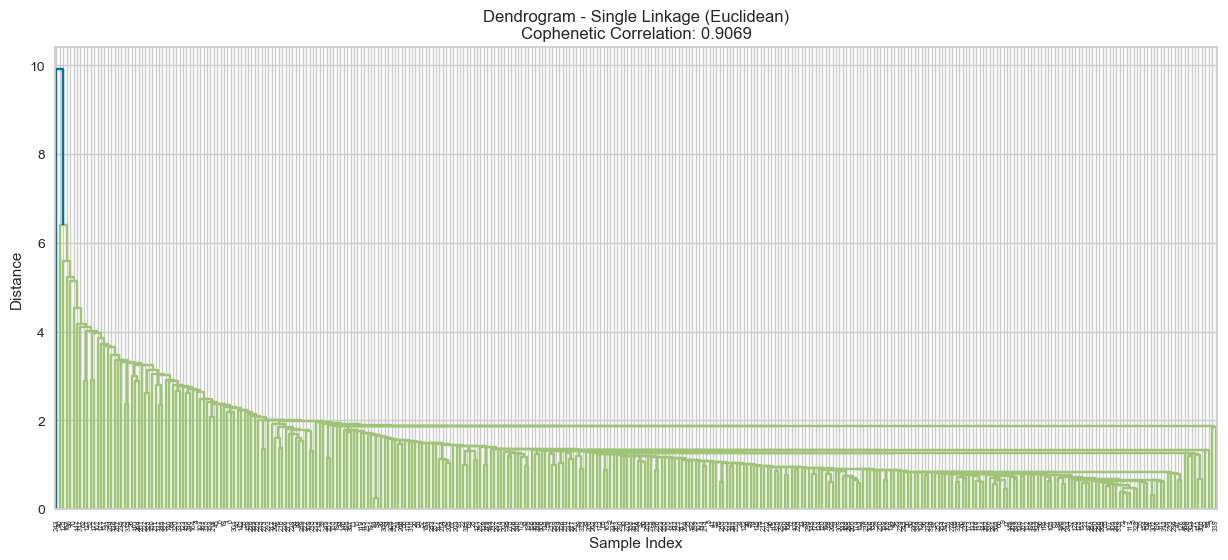

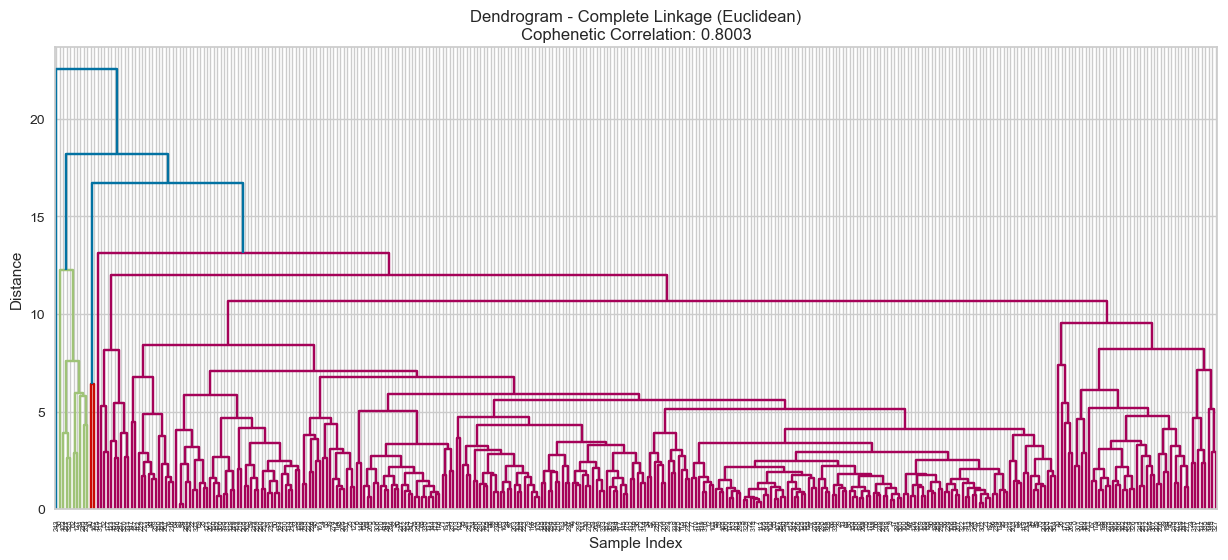

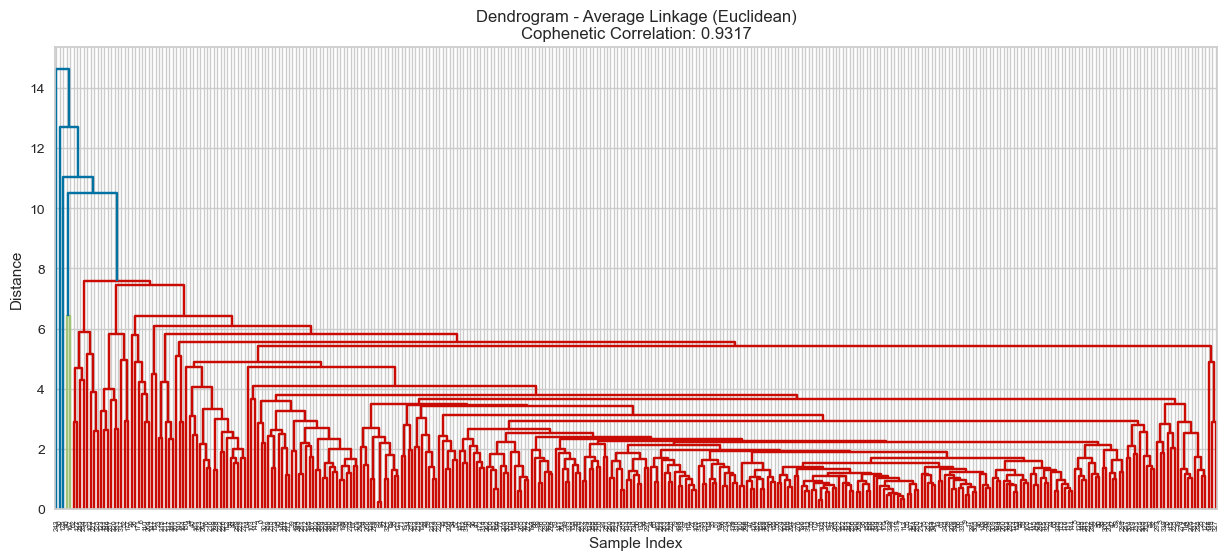

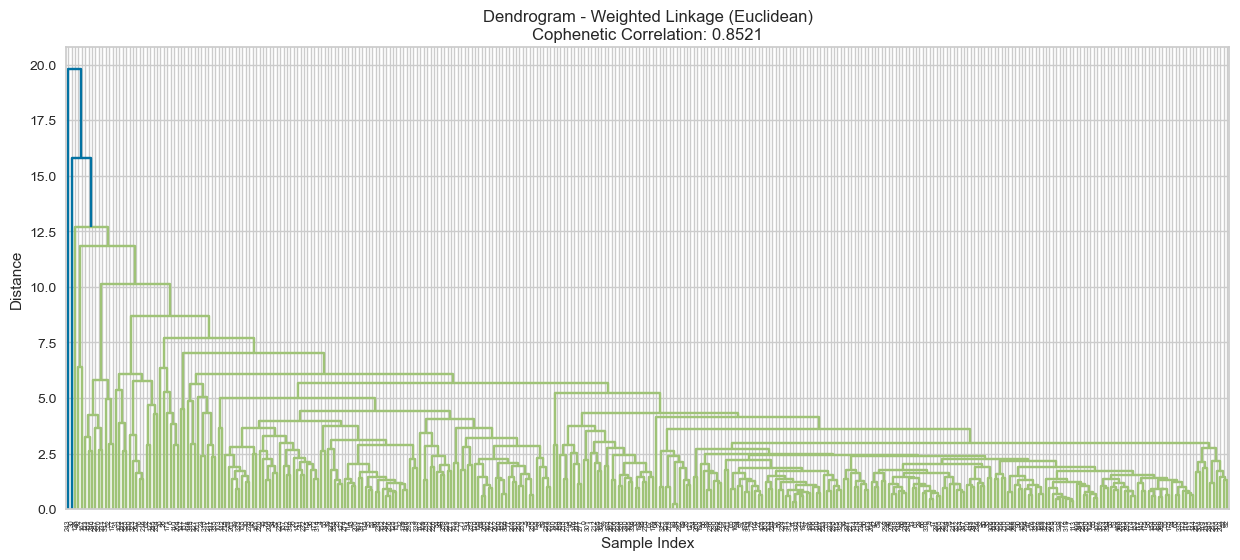

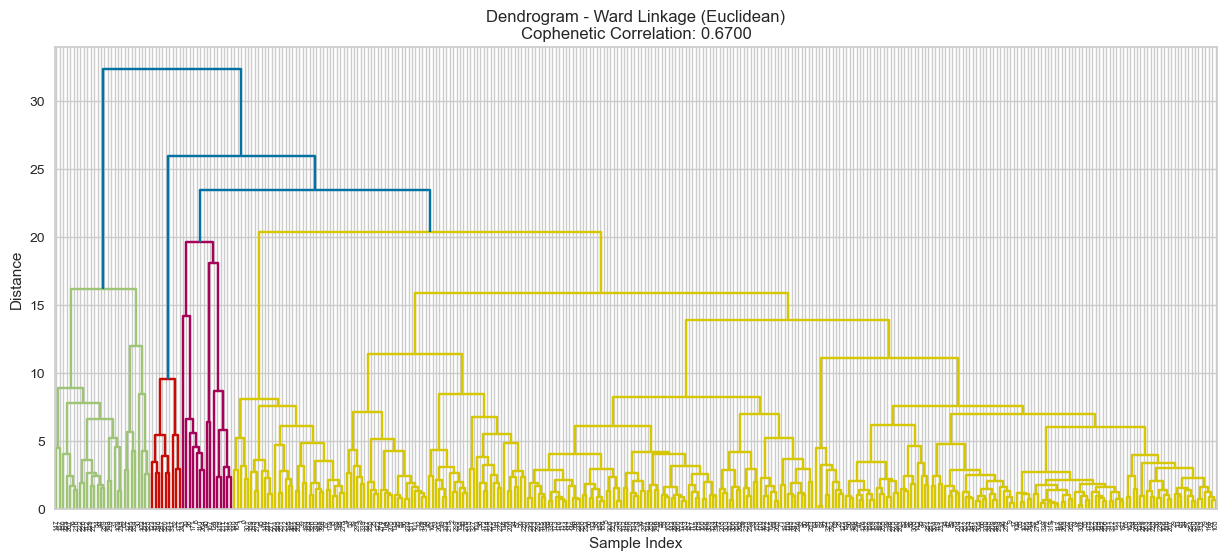

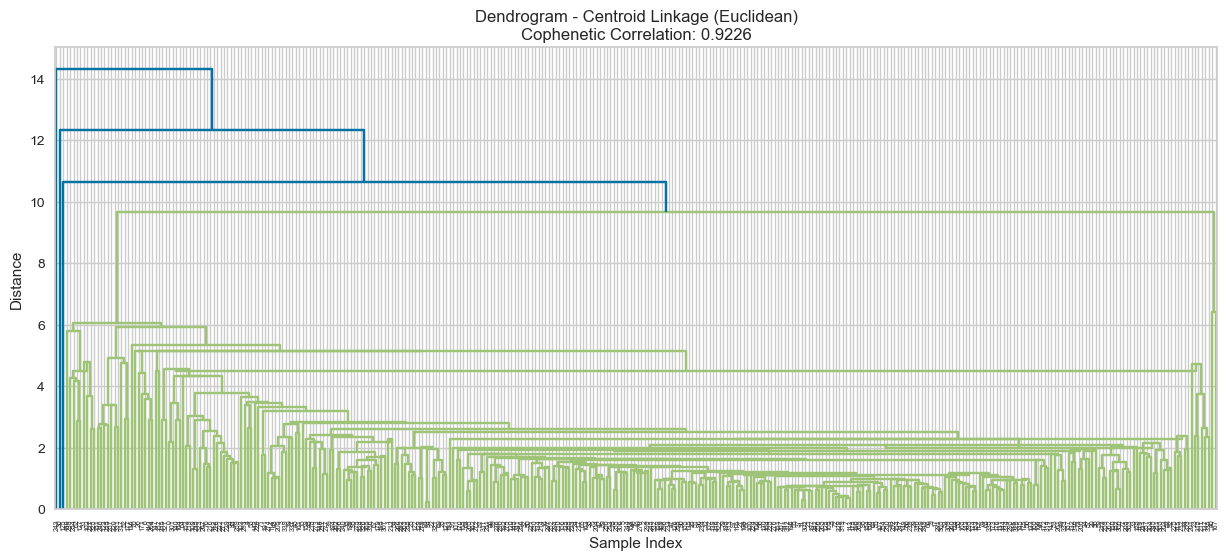

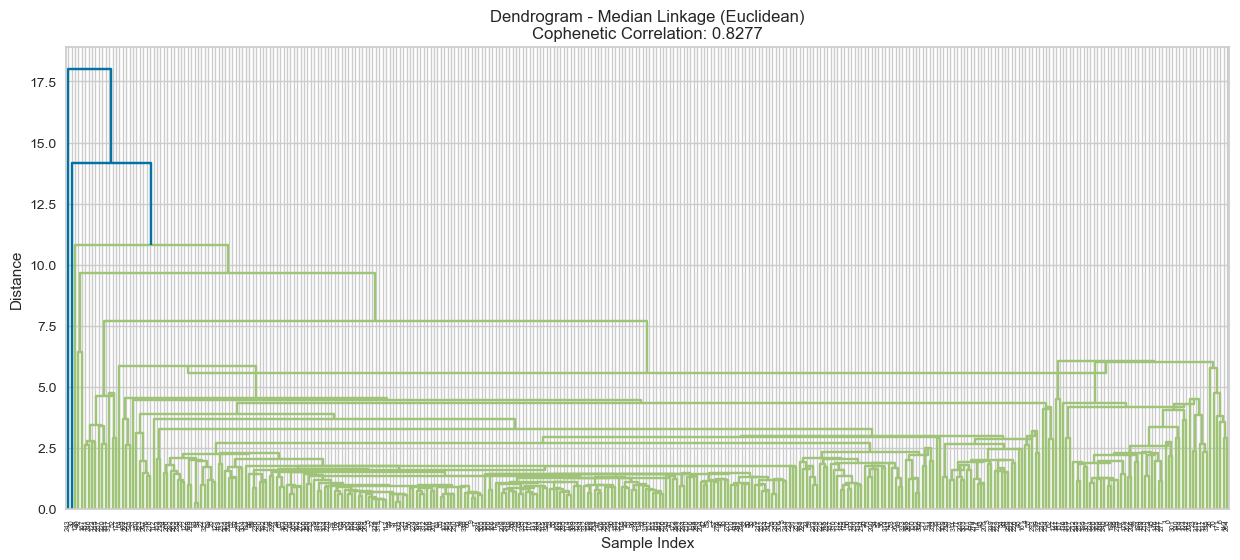

In [114]:
# Dendrograms for each linkage method (Euclidean distance) - Capped Data
euclidean_linkage_methods = ['single', 'complete', 'average', 'weighted', 'ward', 'centroid', 'median']

for method in euclidean_linkage_methods:
    Z = linkage(capped_subset_scaled_df, method=method, metric='euclidean')
    coph_corr, coph_dists = cophenet(Z, pdist(capped_subset_scaled_df, metric='euclidean'))

    plt.figure(figsize=(15, 6))
    dendrogram(Z)
    plt.title(f'Dendrogram - {method.capitalize()} Linkage (Euclidean)\nCophenetic Correlation: {coph_corr:.4f}')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.show()

In [115]:
# Manual Silhouette Score Loop - Hierarchical Clustering, Capped Data for euclidean distance, average linkage
print("Capped Data (Average Linkage) — Silhouette Scores by k:\n")

hc_scores_capped = []
k_range = range(2, 10)

for k in k_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='average', metric='euclidean')
    labels = hc.fit_predict(capped_subset_scaled_df)
    score = silhouette_score(capped_subset_scaled_df, labels)
    hc_scores_capped.append(score)
    print(f"k = {k}: silhouette score = {score:.4f}")

Capped Data (Average Linkage) — Silhouette Scores by k:

k = 2: silhouette score = 0.7261
k = 3: silhouette score = 0.6790
k = 4: silhouette score = 0.6317
k = 5: silhouette score = 0.6131
k = 6: silhouette score = 0.5022
k = 7: silhouette score = 0.4931
k = 8: silhouette score = 0.4506
k = 9: silhouette score = 0.4480


In [116]:
#Check cluster sizes for K=2 thru K=5 with euclidean distance, average linkage
for k in range(2, 6):
    hc = AgglomerativeClustering(n_clusters=k, linkage='average', metric='euclidean')
    labels = hc.fit_predict(capped_subset_scaled_df)
    print(f"k={k}:\n{pd.Series(labels).value_counts()}\n")

k=2:
0    339
1      1
Name: count, dtype: int64

k=3:
0    338
2      1
1      1
Name: count, dtype: int64

k=4:
0    337
2      1
3      1
1      1
Name: count, dtype: int64

k=5:
0    335
1      2
2      1
3      1
4      1
Name: count, dtype: int64



In [117]:
# Manual Silhouette Score Loop - Hierarchical Clustering, Capped Data for euclidean distance, ward linkage
for k in range(2, 10):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = hc.fit_predict(capped_subset_scaled_df)
    score = silhouette_score(capped_subset_scaled_df, labels)
    print(f"k = {k}: silhouette score = {score:.4f}")

k = 2: silhouette score = 0.4080
k = 3: silhouette score = 0.4209
k = 4: silhouette score = 0.4369
k = 5: silhouette score = 0.2699
k = 6: silhouette score = 0.2768
k = 7: silhouette score = 0.2838
k = 8: silhouette score = 0.2846
k = 9: silhouette score = 0.2017


In [118]:
#Check cluster sizes for K=4 with euclidean distance, ward linkage
for k in [4]:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    labels = hc.fit_predict(capped_subset_scaled_df)
    print(f"k={k}:\n{pd.Series(labels).value_counts()}\n")

k=4:
0    288
3     28
1     15
2      9
Name: count, dtype: int64



##### Capped Dendrogram Observations:
- The results for the capped dendrograms immediately appear to reflect those of the uncapped data
- Here appropriate number of clusters appeared to fall between 2 and 5
- Again euclidean, average with k=2 to k=5 produce groups of 1s and 2s which are not meaningful for our purposes
- Visually the clusters look much better in the euclidean, ward dendrogram
- For euclidean, ward k= 4 appears to be the right number of clusters in the dendrogram
- For euclidean, ward the silhouette score is also highest at k=4
- For euclidean, ward with k=4 cluster sizes are much better than with euclidean, average
- **We will select euclidean, ward with k=4 for our capped heirarchical model**

### Final Hierarchical Models

#### Uncapped Hierarchical Model

In [119]:
# Final hierarchical clustering model Uncapped
final_hc_model_uncapped = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",
    linkage="ward"
)

# Fit on scaled uncapped data
final_hc_model_uncapped.fit(uncapped_subset_scaled_df)

AgglomerativeClustering(n_clusters=4)

In [120]:
#Copy original data to build new df with cluster label column
df_uncapped_hc_clusters = df.copy()

#Add Hierarchical cluster labels to original data
df_uncapped_hc_clusters['HC_segments'] = final_hc_model_uncapped.labels_

# Check
df_uncapped_hc_clusters.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,HC_segments
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219,3
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068,3
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171,3
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651,3
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810,3


#### Uncapped Hierarchical Cluster Profiling

In [121]:
# Show cluster sizes
print("Cluster sizes:")
print(df_uncapped_hc_clusters['HC_segments'].value_counts().sort_index())
print()

Cluster sizes:
HC_segments
0     29
1     15
2     11
3    285
Name: count, dtype: int64



In [122]:
#Display cluster profile means
uncapped_cluster_profile_mean_hc = df_uncapped_hc_clusters.groupby('HC_segments')[num_col].mean()
print("Cluster profile (means):")
uncapped_cluster_profile_mean_hc

Cluster profile (means):


,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
HC_segments,,,,,,,,,,,
0,48.006208,-11.263107,2.590247,196.551724,40.275862,-4.959017e+08,-3.597245e+09,-8.689655,4.863198e+08,75.110924,-2.162622
1,326.198218,10.563242,1.642560,14.400000,309.466667,2.888507e+08,8.644985e+08,7.785333,5.449003e+08,113.095334,19.142151
2,42.848182,6.270446,1.123547,22.727273,71.454545,5.586364e+08,1.463127e+10,3.410000,4.242573e+09,15.242169,-4.924615
3,72.760400,5.213307,1.427078,25.603509,60.392982,7.995151e+07,1.538594e+09,3.655351,4.464721e+08,24.722670,-2.647194


In [123]:
# Display cluster profile medians
uncapped_cluster_profile_median_hc = df_uncapped_hc_clusters.groupby('HC_segments')[num_col].median()
uncapped_cluster_profile_median_hc

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
HC_segments,,,,,,,,,,,
0,32.930000,-9.898378,2.509437,43.0,27.0,-86000000.0,-1.967000e+09,-4.29,4.021417e+08,93.089287,0.525090
1,190.750000,13.925341,1.585944,14.0,237.0,160383000.0,5.467330e+08,3.71,2.117647e+08,31.362745,10.497704
2,42.959999,5.942118,1.151454,11.0,79.0,-911000000.0,1.588800e+10,3.85,4.194805e+09,13.004785,-1.466307
3,60.599998,4.917982,1.351595,15.0,44.0,3390000.0,7.644650e+08,3.03,2.917294e+08,19.227393,-1.269332


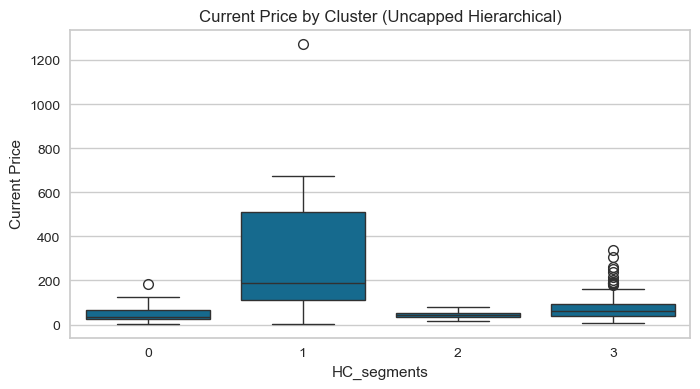

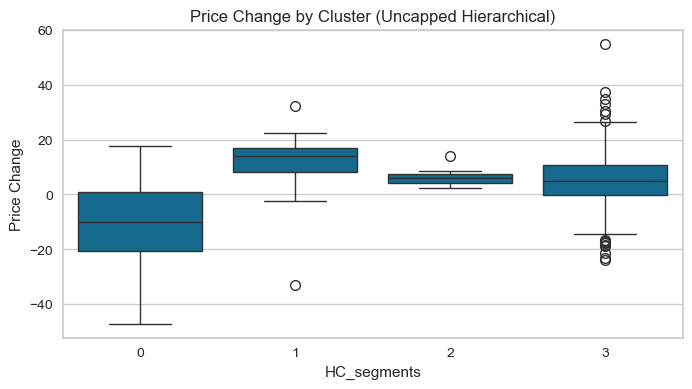

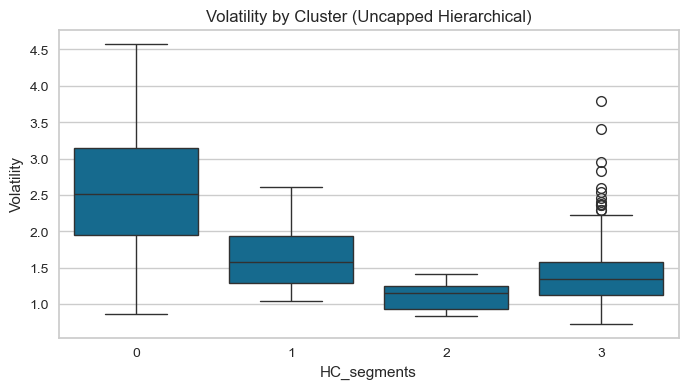

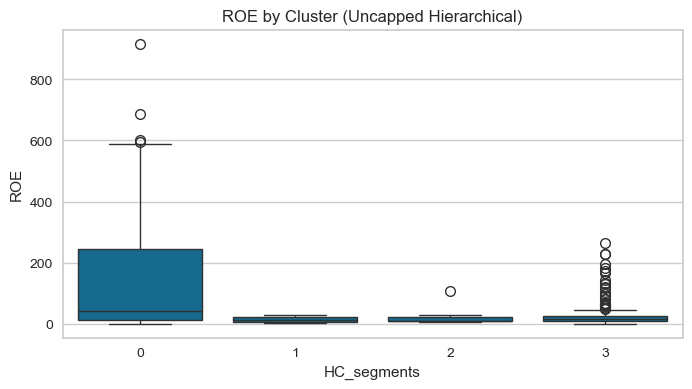

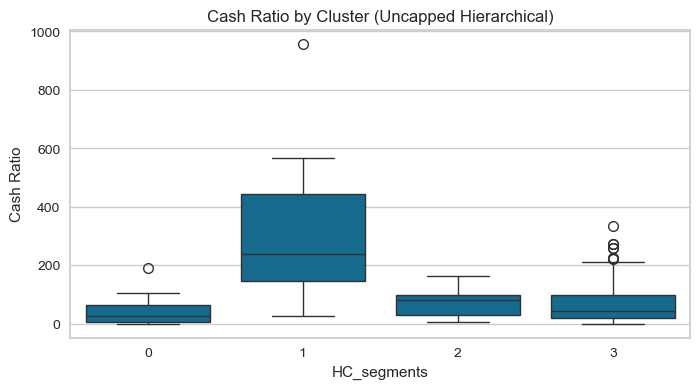

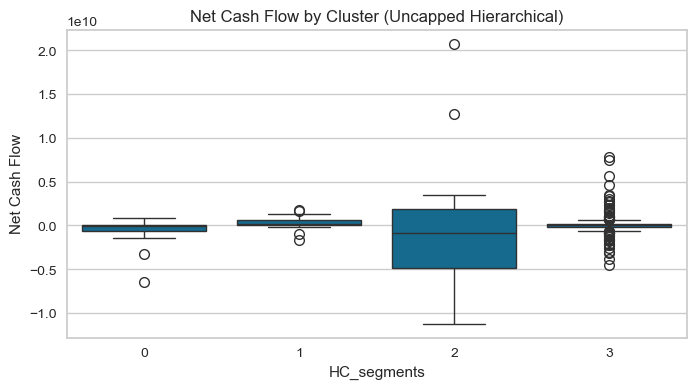

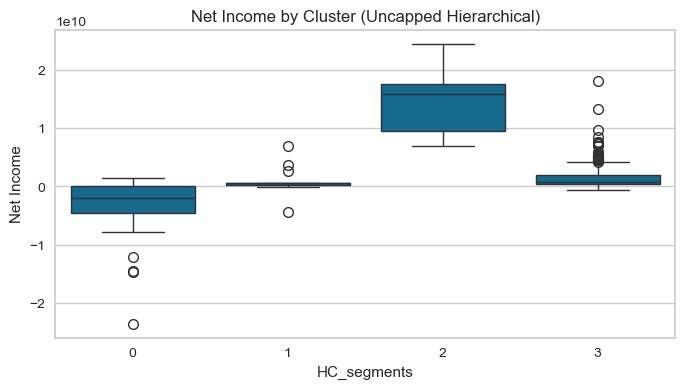

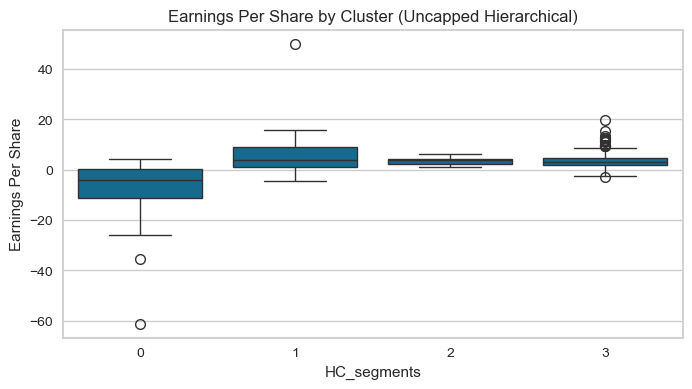

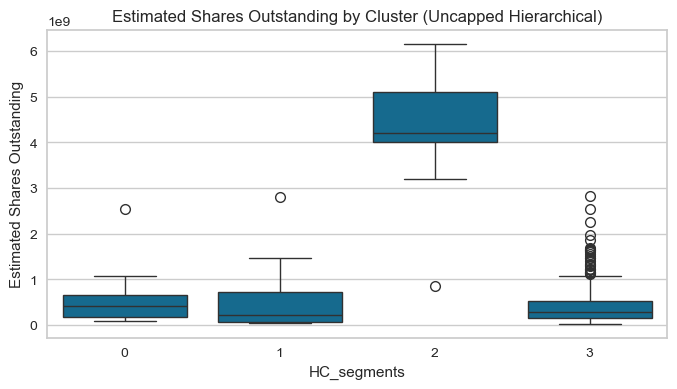

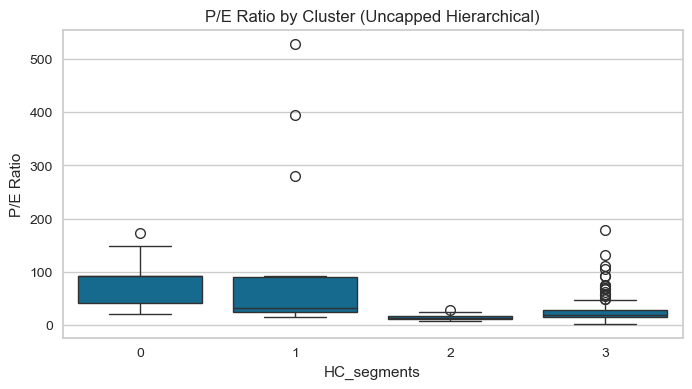

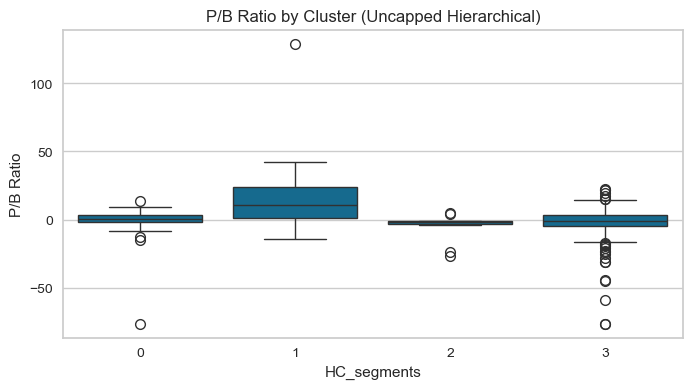

In [124]:
# Visual comparison of cluster features
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_uncapped_hc_clusters, x='HC_segments', y=col)
    plt.title(f'{col} by Cluster (Uncapped Hierarchical)')
    plt.show()

In [125]:
# Check  how clusters align with sectors
uncapped_sector_composition_hc = pd.crosstab(df_uncapped_hc_clusters['HC_segments'], df_uncapped_hc_clusters['GICS Sector'])
uncapped_sector_composition_hc

GICS Sector,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Telecommunications Services,Utilities
HC_segments,,,,,,,,,,,
0,1,2,22,1,0,1,1,1,0,0,0
1,3,1,0,0,5,0,4,0,1,1,0
2,1,1,1,4,1,0,1,0,0,2,0
3,35,15,7,44,34,52,27,19,26,2,24


In [126]:
# List companies in each cluster
for cluster in sorted(df_uncapped_hc_clusters['HC_segments'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df_uncapped_hc_clusters[df_uncapped_hc_clusters['HC_segments'] == cluster]['Security'].tolist())


--- Cluster 0 ---
['Allegion', 'Apache Corporation', 'Anadarko Petroleum Corp', 'Baker Hughes Inc', 'Chesapeake Energy', 'Charter Communications', 'Colgate-Palmolive', 'Cabot Oil & Gas', 'Concho Resources', 'Devon Energy Corp.', 'EOG Resources', 'Freeport-McMoran Cp & Gld', 'Hess Corporation', 'Kimberly-Clark', 'Kinder Morgan', 'Marathon Oil Corp.', 'Murphy Oil', 'Noble Energy Inc', 'Newfield Exploration Co', 'National Oilwell Varco Inc.', 'ONEOK', 'Occidental Petroleum', 'Range Resources Corp.', 'Spectra Energy Corp.', 'S&P Global, Inc.', 'Southwestern Energy', 'Teradata Corp.', 'Williams Cos.', 'Cimarex Energy']

--- Cluster 1 ---
['Alliance Data Systems', 'Alexion Pharmaceuticals', 'Amgen Inc', 'Amazon.com Inc', 'Chipotle Mexican Grill', 'Equinix', 'Facebook', 'Frontier Communications', 'Intuitive Surgical Inc.', 'Monster Beverage', 'Netflix Inc.', 'Priceline.com Inc', 'Regeneron', 'Waters Corporation', 'Yahoo Inc.']

--- Cluster 2 ---
['Bank of America Corp', 'Citigroup Inc.', 'Fo

##### Uncapped Hierarchical Cluster Profiling Observations:
- Cluster assignments derive from uncapped/scaled features; profiling uses original uncapped values for interpretability
- Clusters are largely uneven with the largest cluster having 285 securities and the smallest having 11
- Cluster interpretations appear to align fairly well with K-Means clusters.
- Clusters do not align cleanly with sectors, but some patterns do emerge:
    - Cluster 0 is 75.9% Energy sector
    - Cluster 1 is 33.3% Health Care sector
    - Cluster 2 is 35.4% Financials sector
    - Cluster 3 is 18.2% Industrials sector
- Cluster 0: Appears to represent a low-price, high-risk, speculative cluster of companies with deteriorating performance, price uncertainty, and cash depletion.
    - Second largest cluster consisting of 29 securities across 7 sectors with 22 in the Energy sector
    - Low priced
    - Mostly negative price change
    - Highest volatility
    - Highest ROE
    - Positive, but lower than average cash ratio
    - Negative net cash flow
    - Negative net income
    - Negative earnings per share
    - Above average P/E ratio
- Cluster 1: Appears to represent a premium priced, high-performing growth cluster made up of profitable, cash-rich companies with the strongest market momentum in the dataset.
    - Cluster size of 15 securities across 6 sectors with 5 in the Health Care sector
    - Highest price
    - Most positive price change
    - A little above average volatility
    - Highest cash ratio
    - Mostly positive net cash flow
    - Positive net income
    - Mostly positive, above average earnings per share
    - High P/E ratio
    - High P/B ratio
- Cluster 2: Appears to represent small cluster of very large, mature, companies that combine exceptional profitability, low market risk, strong recent price performance, and relatively inexpensive earnings valuations.  Negative book equity and weaker ROE suggest heavy leverage/buybacks.
    - Smallest cluster of 11 securities across 7 sectors with 4 in Financials
    - All big, household names
    - Low priced
    - Positive, above average price change
    - Low risk
    - Below average ROE
    - Positive cash ratio
    - Broad range of net cash flows, skews negative
    - Highest net income
    - Above average earnings per share
    - Most shares outstanding
    - Positive, but below average P/E ratio
    - Negative P/B ratio
- Cluster 3: Appears to represent a broad “core market” cluster representing typical established public companies: moderately priced, generally profitable, reasonably valued, and relatively stable, with no single extreme financial characteristic dominating (catch-all baseline rather than a sharply defined investment archetype).
    - Largest cluster of 285 securities across all 11 sectors with 52 in industrials
    - Moderate pricing
    - Broad range, price change – mostly moderate, slightly above average
    - Broad range volatility, mostly low to moderate
    - Moderate ROE
    - Low to moderate cash ratio
    - Broad range net cash flow
    - Positive, moderate net income
    - Moderate earnings per share
    - Positive, moderate P/E ratio
    - Broad range, skewing slightly negative P/B ratio

#### Capped Hierarchical Model

In [127]:
# Final hierarchical clustering model Capped
final_hc_model_capped = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",
    linkage="ward"
)

# Fit on scaled, capped data
final_hc_model_capped.fit(capped_subset_scaled_df)

AgglomerativeClustering(n_clusters=4)

In [128]:
#Copy original data to build new df with cluster label column
df_capped_hc_clusters = df.copy()

#Add Hierarchical cluster labels to original data
df_capped_hc_clusters['HC_segments'] = final_hc_model_capped.labels_

# Check
df_capped_hc_clusters.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,HC_segments
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219,0
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068,0
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171,0
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651,0
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810,0


#### Capped Hierarchical Cluster Profiling

In [129]:
# Show cluster sizes
print("Cluster sizes:")
print(df_capped_hc_clusters['HC_segments'].value_counts().sort_index())
print()

Cluster sizes:
HC_segments
0    288
1     15
2      9
3     28
Name: count, dtype: int64



In [130]:
#Display cluster profile means
capped_cluster_profile_mean_hc = df_capped_hc_clusters.groupby('HC_segments')[num_col].mean()
print("Cluster profile (means):")
capped_cluster_profile_mean_hc

Cluster profile (means):


,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
HC_segments,,,,,,,,,,,
0,74.193104,5.576434,1.412630,35.128472,59.392361,1.953326e+07,1.528486e+09,3.641059,4.433643e+08,25.310702,-3.068567
1,309.274885,9.829361,1.510283,15.533333,309.533333,2.472136e+09,2.667256e+09,8.160000,8.748332e+08,69.920061,20.668053
2,46.672222,5.166566,1.079367,25.000000,58.333333,-3.040667e+09,1.484844e+10,3.435556,4.564960e+09,15.596051,-6.354193
3,38.086072,-14.763095,2.843788,103.142857,54.821429,1.264705e+08,-3.777078e+09,-9.210000,5.104852e+08,93.200861,1.668192


In [131]:
# Display cluster profile medians
capped_cluster_profile_median_hc = df_capped_hc_clusters.groupby('HC_segments')[num_col].median()
capped_cluster_profile_median_hc

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
HC_segments,,,,,,,,,,,
0,62.055000,5.244761,1.347768,15.0,43.5,2.204000e+06,7.667305e+08,3.03,2.891587e+08,19.350070,-1.282088
1,162.330002,13.925341,1.418688,15.0,237.0,2.540000e+08,5.960000e+08,4.18,4.656250e+08,28.976191,10.497704
2,46.220001,5.532912,1.130337,11.0,74.0,-1.649000e+09,1.615000e+10,3.85,4.194805e+09,13.004785,-1.886881
3,32.280000,-13.481056,2.649248,24.5,42.0,-1.472000e+07,-2.085500e+09,-4.39,4.066679e+08,93.089287,1.344887


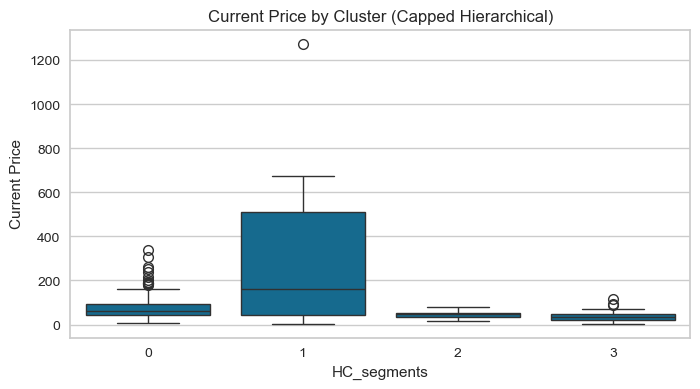

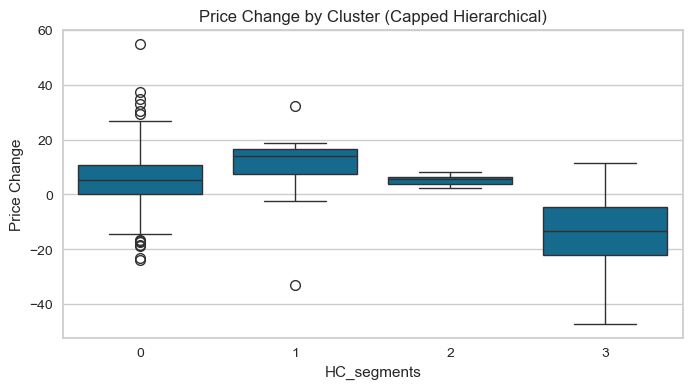

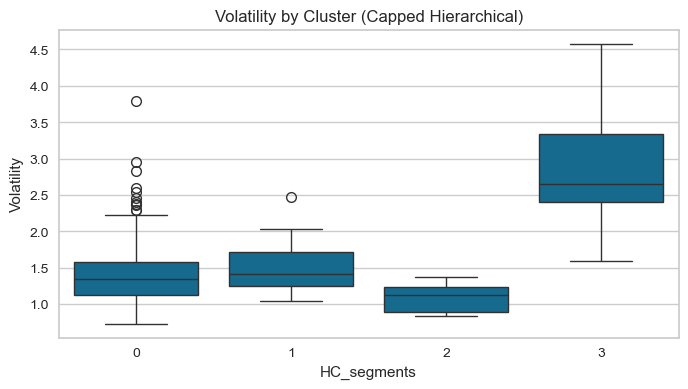

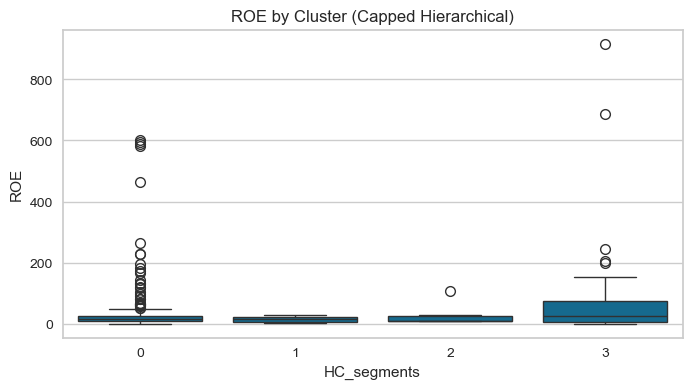

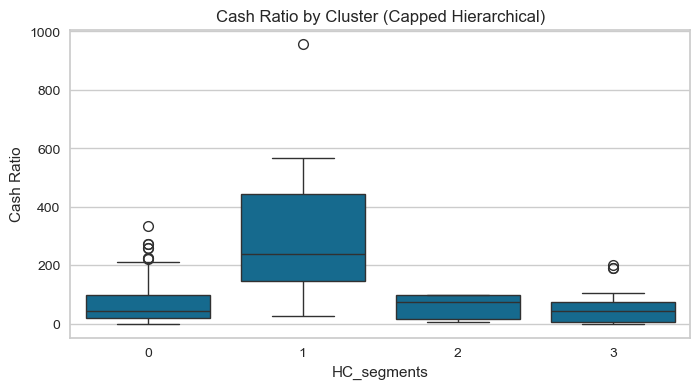

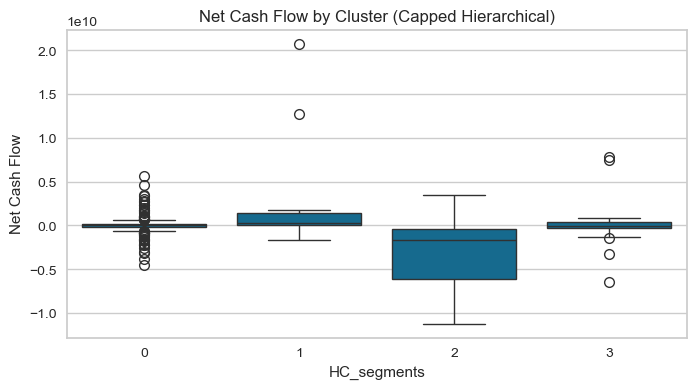

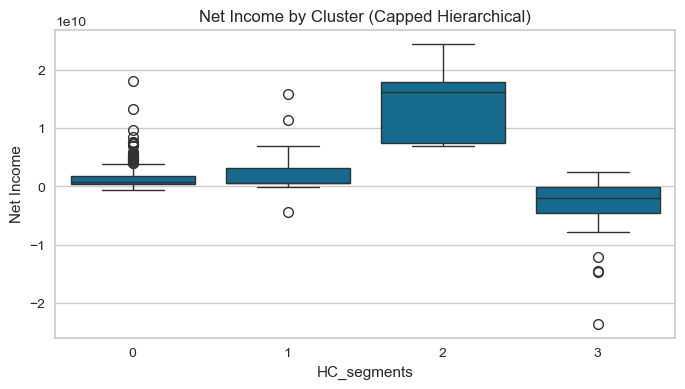

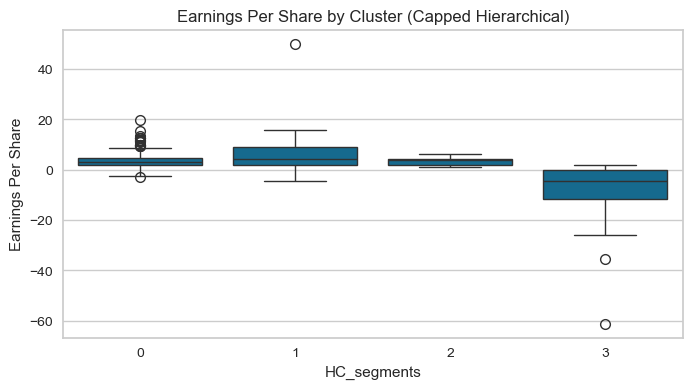

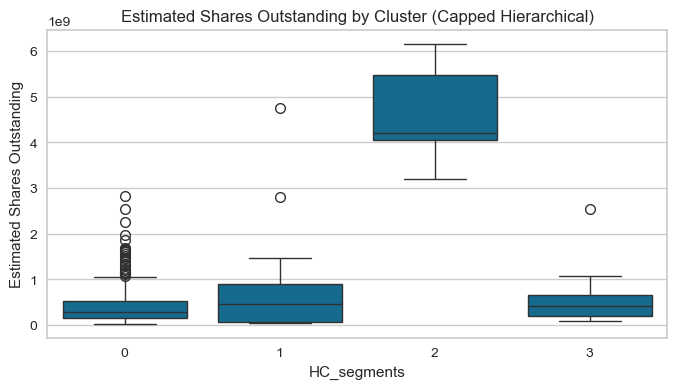

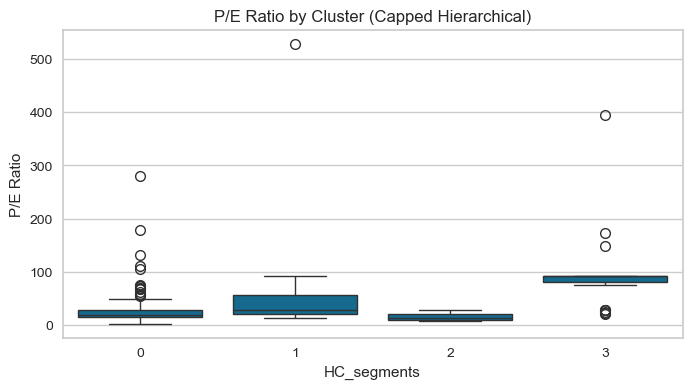

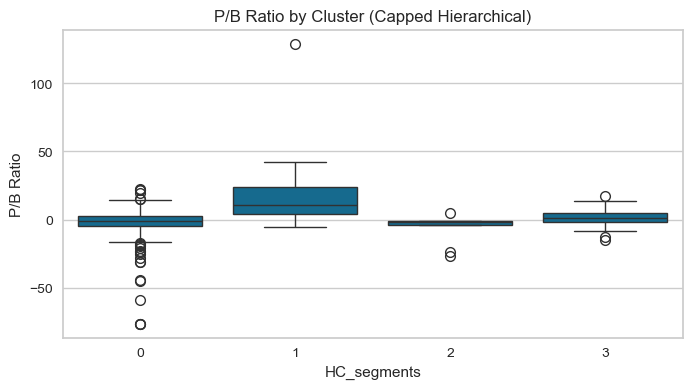

In [132]:
# Visual comparison of cluster features
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_capped_hc_clusters, x='HC_segments', y=col)
    plt.title(f'{col} by Cluster (Capped Hierarchical)')
    plt.show()

In [133]:
# Check  how clusters align with sectors
capped_sector_composition_hc = pd.crosstab(df_capped_hc_clusters['HC_segments'], df_capped_hc_clusters['GICS Sector'])
capped_sector_composition_hc

GICS Sector,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Telecommunications Services,Utilities
HC_segments,,,,,,,,,,,
0,36,17,5,45,35,53,26,19,26,2,24
1,3,1,0,1,4,0,4,0,1,1,0
2,1,1,1,3,1,0,0,0,0,2,0
3,0,0,24,0,0,0,3,1,0,0,0


In [134]:
# List companies in each cluster
for cluster in sorted(df_capped_hc_clusters['HC_segments'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df_capped_hc_clusters[df_capped_hc_clusters['HC_segments'] == cluster]['Security'].tolist())


--- Cluster 0 ---
['American Airlines Group', 'AbbVie', 'Abbott Laboratories', 'Adobe Systems Inc', 'Analog Devices, Inc.', 'Archer-Daniels-Midland Co', 'Ameren Corp', 'American Electric Power', 'AFLAC Inc', 'American International Group, Inc.', 'Apartment Investment & Mgmt', 'Assurant Inc', 'Arthur J. Gallagher & Co.', 'Akamai Technologies Inc', 'Albemarle Corp', 'Alaska Air Group Inc', 'Allstate Corp', 'Allegion', 'Alexion Pharmaceuticals', 'Applied Materials Inc', 'AMETEK Inc', 'Affiliated Managers Group Inc', 'Ameriprise Financial', 'American Tower Corp A', 'AutoNation Inc', 'Anthem Inc.', 'Aon plc', 'Amphenol Corp', 'Arconic Inc', 'Activision Blizzard', 'AvalonBay Communities, Inc.', 'Broadcom', 'American Water Works Company Inc', 'American Express Co', 'Boeing Company', 'Baxter International Inc.', 'BB&T Corporation', 'Bard (C.R.) Inc.', 'BIOGEN IDEC Inc.', 'The Bank of New York Mellon Corp.', 'Ball Corp', 'Bristol-Myers Squibb', 'Boston Scientific', 'BorgWarner', 'Boston Proper

##### Capped Hierarchical Cluster Profiling Observations:
- Cluster assignments derive from capped/scaled features; profiling uses original uncapped values for interpretability
- Clusters are largely uneven with the largest cluster having 288 securities and the smallest having 9
- Clusters do not align cleanly with sectors, but some patterns do emerge:
    - Cluster 0 is 18.4% Industrials sector
    - Cluster 1 is 26.7% Healthcare and 26.7% Information Technology sectors
    - Cluster 2 is 33.3% Financials sector
    - Cluster 3 is 85.7% Energy sector
- Cluster 0: Appears to represent a broad “core market” cluster of generally established, reasonably healthy companies with moderate profitability, valuation, and risk characteristics with substantial internal variation and no single extreme trait dominating (central population).
    - Largest cluster of 288 securities across all 11 sectors with 53 in industrials 
    - Moderately priced
    - Broad range, mostly moderate to slightly above average price change
    - Broad range, mostly moderate volatility
    - Broad range, mostly middle of the road ROE
    - Moderate to slightly below average cash ratio
    - Wide range of cash flow
    - Moderate, mostly positive net income
    - Moderate to slightly above average earnings per share
    - Moderate, positive P/E ratio
    - Wide range, skews negative P/B ratio
- Cluster 1: Appears to represent a small premium-growth cluster of cash-rich, highly profitable-per-share companies with the strongest price momentum and cash generation.
    - Second Smallest cluster of 15 securities across 7 sectors with 4 in healthcare and 4 in Information Technology
    - Broad range, highest priced
    - Most positive price change
    - Moderate volatility
    - Moderate to lower than average ROE
    - Broad, positive, highest cash ratio
    - Highest net cash flow
    - Positive, moderate net income
    - Highest earnings per share
    - Above average P/E ratio
    - Above average P/B ratio
- Cluster 2: Appears to represent small cluster of very large, mature, companies that combine exceptional profitability, low market risk, strong recent price performance, and relatively inexpensive earnings valuations.
    - Smallest cluster of 9 securities across 6 sectors with 3 in Financials.
    - All big, well known names
    - Lower priced
    - Moderate to slightly above average price change
    - Lowest volatility
    - Moderate to below average ROE
    - Moderate cash ratio
    - Negative net cash flow
    - Most positive net income
    - Above average earnings per share
    - Most shares outstanding
    - Positive, below average P/E ratio
    - Negative P/B ratio
- Cluster 3: Appears to represent distressed, Energy-dominated cluster of low-priced securities with severe recent declines, high volatility, and ongoing losses (high ROE and P/E are likely ratio/aggregation artifacts rather than signs of financial strength).
    - Second largest cluster with 28 securities across 3 sectors with 24 in Energy
    - Lowest priced
    - Very negative price change
    - Most volatile
    - Highest ROE
    - Moderate to below average cash ratio
    - Broad range net cash flow
    - Negative net income
    - Negative earnings per share
    - Highest P/E ratio
    - Above average P/B ratio

### Hierarchical Clustering Observations
- As was the case with k-means, capping outliers did not have much impact on Hierarchical clusters
- Cluster sizes and interpretations between capped and uncapped came out comparable
    - Uncapped Cluster 0 -> Capped Cluster 3 (Low Price, high risk, distressed)
    - Uncapped Cluster 1 -> Capped Cluster 1 (Premium price, high performing)
    - Uncapped Cluster 2 -> Capped Cluster 2 (Large, mature)
    - Uncapped Cluster 3 -> Capped Cluster 0 (Core Market, steady gains)

## K-means vs Hierarchical Clustering

In [135]:
def analyze_cluster_overlap(group_name, cluster_specs):
    """
    cluster_specs: list of (label, dataframe, cluster_column, cluster_value) tuples
    Returns and prints the overlap distribution of company names across all specified clusters.
    """
    sets_dict = {}
    for label, df_source, col, val in cluster_specs:
        sets_dict[label] = set(df_source[df_source[col] == val]['Security'])

    n_models = len(sets_dict)
    company_counts = Counter()
    for s in sets_dict.values():
        company_counts.update(s)

    overlap_distribution = Counter(company_counts.values())

    print(f"=== {group_name} ({n_models} models compared) ===")
    for n in range(n_models, 0, -1):
        print(f"  In {n}/{n_models} models: {overlap_distribution.get(n, 0)} companies")

    in_all = [c for c, cnt in company_counts.items() if cnt == n_models]
    print(f"  Companies in ALL {n_models}: {sorted(in_all)}")
    print()

    return sets_dict, company_counts

In [136]:
# Define cluster groupings
groups = {
    "Core Market, steady gains": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 0),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 4),
        ("HC Uncapped", df_uncapped_hc_clusters, 'HC_segments', 3),
        ("HC Capped", df_capped_hc_clusters, 'HC_segments', 0),
    ],
    "Large, established, reliable": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 3),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 3),
        ("HC Uncapped", df_uncapped_hc_clusters, 'HC_segments', 2),
        ("HC Capped", df_capped_hc_clusters, 'HC_segments', 2),
    ],
    "Premium priced, high performing": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 4),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 0),
        ("HC Uncapped", df_uncapped_hc_clusters, 'HC_segments', 1),
        ("HC Capped", df_capped_hc_clusters, 'HC_segments', 1),
    ],
    "Distressed, volatile": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 1),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 2),
        ("HC Uncapped", df_uncapped_hc_clusters, 'HC_segments', 0),
        ("HC Capped", df_capped_hc_clusters, 'HC_segments', 3),
    ],
    "Highly distressed, volatile": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 2),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 1),
    ],
}

In [137]:
all_results = {}
for group_name, specs in groups.items():
    all_results[group_name] = analyze_cluster_overlap(group_name, specs)

=== Core Market, steady gains (4 models compared) ===
  In 4/4 models: 260 companies
  In 3/4 models: 15 companies
  In 2/4 models: 12 companies
  In 1/4 models: 4 companies
  Companies in ALL 4: ['3M Company', 'AFLAC Inc', 'AMETEK Inc', 'AbbVie', 'Abbott Laboratories', 'Activision Blizzard', 'Affiliated Managers Group Inc', 'Akamai Technologies Inc', 'Alaska Air Group Inc', 'Albemarle Corp', 'Alliant Energy Corp', 'Allstate Corp', 'Altria Group Inc', 'Ameren Corp', 'American Airlines Group', 'American Electric Power', 'American Express Co', 'American International Group, Inc.', 'American Tower Corp A', 'American Water Works Company Inc', 'Ameriprise Financial', 'Amphenol Corp', 'Anthem Inc.', 'Aon plc', 'Apartment Investment & Mgmt', 'Applied Materials Inc', 'Archer-Daniels-Midland Co', 'Arconic Inc', 'Arthur J. Gallagher & Co.', 'Assurant Inc', 'AutoNation Inc', 'AvalonBay Communities, Inc.', 'BB&T Corporation', 'Ball Corp', 'Bard (C.R.) Inc.', 'Baxter International Inc.', 'Boeing Co

In [138]:
def build_comparison_df(group_name, cluster_specs, metrics=['Price Change', 'Volatility']):
    """
    cluster_specs: list of (label, dataframe, cluster_column, cluster_value) tuples
    Returns a long-format dataframe: Group, Model, Security, <metric columns>
    """
    frames = []
    for label, df_source, col, val in cluster_specs:
        subset = df_source[df_source[col] == val][['Security'] + metrics].copy()
        subset['Model'] = label
        subset['Group'] = group_name
        frames.append(subset)
    return pd.concat(frames, ignore_index=True)

In [139]:
# Build for "good stock" groupings
good_groups = {
    "Core Market, steady gains": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 0),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 4),
        ("HC Uncapped", df_uncapped_hc_clusters, 'HC_segments', 3),
        ("HC Capped", df_capped_hc_clusters, 'HC_segments', 0),
    ],
    "Large, established, reliable": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 3),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 3),
        ("HC Uncapped", df_uncapped_hc_clusters, 'HC_segments', 2),
        ("HC Capped", df_capped_hc_clusters, 'HC_segments', 2),
    ],
    "Premium priced, high performing": [
        ("KM Uncapped", df_uncapped_k_clusters, 'KM_segments', 4),
        ("KM Capped", df_capped_k_clusters, 'KM_segments', 0),
        ("HC Uncapped", df_uncapped_hc_clusters, 'HC_segments', 1),
        ("HC Capped", df_capped_hc_clusters, 'HC_segments', 1),
    ],
}

In [140]:
comparison_dfs = {name: build_comparison_df(name, specs) for name, specs in good_groups.items()}

In [141]:
#Display Price change and volatility across similar clusters from different models
for group_name, comp_df in comparison_dfs.items():
    print(f"=== {group_name} ===")
    summary = comp_df.groupby('Model')[['Price Change', 'Volatility']].agg(['mean', 'median'])
    
    styled = (summary.style
              .highlight_max(subset=[('Price Change', 'mean'), ('Price Change', 'median')], color='lightgreen')
              .highlight_min(subset=[('Volatility', 'mean'), ('Volatility', 'median')], color='lightgreen'))
    display(styled)
    print()

=== Core Market, steady gains ===



=== Large, established, reliable ===



=== Premium priced, high performing ===


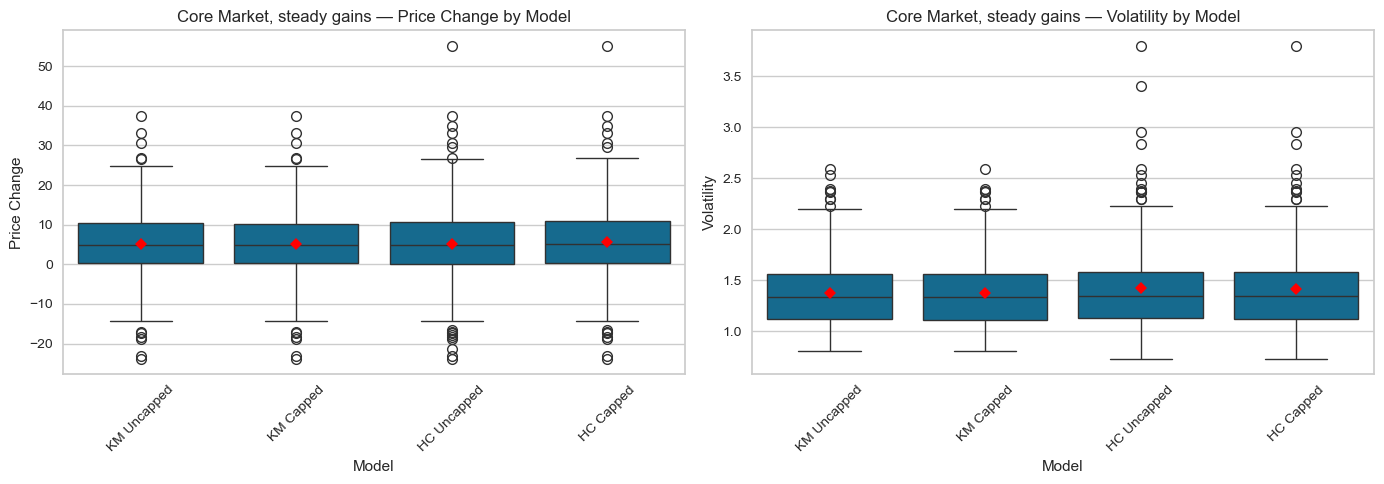

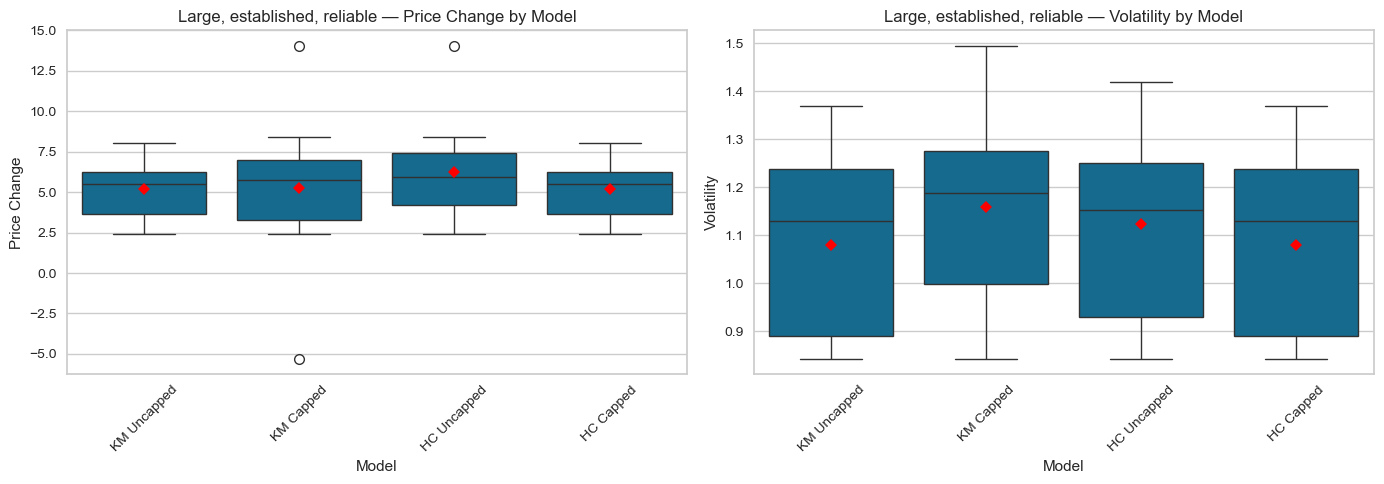

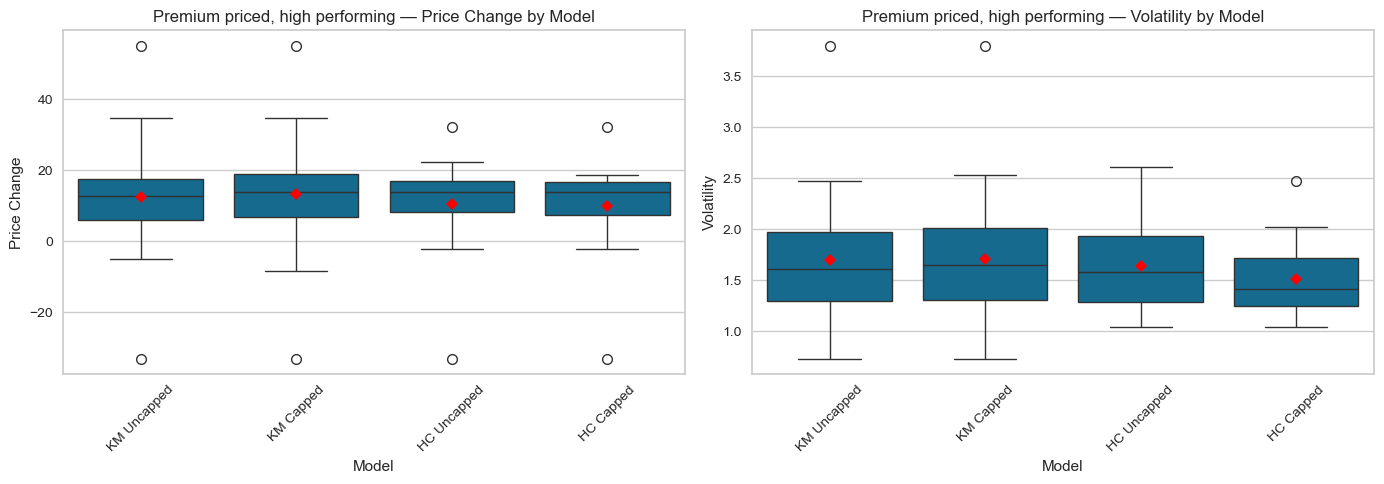

In [142]:
#Visual Comparison of good stock cluster performance
for group_name, comp_df in comparison_dfs.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=comp_df, x='Model', y='Price Change', ax=axes[0], showmeans=True,
                meanprops={'marker':'D', 'markerfacecolor':'red', 'markeredgecolor':'black'})
    axes[0].set_title(f'{group_name} — Price Change by Model')
    axes[0].tick_params(axis='x', rotation=45)

    sns.boxplot(data=comp_df, x='Model', y='Volatility', ax=axes[1], showmeans=True,
                meanprops={'marker':'D', 'markerfacecolor':'red', 'markeredgecolor':'black'})
    axes[1].set_title(f'{group_name} — Volatility by Model')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

### K-means vs Hierarchical Clustering Observations:
- The primary difference observed between k-means and Hierarchical clustering is that with k-means we built 5 clusters versus only 4 with Hierarchical.  Clusters of all 4 models (Uncapped k-means, Capped k-means, Uncapped Hierarchical, Capped Hierarchical) map onto eachother remarkably well with the k-means models having one extra cluster of highly distressed outliers (resulting in 2 distressed clusters as opposed to the single distressed cluster that emerged in the Hierarchical models.
- Mapping/Comparison of clusters from different models:
    - Core Market, steady gains: 
        - k-means uncapped cluster 0 (18.9% Industrials sector)
        - k-means capped cluster 4 (19.6% Industrials sector)
        - hierarchical uncapped cluster 3 (18.2% Industrials sector)
        - hierarchical capped cluster 0 (18.4% Industrials sector)
        - Most similar across models with 260 companies showing up in all 4 models, 15 in 3 of 4 models, 12 in 2 of 4 models, and only 4 showing up in only a single model.
    - Large, established, reliable: 
        - k-means uncapped cluster 3 (33.3% Financial sector)
        - k-means capped cluster 3 (28.6% Financial sector)
        - hierarchical uncapped cluster 2 (35.4% Financial sector)
        - hierarchical capped cluster 2 (33.3% Financial sector)
        - Very similar across models with 9 companies showing up in all 4 models, 2 in 2 of 4 models, and only 3 showing up in only a single model.
    - Premium priced, high performing
        - k-means uncapped cluster 4 (37.5% Healthcare sector)
        - k-means capped cluster 0 (33.3% Healthcare sector)
        - hierarchical uncapped cluster 1 (33.3% Healthcare sector)
        - hierarchical capped cluster 1 (26.7% Healthcare sector, 26.7% Information Technology sector)
        - More variable across models with 12 companies showing up in all 4 models, 1 in 3 of 4 models, 11 in 2 of 4 models, and 1 showing up in only a single model.
    - Distressed, volatile
        - k-means uncapped cluster 1 (70% Energy sector)
        - k-means capped cluster 2 (76% Energy sector)
        - hierarchical uncapped cluster 0 (75.9% Energy sector)
        - hierarchical capped cluster 3 (85.7% Energy sector)
        - Somewhat variable across models with 18 companies showing up in all 4 models, 7 in 3 of 4 models, 5 in 2 of 4 models, and 9 showing up in only a single model.
    - Highly distressed, volatile
        - k-means uncapped cluster 2 (100% Energy sector)
        - k-means capped cluster 1 (83.3% Energy sector)
        - 2 companies appear in both models, 4 appear in only one model.
- Since models are so similar and our goal is to identify clusters for picking good stocks, we compared each model's mean and median price gain and volatility.  We focused only on the 3 groups that show general price gains to identify the most useful model for picking stocks in those groups.  Model performance is close enough that there was no clear winner across groups.  However, the following recommendations can be made:
    - **We suggest implementing the k-means capped model**.  This model has the highest mean and median price increase in the highest performing cluster (premium priced, high performing stocks). While it also has the highest volatility it is still within an acceptable range and this class of stocks is where one would expect a little more volatility (medium risk, high reward).  On the other hand this model has the lowest volatility of all models for the Core Market class of stocks while maintaining above average (for the dataset) price increase.  This again is what one would expect from a low risk, moderate reward stock cluster.  Finally, as a k-means model this model is computationally less expensive than either of the very comparable Hierarchical models.

## Actionable Insights and Recommendations

### General Insights
- Mean Price change over the observed 13 week period was 4.08%
  - First Solar Inc had the greatest positive price change at 55.05%
  - Kinder Morgan had the most negative price change at -47.13%
  - The Healthcare sector had the most positive price change (mean: 9.59%, median: 10.32%)
  - Energy had the most negative price change (mean: -9.24%, median: -10.23%)
  - Of the 8 largest Sub Industries in the set, Healthcare Equpment had the most positive price change, while Oil & Gas Exploration & Production had the most negative change.
- Volatility
  - Southwestern Energy was the most volatile security while McDonald's Corp. was least volatile.
  - Energy stands out as the most volatile sector during the measured period; while Utilities and Consumer Staples compete for least volatile.
  - Of the 8 largest Sub Industries in the set, Oil & Gas Exploration & Production was most volatile and Electric Utilities was the least volatile.
- The Industrials sector has the greatest number of securities represented in this dataset with 53 while the Telecommunications Services sector has the fewest with 5.

### Recommendations
- Implement k-means capped model
    - All models perform fairly similarly, but this one gives the most desirable clusters at least computational cost
- Target individual stocks from within the below clusters (and within the overlap of below sectors and clusters)
- Target ETFs that capture the below sectors.
- Avoid the Energy sector unless client is highly educated on the sector and has a very high risk tolerance.
- In general, target companies that fall into the following clusters
    - Cluster 4 - Core market, steady gain, low to  moderate volatility
    - Cluster 3 - Large, established, reliable companies with above average gains and below average volatility
    - Cluster 0 - Premium priced stocks - higher cost, high price gains, moderate to high volatility
- Portfolio distribution recommendations:
    - The core of most portfolios should be picked from clusters 3 and 4 with the best balance of gains and volatility.
    - Conservative portfolios that may need to access liquidity in the short term should should rely heavily on clusters 3 and 4 (in that order of preference) to take advantage of low volatility and steady gains.
    - More aggressive investors with a longer investment timeline, access to capital, and higher risk tolerance should consider shifting a higher percentage of their portfolio toward cluster 0 to take advantage of higher price gain potential (understanding the increased risk and timelines required with more volatile stocks).
- To narrow searches within these clusters (or for ETF picking) the following sector level information should be considered:
    - Consumer staples stand out with high overall gains and very low volatility
    - Healthcare has a the highest sector level gains with moderate volatility
    - The Financials sector shows a trend of moderate gains with low volatility
    - The Utilities sector tends to bring in only moderate to low gains but has very low volatility

In [143]:
!jupyter nbconvert --to html USL_Project_LearnerNotebook_FullCode.ipynb

[NbConvertApp] Converting notebook USL_Project_LearnerNotebook_FullCode.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 108 image(s).
[NbConvertApp] Writing 7180164 bytes to USL_Project_LearnerNotebook_FullCode.html
